# Paper 1 - eating behavior

### Define the relevant directories used in this paper - RUN EVERY TIME

Data is pulled from the standardized data folder; subsequently, it is stored and managed in the paper 1 folder. 

In [1]:
import os

# Define the source and output directories
source_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard"
paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"

# Ensure the output directory exists
os.makedirs(paper1_directory, exist_ok=True)

# 1. Data preparation

### Create a research question-specific SQL database subset

#### description

This code builds three SQLite subsets —“any”, “3plus” and “all” eating behaviors available of the contained patients —of the master `pnk_db2_filtered.sqlite`, keeping only GDPR-consented patients’ first medical record with varying completeness of emotional‐eating fields. For research purposes, the last one is most likely to be used. The first two may be relevant if trying to increase the sample size for one or a few specific emotional values. 

* Configuration  
   - Define `source_directory` and locate the filtered DB:  
     ```python
     db_path = os.path.join(source_directory, "pnk_db2_filtered.sqlite")
     conn = sqlite3.connect(db_path)
     ```  
   - Fetch all table names to iterate over later.

* Define Filtering Scenarios  
   - Function `create_filtered_database(criteria, output_filename)` takes:  
     • `criteria` ∈ {“any”, “3plus”, “all”}  
     • `output_filename` (e.g. `emotional_all_notna.sqlite`)  
   - Inside, choose one of three SQL queries on `medical_records_filtered` to select only first records (`medical_record_sequence=1`) of GDPR-consented patients (`gdpr4=1`):  
     - **any**: at least one emotional column ≠ NULL  
     - **3plus**: sum of non‐NULL flags across six emotional fields ≥ 3  
     - **all**: all six emotional fields ≠ NULL  
   - Read the resulting `(medical_record_id, patient_id)` pairs into Pandas.

* Build Scenario‐Specific Database  
   - Open a new SQLite file in `paper1_directory`.  
   - For each source table:  
     - **System tables** (`sqlite_…`) are skipped.  
     - **Multi‐record tables** (`medical_records_filtered`, `measurements_filtered`, `prescriptions_filtered`) are filtered by `medical_record_id IN (…)`.  
     - **Other tables** (e.g. `patients`, `alleles`) are filtered by `patient_id IN (…)`—only if they include a `patient_id` column.  
   - Query each subset into a DataFrame and write it to the new DB (replacing any existing table).

* Execution & Summary  
   - Call `create_filtered_database` for each scenario:  
     ```python
     any_count, any_patients       = create_filtered_database("any",    "emotional_any_notna.sqlite")
     three_plus_count, three_plus_patients = create_filtered_database("3plus","emotional_3plus_notna.sqlite")
     all_count, all_patients       = create_filtered_database("all",   "emotional_all_notna.sqlite")
     ```  
   - Close the source connection and print a summary:  
     ```
     Any  emotional data in X records from Y patients  
     3+   emotional data in A records from B patients  
     All  emotional data in C records from D patients
     ```  

#### code

In [ ]:
import sqlite3
import pandas as pd
import os

# Use the above defined directories
db_path = os.path.join(source_directory, "pnk_db2_filtered.sqlite")
conn = sqlite3.connect(db_path)

# List all tables in the database
query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query_tables, conn)
table_names = tables['name'].tolist()

# Define criteria for filtering for any/3+/all emotional values available, GDPR4 consent is available, and the medical record is the first one for the patient
def create_filtered_database(criteria, output_filename):
    # Set up the appropriate query based on the criteria for the three scenarios: 
    # any/3+/all emotional variables available. 
    # In all cases, only GDPR4-consented patients are selected, and only the first medical record of each patient is used.
    if criteria == "any":
        # to select records where at least one emotional variable is not null
        query = """
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        WHERE (
              hunger_yn IS NOT NULL
           OR satiety_yn IS NOT NULL
           OR emotional_eating_yn IS NOT NULL
           OR emotional_eating_value_likert IS NOT NULL
           OR quantity_control_likert IS NOT NULL
           OR impulse_control_likert IS NOT NULL
        )
          AND medical_record_sequence = 1
          AND gdpr4 = 1;
        """
    elif criteria == "3plus":
        # to select records where at least three emotional variables are not null
        query = """
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        WHERE (
              CASE WHEN hunger_yn IS NOT NULL THEN 1 ELSE 0 END
            + CASE WHEN satiety_yn IS NOT NULL THEN 1 ELSE 0 END
            + CASE WHEN emotional_eating_yn IS NOT NULL THEN 1 ELSE 0 END
            + CASE WHEN emotional_eating_value_likert IS NOT NULL THEN 1 ELSE 0 END
            + CASE WHEN quantity_control_likert IS NOT NULL THEN 1 ELSE 0 END
            + CASE WHEN impulse_control_likert IS NOT NULL THEN 1 ELSE 0 END
        ) >= 3
          AND medical_record_sequence = 1
          AND gdpr4 = 1;
        """
    elif criteria == "all":
        # to select records where all emotional variables are not null
        query = """
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        WHERE hunger_yn IS NOT NULL
          AND satiety_yn IS NOT NULL
          AND emotional_eating_yn IS NOT NULL
          AND emotional_eating_value_likert IS NOT NULL
          AND quantity_control_likert IS NOT NULL
          AND impulse_control_likert IS NOT NULL
          AND medical_record_sequence = 1
          AND gdpr4 = 1;
        """
    elif criteria == "emotional_eating":
        # to select records where the specifically the 'emotional eating' variables are not null
        query = """
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        WHERE emotional_eating_yn IS NOT NULL
          AND emotional_eating_value_likert IS NOT NULL
          AND medical_record_sequence = 1
          AND gdpr4 = 1;
        """
    
    # Get the relevant records, and extract their medical record and patient IDs
    relevant_records = pd.read_sql_query(query, conn)
    relevant_medical_record_ids = tuple(relevant_records['medical_record_id'])
    relevant_patient_ids = tuple(relevant_records['patient_id'])
    
    # Create a new database in the output directory
    output_db_path = os.path.join(paper1_directory, output_filename)
    filtered_conn = sqlite3.connect(output_db_path)
    
    # Filter each table in the source SQl to only contain the records that comply the criteria of the given scenario; 
    # ie. they have records where any/3+/all emotional variables are available, the medical record is the first, and GDPR4 consent is available. 
    for table_name in table_names:
        if table_name.startswith("sqlite_"):
            # Skip any SQLite system tables
            continue 
        # In case of tables that may contain several medical records from the same patient, 
        # (currently, medical records, prescriptions and measurements) filter by medical_record_id
        if table_name in ("medical_records_filtered", "measurements_filtered", "prescriptions_filtered"):
            query = f"""
            SELECT * 
            FROM {table_name}
            WHERE medical_record_id IN {relevant_medical_record_ids}
            """
        else:
            # For all other tables (patients and alleles), filter by patient_id only, as medical record ID is not available in those
            query_check_column = f"PRAGMA table_info({table_name});"
            columns = pd.read_sql_query(query_check_column, conn)
            if 'patient_id' not in columns['name'].values:
                continue  # Skip tables without patient_id
            query = f"""
            SELECT *
            FROM {table_name}
            WHERE patient_id IN {relevant_patient_ids}
            """
        
        # Execute the given query and save the result in a new SQLite database
        filtered_data = pd.read_sql_query(query, conn)
        filtered_data.to_sql(table_name, filtered_conn, index=False, if_exists="replace")
    
    filtered_conn.close()
    return len(relevant_records), len(set(relevant_records['patient_id']))

# Create and save the three databases for the three scenarios - any/3+/all emotional variables available
any_count, any_patients = create_filtered_database("any", "emotional_any_notna.sqlite")
three_plus_count, three_plus_patients = create_filtered_database("3plus", "emotional_3plus_notna.sqlite")
all_count, all_patients = create_filtered_database("all", "emotional_all_notna.sqlite")
emotional_eating_count, emotional_eating_patients = create_filtered_database("emotional_eating", "emotional_eating_notna.sqlite")

# Close the connection
conn.close()

# Print summary
print(f"Any emotional data points are available in {any_count} records from {any_patients} patients")
print(f"At least 3 emotional data points are available in {three_plus_count} records from {three_plus_patients} patients")
print(f"All emotional data points are available in {all_count} records from {all_patients} patients")
print(f"All emotional eating data points (y/n and likert) are available in {emotional_eating_count} records from {emotional_eating_patients} patients")

Any emotional data points are available in 1355 records from 1355 patients
At least 3 emotional data points are available in 1186 records from 1186 patients
All emotional data points are available in 1021 records from 1021 patients
Emotional eating data points are available in 1171 records from 1171 patients


### Create an input table for survival analysis

#### description

This module builds the survival‐analysis input table (`sa_input_table`) in five stages:

* **Configuration:**  
  Define input/output SQLite paths, source and target table names, weight‐loss targets (%), time windows (days) and span, and generate a dynamic output‐column template.

* **Data Loading:**  
  Read `measurements_filtered` (sorted, with parsed dates) and `medical_records_filtered` (selected fields) from the input database into Pandas.

* **Baseline Extraction & Merge:**  
  Identify each record’s first measurement as the baseline (date, weight, BMI), rename baseline columns, and left-merge with medical-record metadata.

* **Feature Calculations:**  
  - **Overall follow-up:** Compute last measurement date, follow-up days, weight/BMI change, visit counts and average inter-visit interval.  
  - **Fixed time-points:** For each window (e.g. 60 ± 10 days), select the closest measurement or flag dropout; derive weight, weight‐loss, date and days-to-measurement.  
  - **Time-to-event:** For each loss threshold (5%, 10%, 15%), flag if/when achieved and record percentage, event date and days-to-event.

* **Assembly & Export:**  
  Concatenate all computed metrics into one wide DataFrame (reindexed to the dynamic column order) and write it to `sa_input_table` in `survival_analysis.sqlite`.  

#### code

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np
from datetime import timedelta

"""
1. CONFIGURATION
"""

# 1a. Define I/O directories, used databases and tables in them
input_db  = os.path.join(paper1_directory, "emotional_all_notna.sqlite")
output_db = os.path.join(paper1_directory, "survival_analysis.sqlite")

input_measurements    = "measurements_filtered"
input_medical_records = "medical_records_filtered"
output_table          = "sa_input_table"

# 1b. Define analysis parameters: weight loss targets, time windows, and window span
weight_loss_targets = [5, 10, 15]     # % thresholds
time_windows        = [40, 60, 80]    # days
window_span         = 10              # +/- days around each window

# 1c. Define which variables to fetch from medical records
fetch_from_records = [
  "patient_id", "medical_record_id",
  "dietitian_visits", 
  "sex_f", "age_when_creating_record AS age", # for clarity in downstream operations and a more present, rename 'age_when_creating_record' to 'age'
  "height_m",
  "hunger_yn", "satiety_yn", "emotional_eating_yn",
  "emotional_eating_value_likert",
  "quantity_control_likert", "impulse_control_likert",
  "weight_gain_cause", "genomics_sample_id"
]

# 1d. Build output column order dynamically
# First come the columns with metadata and overall followup info
# after the followup summary columns, we will inject fixed‐time & time‐to‐event columns
# after these, the columns containing predictor and confounder columns (clinical and eating behavior data) are inserted
followup_columns = [
    "patient_id","medical_record_id",
    "baseline_date","last_aval_date","total_followup_days",
    "dietitian_visits","nr_total_measurements","avg_days_between_measurements",
    "baseline_weight_kg","last_aval_weight_kg","total_wl_kg","total_wl_%", 
    "baseline_bmi","final_bmi","bmi_reduction", "baseline_fat_%","last_aval_fat_%","total_fat_loss_%",
    "baseline_muscle_%","last_aval_muscle_%","total_muscle_change_%"
]
# -> dynamically insert fixed timepoint and time-to-event columns here  
predictor_columns = ["sex_f","age","height_m","hunger_yn","satiety_yn","emotional_eating_yn",
                "emotional_eating_value_likert","quantity_control_likert","impulse_control_likert",
                "weight_gain_cause","genomics_sample_id"]
# Use a function for inserting dynamic columns where appropriate - between followup and predictor columns
def make_column_order():
    cols = followup_columns.copy()
    #  fixed‐time
    for w in time_windows:
        prefix = f"{w}d"
        cols += [
            f"{prefix}_weight_kg",
            f"wl_{prefix}_kg",
            f"wl_{prefix}_%",
            f"{prefix}_fat_%",
            f"{prefix}_fat_loss_%",
            f"{prefix}_muscle_%",
            f"{prefix}_muscle_change_%",
            f"{prefix}_date",
            f"days_to_{prefix}_measurement",
            f"{prefix}_dropout"
        ]
    # time‐to‐event
    for t in weight_loss_targets:
        prefix = f"{t}%_wl"
        cols += [
            f"{prefix}_achieved",
            f"{prefix}_%",
            f"{prefix}_date",
            f"days_to_{prefix}"
        ]
    cols += predictor_columns
    return cols
output_column_order = make_column_order()

"""
2. DATA LOADING
"""
# Load measurements and medical records tables from the input database
def load_measurements(conn) -> pd.DataFrame:
    df = pd.read_sql(f"SELECT * FROM {input_measurements}", conn,
                     parse_dates=["measurement_date"])
    df = df.sort_values(
        ["patient_id","medical_record_id","measurement_date"]
    )
    return df
def load_med_records(conn) -> pd.DataFrame:
    df = pd.read_sql(f"SELECT {','.join(fetch_from_records)} FROM {input_medical_records}", conn)
    return df

# BASELINE & MERGE

def extract_baseline(meas: pd.DataFrame) -> pd.DataFrame:
    # assume `first_in_record` flags the baseline row per record
    base = meas[meas["first_in_record"]==1].copy()
    base = base.rename(columns={
        "measurement_date":"baseline_date",
        "weight_kg":"baseline_weight_kg",
        "bmi":"baseline_bmi",
        "fat_%":"baseline_fat_%",
        "muscle_%":"baseline_muscle_%"
    })
    return base[[
        "patient_id","medical_record_id",
        "baseline_date","baseline_weight_kg","baseline_bmi",
        "baseline_fat_%","baseline_muscle_%"
    ]]

def merge_baseline_and_records(baseline, recs):
    df = baseline.merge(
        recs,
        on=["patient_id","medical_record_id"],
        how="left"
    )
    return df

# CALCULATIONS

def calc_overall_followup(meas, row):
    pid, mrid = row["patient_id"], row["medical_record_id"]
    baseline_date = row["baseline_date"]
    group = meas.query(
      "patient_id==@pid & medical_record_id==@mrid & measurement_date> @baseline_date"
    ).sort_values("measurement_date")
    if len(group)==0:
        last = row.copy()
        last["last_aval_date"] = row["baseline_date"]
        last["total_followup_days"] = 1
        last["last_aval_weight_kg"] = row["baseline_weight_kg"]
        last["total_wl_kg"], last["total_wl_%"] = 0,0
        last["final_bmi"] = row["baseline_bmi"]
        last["bmi_reduction"] = 0
        last["last_aval_fat_%"]      = row["baseline_fat_%"]
        last["last_aval_muscle_%"]   = row["baseline_muscle_%"]
        last["total_fat_loss_%"]     = 0
        last["total_muscle_change_%"]= 0
    else:
        last = row.copy()
        last_meas = group.iloc[-1]
        dt = (last_meas.measurement_date - baseline_date).days + 1
        last["last_aval_date"] = last_meas.measurement_date
        last["total_followup_days"] = dt
        last["last_aval_weight_kg"] = last_meas.weight_kg
        last["total_wl_kg"] = last_meas.weight_kg - row["baseline_weight_kg"]
        last["total_wl_%"] = 100 * last["total_wl_kg"] / row["baseline_weight_kg"]
        last["final_bmi"] = last_meas.bmi
        last["bmi_reduction"] = last_meas.bmi - row["baseline_bmi"]
        last["last_aval_fat_%"]  = last_meas["fat_%"]
        last["total_fat_loss_%"] = last_meas["fat_%"] - row["baseline_fat_%"]
        last["last_aval_muscle_%"]   = last_meas["muscle_%"]
        last["total_muscle_change_%"] = last_meas["muscle_%"] - row["baseline_muscle_%"]
    # visits & counts
    subset = meas.query(
      "patient_id==@pid & medical_record_id==@mrid"
    )
    last["nr_total_measurements"] = len(subset)
    # REMOVE last["dietitian_visits"] = row["dietitian_visits"]
    if last["nr_total_measurements"]>1:
        last["avg_days_between_measurements"] = \
          (last["total_followup_days"] - 1)/(last["nr_total_measurements"]-1)
    else:
        last["avg_days_between_measurements"] = np.nan

    return last

def calc_fixed_timepoints(meas, row):
    out = {}
    pid, mrid = row["patient_id"], row["medical_record_id"]
    baseline = row["baseline_date"]
    for w in time_windows:
        target_date = baseline_date + timedelta(days=w) # Center of the window
        lo = baseline + timedelta(days=w-window_span)
        hi = baseline + timedelta(days=w+window_span)
        window_meas = meas.query(
          "patient_id==@pid & medical_record_id==@mrid"
          " & measurement_date>=@lo & measurement_date<=@hi"
        ).copy()
        prefix = f"{w}d"
        if window_meas.empty:
            out[f"{prefix}_dropout"] = 1
            out[f"{prefix}_weight_kg"] = np.nan
            out[f"wl_{prefix}_kg"]   = np.nan
            out[f"wl_{prefix}_%"]    = np.nan
            out[f"{prefix}_fat_%"]         = np.nan
            out[f"{prefix}_fat_loss_%"]    = np.nan
            out[f"{prefix}_muscle_%"]      = np.nan
            out[f"{prefix}_muscle_change_%"]= np.nan
            out[f"{prefix}_date"]    = pd.NaT
            out[f"days_to_{prefix}_measurement"] = np.nan
        else:
            window_meas["dist"] = (window_meas.measurement_date - target_date).abs().dt.days
            take = window_meas.loc[window_meas.dist.idxmin()]
            out[f"{prefix}_dropout"] = 0
            out[f"{prefix}_weight_kg"] = take.weight_kg
            out[f"wl_{prefix}_kg"] = take.weight_kg - row["baseline_weight_kg"]
            out[f"wl_{prefix}_%"]  = 100 * out[f"wl_{prefix}_kg"] / row["baseline_weight_kg"]
            out[f"{prefix}_fat_%"]         = take["fat_%"]
            out[f"{prefix}_fat_loss_%"] = take["fat_%"] - row["baseline_fat_%"]
            out[f"{prefix}_muscle_%"]      = take["muscle_%"]
            out[f"{prefix}_muscle_change_%"]  = take["muscle_%"] - row["baseline_muscle_%"]
            out[f"{prefix}_date"] = take.measurement_date
            out[f"days_to_{prefix}_measurement"] = (take.measurement_date - baseline).days + 1
    return out

def calc_time_to_targets(meas, row):
    out = {}
    pid, mrid = row["patient_id"], row["medical_record_id"]
    baseline = row["baseline_date"]
    group = meas.query(
      "patient_id==@pid & medical_record_id==@mrid"
      " & measurement_date> @baseline"
    ).sort_values("measurement_date")
    for t in weight_loss_targets:
        achieved = False
        for _, r in group.iterrows():
            wl_pct = 100*(row["baseline_weight_kg"]-r.weight_kg)/row["baseline_weight_kg"]
            if wl_pct>=t:
                achieved = True
                out[f"{t}%_wl_achieved"] = 1
                out[f"{t}%_wl_%"] = wl_pct
                out[f"{t}%_wl_date"] = r.measurement_date
                out[f"days_to_{t}%_wl"] = (r.measurement_date - baseline).days + 1
                break
        if not achieved:
            out[f"{t}%_wl_achieved"] = 0
            out[f"{t}%_wl_%"] = np.nan
            out[f"{t}%_wl_date"] = pd.NaT
            out[f"days_to_{t}%_wl"] = np.nan
    return out


# ORCHESTRATION

def build_sa_input_table():
    conn_in  = sqlite3.connect(input_db)
    # load
    meas   = load_measurements(conn_in)
    recs   = load_med_records(conn_in)
    conn_in.close()

    # baseline + merge
    base    = extract_baseline(meas)
    merged  = merge_baseline_and_records(base, recs)

    # iterate each patient‐record
    rows = []
    for _, row in merged.iterrows():
        # 1) overall follow‐up
        overall_followup = calc_overall_followup(meas, row)
        out_dict = overall_followup.to_dict()
        # 2) fixed timepoints
        fixed_timepoints = calc_fixed_timepoints(meas, row)
        out_dict.update(fixed_timepoints)
        # 3) time-to-event
        time_to_event = calc_time_to_targets(meas, row)
        out_dict.update(time_to_event)
        rows.append(out_dict)

    df_out = pd.DataFrame(rows)
    # reorder
    df_out = df_out.reindex(columns=output_column_order)

    # save
    conn_out = sqlite3.connect(output_db)
    df_out.to_sql(output_table, conn_out, if_exists="replace", index=False)
    conn_out.close()
    print(f"Saved {len(df_out)} rows to {output_db}::{output_table}")

if __name__=="__main__":
    build_sa_input_table()


# 2. Data analysis

## Correlations

### Baseline population and outcome-level summary statistics

#### description

This code builds and saves two summary tables—population‐level and outcome‐level—from the survival‐analysis input table in survival_analysis.sqlite. It reads the wide sa_input_table, computes descriptive statistics for baseline and follow‐up metrics, then writes the results back as population_summary and outcome_summary.

**Configuration**

*   Define `paper1_directory`, then set paths and table names.
*   Specify analysis parameters:
    *   `weight_loss_targets = [5, 10, 15]`
    *   `time_windows = [40, 60, 80]`
*   Configure row definitions:
    *   `pop_summary_row_config`: maps display names → (`column`, `type`) for baseline variables
    *   `output_summary_row_config`: maps follow‐up metrics → (`column`, `type`), then extended dynamically for each window (`wl_{w}d`) and target (`{t}%_wl`)

**Helper Functions**

*   `fmt_mean_sd(s)`: “mean ± SD” for numeric series
*   `fmt_median_iqr(s)`: “median (Q1–Q3)”
*   `fmt_min_max(s)`: “min–max”
*   `fmt_n_perc(n, total)`: “N (X.X%)” for counts

**Summary Functions**

*   `generate_population_summary(df)`:
    *   Iterates over `pop_summary_row_config`
    *   For each variable, computes N(%), mean±SD, median(IQR), min–max as applicable
*   `generate_outcome_summary(df, tgt, tws)`:
    *   Iterates over `output_summary_row_config`
    *   Summarizes overall follow‐up, fixed‐window weight‐loss, dropout flags, and time‐to‐target achievements

**Orchestration**

*   `create_and_save_summary_tables()`:
    *   Connect to `db_path` and load `sa_input_table` into a DataFrame
    *   Call `generate_population_summary(df)` → `pop_sum`
    *   Call `generate_outcome_summary(df, weight_loss_targets, time_windows)` → `outcome_sum`
    *   Display both tables in the notebook
    *   Save `pop_sum` → table `population_summary` and `outcome_sum` → table `outcome_summary`

**Execution & Summary**

*   When run as a script (`if __name__=="__main__":`), it invokes `create_and_save_summary_tables()` and prints “✔︎ Summaries saved.”

#### code

In [3]:
import os
import sqlite3
import pandas as pd
import numpy as np

# 1) CONFIGURATION --------------------------------------------------

# Make sure you set this before running:
# paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
db_path       = os.path.join(paper1_directory, "survival_analysis.sqlite")
input_table   = "sa_input_table"
pop_table     = "population_summary"
outcome_table = "outcome_summary"

# These should match your SA input‐table construction
weight_loss_targets = [5, 10, 15]   # percent WL
time_windows        = [40, 60, 80]  # days

# ROW CONFIGURATIONS --------------------------------------------------
# Each entry: display_name → (column_name, type)
# type ∈ {"numeric", "boolean", "availability"}
pop_summary_row_config = {
    "Total population":    (None,              "constant"),
    "Women":               ("sex_f",           "boolean"),
    "Age":                 ("age",              "numeric"),
    "Height (m)":          ("height_m",         "numeric"),
    "Baseline weight (kg)":("baseline_weight_kg","numeric"),
    "Last available weight (kg)":("last_aval_weight_kg","numeric"),
    "Baseline BMI (kg/m^2)": ("baseline_bmi",   "numeric"),
    "Last available BMI (kg/m^2)":("final_bmi",   "numeric"),
    "Baseline fat mass (%)":     ("baseline_fat_%",     "numeric"),
    "Last available fat mass (%)":("last_aval_fat_%",   "numeric"),
    "Baseline muscle mass (%)":  ("baseline_muscle_%",  "numeric"),
    "Last available muscle mass (%)":("last_aval_muscle_%","numeric"),
    "Emotional eating (1-10)":("emotional_eating_value_likert","numeric"),
    "Quantity control (1-10)":("quantity_control_likert",   "numeric"),
    "Impulse control (1-10)": ("impulse_control_likert",    "numeric"),
    "Hunger":              ("hunger_yn",       "boolean"),
    "Satiety":             ("satiety_yn",      "boolean"),
    "Emotional eating":    ("emotional_eating_yn","boolean"),
    "Weight gain cause available":("weight_gain_cause","availability"),
    "Genomics available":  ("genomics_sample_id","availability"),
}

output_summary_row_config = {
    "Total population":     (None,               "constant"),
    "Total followup (days)":("total_followup_days","numeric"),
    "Avg days between visits":("avg_days_between_measurements","numeric"),
    "Total WL (kg)":        ("total_wl_kg",      "numeric"),
    "Total WL (%)":         ("total_wl_%",       "numeric"),
    "BMI reduction":        ("bmi_reduction",    "numeric"),
    "Total fat loss (%)":         ("total_fat_loss_%",       "numeric"),
    "Total muscle mass change (%)":("total_muscle_change_%",  "numeric"),
    "Instant dropouts":     ("total_followup_days","dropout_instant"),
    # fixed windows and targets will be appended programmatically below...
}

# After these you can dynamically extend output_summary_row_config for each time window and each %
for w in time_windows:
    output_summary_row_config[f"WL at {w}d (kg)"] = (f"wl_{w}d_kg", "numeric")
    output_summary_row_config[f"WL at {w}d (%)"]  = (f"wl_{w}d_%",  "numeric")
    output_summary_row_config[f"Fat loss at {w}d (%)"]       = (f"{w}d_fat_loss_%",      "numeric")
    output_summary_row_config[f"Muscle mass change at {w}d (%)"] = (f"{w}d_muscle_change_%","numeric")
    output_summary_row_config[f"Completers at {w}d"] = (f"{w}d_dropout", "dropout_flag")
for t in weight_loss_targets:
    output_summary_row_config[f"Achieved {t}% WL"]   = (f"{t}%_wl_achieved","boolean")
    output_summary_row_config[f"Days to {t}% WL"]     = (f"days_to_{t}%_wl",   "numeric")

# Now rewrite your generate_population_summary to loop over POP_ROW_CONFIG,
# and generate_outcome_summary to loop over output_summary_row_config.

# 2) HELPER FUNCTIONS ----------------------------------------------

def fmt_mean_sd(s: pd.Series, dec: int = 1) -> str:
    """Return 'mean ± SD' for a numeric series or NaN if too few data."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 2:
        return np.nan
    m, sd = s.mean(), s.std()
    return f"{m:.{dec}f} ± {sd:.{dec}f}"

def fmt_median_iqr(s: pd.Series, dec: int = 1) -> str:
    """Return 'median (Q1–Q3)' for a numeric series or NaN."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    q1, med, q3 = np.percentile(s, [25, 50, 75])
    return f"{med:.{dec}f} ({q1:.{dec}f}–{q3:.{dec}f})"

def fmt_min_max(s: pd.Series, dec: int = 1) -> str:
    """Return 'min–max' for a numeric series or NaN."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return f"{s.min():.{dec}f}–{s.max():.{dec}f}"

def fmt_n_perc(count: int, total: int, dec: int = 1) -> str:
    """Format N and percent of total as 'N (X.X%)'."""
    if total == 0:
        return "0 (0.0%)"
    pct = 100 * count / total
    return f"{count} ({pct:.{dec}f}%)"

# 3) SUMMARY FUNCTIONS --------------------------------------------

def generate_population_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by Variable with columns:
      'N (%)', 'Mean (SD)', 'Median (IQR)', 'Min–Max'
    """
    total_n = len(df)
    print(f"Generating population summary (N={total_n})...")
    rows = []

    for display_name, (col, kind) in pop_summary_row_config.items():
        if kind=="constant":
            n = total_n
            pct = 100
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })
        elif kind=="numeric":
            s = df[col]
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(s.notna().sum(), total_n),
                        "Mean (SD)": fmt_mean_sd(s),
                        "Median (IQR)": fmt_median_iqr(s),
                        "Min–Max": fmt_min_max(s) })
        elif kind=="boolean":
            n = df[col].eq(1).sum()
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })
        elif kind=="availability":
            n = df[col].notna().sum()
            rows.append({ "Variable": display_name,
                        "N (%)": fmt_n_perc(n, total_n),
                        "Mean (SD)": np.nan,
                        "Median (IQR)": np.nan,
                        "Min–Max": np.nan })

    pop_df = pd.DataFrame(rows).set_index("Variable")
    return pop_df

def generate_outcome_summary(df: pd.DataFrame,
                             tgt: list[int],
                             tws: list[int]) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by Variable with columns:
      'N (%)', 'Mean (SD)', 'Median (IQR)', 'Min–Max'
    Summarizes overall, fixed windows, instantaneous dropout & time-to-targets.
    """
    total_n = len(df)
    print(f"Generating outcome summary (N={total_n})...")
    rows = []

    # … inside generate_outcome_summary, after you compute total_n …
    rows = []
    print(f"Generating outcome summary (N={total_n})…")
    
    for display_name, (col, kind) in output_summary_row_config.items():
        # constant rows (Total population)
        if kind == "constant":
            rows.append({
                "Variable": display_name,
                "N (%)": fmt_n_perc(total_n, total_n),
                "Mean (SD)": np.nan,
                "Median (IQR)": np.nan,
                "Min–Max": np.nan
            })
    
        # pure numeric summaries
        elif kind == "numeric":
            if col in df:
                s = df[col]
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(s.notna().sum(), total_n),
                    "Mean (SD)": fmt_mean_sd(s),
                    "Median (IQR)": fmt_median_iqr(s),
                    "Min–Max": fmt_min_max(s)
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # simple boolean flags (e.g. Achieved 5% WL)
        elif kind == "boolean":
            if col in df:
                n_yes = df[col].eq(1).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_yes, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # instant dropouts: total_followup_days == 1
        elif kind == "dropout_instant":
            if col in df:
                n_drop = df[col].eq(1).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_drop, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        # completers at fixed windows: dropout_flag means 1‐dropped, 0‐completer
        elif kind == "dropout_flag":
            if col in df:
                n_comp = (df[col] == 0).sum()
                rows.append({
                    "Variable": display_name,
                    "N (%)": fmt_n_perc(n_comp, total_n),
                    "Mean (SD)": np.nan,
                    "Median (IQR)": np.nan,
                    "Min–Max": np.nan
                })
            else:
                print(f"  Warning: '{col}' not found for {display_name}")
    
        else:
            # catch‐all for anything else you might add
            print(f"  Warning: Unknown kind='{kind}' for {display_name}")
            
    # finally…
    out_df = pd.DataFrame(rows).set_index("Variable")
    return out_df

# 4) ORCHESTRATION FUNCTION ----------------------------------------

def create_and_save_summary_tables():
    print(f"\nConnecting to DB: {db_path}")
    if not os.path.exists(db_path):
        print("ERROR: DB not found.")
        return

    # load SA input
    with sqlite3.connect(db_path) as conn:
        print(f"Reading table: {input_table}")
        df = pd.read_sql_query(f"SELECT * FROM {input_table}", conn)

    if df.empty:
        print("ERROR: Input table is empty.")
        return

    # generate
    pop_sum    = generate_population_summary(df)
    outcome_sum= generate_outcome_summary(df, weight_loss_targets, time_windows)
    # Check the tables within the notebook
    print("\nPopulation summary:"); display(pop_sum)
    print("\nOutcome summary:");    display(outcome_sum)

    # save back
    with sqlite3.connect(db_path) as conn:
        print(f"Saving population summary to {pop_table}")
        pop_sum.to_sql(pop_table, conn, if_exists="replace", index=True)
        print(f"Saving outcome summary to {outcome_table}")
        outcome_sum.to_sql(outcome_table, conn, if_exists="replace", index=True)

    print("✔︎ Summaries saved.")

# 5) EXECUTE --------------------------------------------------------

if __name__ == "__main__":
    create_and_save_summary_tables()


Connecting to DB: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
Reading table: sa_input_table
Generating population summary (N=1021)...
Generating outcome summary (N=1021)...
Generating outcome summary (N=1021)…

Population summary:


,N (%),Mean (SD),Median (IQR),Min–Max
Variable,,,,
Total population,1021 (100.0%),NaN,NaN,NaN
Women,816 (79.9%),NaN,NaN,NaN
Age,1021 (100.0%),47.0 ± 10.5,47.0 (41.0–54.0),18.0–83.0
Height (m),1021 (100.0%),1.7 ± 0.1,1.6 (1.6–1.7),1.4–1.9
Baseline weight (kg),1021 (100.0%),85.9 ± 11.3,84.5 (78.4–91.2),57.6–131.2
Last available weight (kg),1021 (100.0%),77.6 ± 11.5,76.6 (69.2–83.8),52.0–130.5
Baseline BMI (kg/m^2),1021 (100.0%),31.1 ± 2.5,31.2 (29.1–32.9),27.0–40.2
Last available BMI (kg/m^2),1021 (100.0%),28.1 ± 3.0,27.8 (25.9–30.2),20.8–38.4
Baseline fat mass (%),1021 (100.0%),42.5 ± 5.2,43.0 (39.0–47.6),25.5–49.9



Outcome summary:


,N (%),Mean (SD),Median (IQR),Min–Max
Variable,,,,
Total population,1021 (100.0%),NaN,NaN,NaN
Total followup (days),1021 (100.0%),86.4 ± 77.2,66.0 (29.0–124.0),1.0–545.0
Avg days between visits,974 (95.4%),7.2 ± 5.6,6.4 (3.7–8.7),0.0–70.0
Total WL (kg),1021 (100.0%),-8.3 ± 5.9,-7.7 (-11.9–-3.7),-29.4–3.3
Total WL (%),1021 (100.0%),-9.7 ± 6.6,-9.1 (-13.8–-4.5),-32.1–4.3
BMI reduction,1021 (100.0%),-3.0 ± 2.1,-2.8 (-4.3–-1.4),-11.4–1.2
Total fat loss (%),1021 (100.0%),-5.7 ± 4.1,-5.1 (-8.1–-2.5),-19.5–2.9
Total muscle mass change (%),1021 (100.0%),3.2 ± 2.4,2.9 (1.4–4.7),-2.1–12.3
Instant dropouts,52 (5.1%),NaN,NaN,NaN


Saving population summary to population_summary
Saving outcome summary to outcome_summary
✔︎ Summaries saved.


### Comparative summary stats

##### Explanation of the first draft pipeline

Explanation:

Configuration:

rows_config: Defines each variable (row) and specifies if it's continuous or categorical, and how it should be formatted (mean_sd or n_perc). The special N row uses n_perc_pop.
strata_config: Defines each stratification (column group). It specifies the column name in the DataFrame, the type of stratification (median_split, value_split, binary, isna), the cutoff value (for value_split), and the desired labels for the two resulting groups.
Helper Functions:

format_mean_sd: Calculates and formats mean ± standard deviation.
format_n_perc: Calculates N and % for the positive class (1 or True) in binary/boolean columns.
format_n_perc_pop: Calculates N and % relative to the total input population size (for the 'N' row).
calculate_p_value: Performs Welch's t-test (equal_var=False) for continuous variables or Chi-squared test for categorical variables. It checks the expected frequencies from chi2_contingency and issues a warnings.warn if any expected count is < 5.
format_p_value: Formats the p-value for display (e.g., "<0.001").
generate_comparative_summary Function:

Takes the input DataFrame (df), rows_config, and strata_config.
Calculates total_population_n.
Pre-calculates Stratification Columns: It iterates through strata_config first to create temporary binary (0/1) columns in the DataFrame (_strata_...) based on the specified type (median split, value split, binary check, isna check). This avoids recalculating medians repeatedly. It stores the mapping between the stratification name and the temporary column name.
Iterates through Stratifications: For each defined stratification:
It retrieves the pre-calculated stratification column and labels.
It splits the DataFrame into group0_df and group1_df based on the stratification column, dropping rows where the stratification value is missing.
Iterates through Row Variables: For each variable defined in rows_config:
It calculates the statistic (Mean±SD or N(%)) for both group0_df and group1_df using the appropriate helper function.
It calculates the p-value comparing the two groups using calculate_p_value.
It stores the formatted stats and p-value in the summary_results dictionary.
Formats Output: Converts the summary_results dictionary into a pandas DataFrame, reorders the columns logically (Group 0, Group 1, p-value for each stratification), ensures the row order matches rows_config, and returns the final table.
Example Usage (if __name__ == "__main__":)

LOAD YOUR DATA: Replace the example SQLite loading with how you actually load your sa_input_table DataFrame.
Preprocessing: Includes crucial steps to:
Ensure boolean-like columns are consistently represented as numeric (0.0/1.0) to handle potential NaNs. You might need to adjust the .map() dictionary if your string representations are different.
Create the genomics_available column based on whether genomics_sample_id is null/NaN.
Create the instant_dropout column.
Ensure continuous columns are numeric, coercing errors to NaN.
Calls generate_comparative_summary.
Prints the resulting DataFrame (using options to show all rows/columns).

##### Code of the first draft pipeline

In [4]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- CONFIGURATION ---
DB_PATH          = os.path.join(paper1_directory, "survival_analysis.sqlite")
INPUT_TABLE      = "sa_input_table"
OUTPUT_TABLE     = "comparative_summary" # Changed output table name to reflect update

# analysis params
time_windows       = [40, 60, 80]
weight_loss_targets= [5, 10, 15]

# --- DYNAMIC ROWS CONFIG ---
rows_config = {
    "N": {"type":"categorical","format":"n_perc_pop"},
    "age": {"type":"continuous","format":"mean_sd"},
    "sex_f": {"type":"categorical","format":"n_perc"},
    "height_m": {"type":"continuous","format":"mean_sd"},
    "baseline_weight_kg": {"type":"continuous","format":"mean_sd"},
    "baseline_bmi": {"type":"continuous","format":"mean_sd"},
    "baseline_fat_%": {"type":"continuous","format":"mean_sd"},
    "baseline_muscle_%": {"type":"continuous","format":"mean_sd"},
    "hunger_yn": {"type":"categorical","format":"n_perc"},
    "satiety_yn": {"type":"categorical","format":"n_perc"},
    "emotional_eating_yn": {"type":"categorical","format":"n_perc"},
    "emotional_eating_value_likert": {"type":"continuous","format":"mean_sd"},
    "quantity_control_likert": {"type":"continuous","format":"mean_sd"},
    "impulse_control_likert": {"type":"continuous","format":"mean_sd"},
    "total_followup_days": {"type":"continuous","format":"mean_sd"},
    "avg_days_between_measurements": {"type":"continuous","format":"mean_sd"},
    "genomics_available": {"type":"categorical","format":"n_perc"}, # Uses preprocessed column
    "total_wl_%": {"type":"continuous","format":"mean_sd"},
    "bmi_reduction": {"type":"continuous","format":"mean_sd"},
    "total_fat_loss_%": {"type":"continuous","format":"mean_sd"},      # Added
    "total_muscle_change_%": {"type":"continuous","format":"mean_sd"}, # Added
    "instant_dropout": {"type":"categorical","format":"n_perc"},    # Uses preprocessed column
}
# add fixed-window rows
for w in time_windows:
    rows_config[f"{w}d_dropout"] = {"type":"categorical","format":"n_perc"}
    rows_config[f"wl_{w}d_%"]    = {"type":"continuous","format":"mean_sd"}
# add time-to-target rows
for t in weight_loss_targets:
    rows_config[f"{t}%_wl_achieved"] = {"type":"categorical","format":"n_perc"}
    rows_config[f"days_to_{t}%_wl"]  = {"type":"continuous","format":"mean_sd"}

# --- DYNAMIC STRATA CONFIG (Corrected and Expanded) ---
strata_config = [
    {'name': 'Age', 'column': 'age', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Sex', 'column': 'sex_f', 'type': 'binary', 'labels': ['Male (0)', 'Female (1)']},
    {'name': 'Height', 'column': 'height_m', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Baseline Weight', 'column': 'baseline_weight_kg', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Baseline BMI', 'column': 'baseline_bmi', 'type': 'value_split', 'cutoff': 30, 'labels': ['< 30', '>= 30']},
    {'name': 'Total WL%', 'column': 'total_wl_%', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'BMI Reduction', 'column': 'bmi_reduction', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Hunger', 'column': 'hunger_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Satiety', 'column': 'satiety_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Emotional Eating YN', 'column': 'emotional_eating_yn', 'type': 'binary', 'labels': ['No (0)', 'Yes (1)']},
    {'name': 'Emotional Eating Likert', 'column': 'emotional_eating_value_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Quantity Control Likert', 'column': 'quantity_control_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    {'name': 'Impulse Control Likert', 'column': 'impulse_control_likert', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    # For 'Followup Duration': labels are ['<= 10 Days', '> 10 Days'].
    # Original logic: group 1 if val > 10.
    # Refactored logic for value_split: group 1 if val >= cutoff.
    # To match, if cutoff is 11, then val >= 11 means val > 10 (for integer days). Group 0 is val < 11 (i.e. <=10).
    {'name': 'Followup Duration', 'column': 'total_followup_days', 'type': 'value_split', 'cutoff': 11, 'labels': ['<= 10 Days', '> 10 Days']},
    {'name': 'Measurement Frequency', 'column': 'avg_days_between_measurements', 'type': 'median_split', 'labels': ['< Median', '>= Median']},
    # Using the preprocessed 'genomics_available' column (0/1) directly as binary.
    {'name': 'Genomics', 'column': 'genomics_available', 'type': 'binary', 'labels': ['Not Available', 'Available']},
]
# add fixed-window dropout strata
for w in time_windows:
    strata_config.append({"name":f"{w}d Dropout","column":f"{w}d_dropout","type":"binary","labels":["No","Yes"]})
# add WL target achieved strata
for t in weight_loss_targets:
    strata_config.append({"name":f"{t}% WL Achieved","column":f"{t}%_wl_achieved","type":"binary","labels":["No","Yes"]})


# --- HELPERS ---
def format_mean_sd(s):
    s_numeric = pd.to_numeric(s, errors="coerce").dropna()
    return "N/A" if len(s_numeric)<1 else f"{s_numeric.mean():.2f} ± {s_numeric.std():.2f}"

def format_n_perc(s):
    # Ensure series is treated as boolean after dropping NaNs for counting positives
    s_cleaned = s.dropna()
    if s_cleaned.empty:
        return "0 (0.0%)"
    # Convert to boolean: 1, True -> True; 0, False -> False
    s_bool = s_cleaned.astype(bool)
    n_positive = s_bool.sum()
    total_valid = len(s_bool)
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{n_positive} ({percentage:.1f}%)"

def format_n_perc_pop(s, total_pop_n):
    n = len(s) # Count all in the group (already filtered by stratification)
    perc_pop = (n / total_pop_n) * 100 if total_pop_n > 0 else 0
    return f"{n} ({perc_pop:.1f}%)"

def calculate_p_value(series1, series2, var_type):
    series1_clean = series1.dropna()
    series2_clean = series2.dropna()

    if series1_clean.empty or series2_clean.empty:
        return np.nan

    try:
        if var_type == 'continuous':
            if len(series1_clean) < 2 or len(series2_clean) < 2: return np.nan
            stat, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
            return p_val
        elif var_type == 'categorical':
            group_indicator = np.concatenate([np.zeros(len(series1_clean)), np.ones(len(series2_clean))])
            data_values = pd.concat([series1_clean, series2_clean], ignore_index=True)
            if data_values.empty: return np.nan

            try:
                contingency_table = pd.crosstab(index=group_indicator, columns=data_values)
            except Exception as e_crosstab:
                warnings.warn(f"Error pd.crosstab: {e_crosstab}. S1 unique: {series1_clean.unique()}, S2 unique: {series2_clean.unique()}", UserWarning)
                return np.nan

            if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 1: return np.nan
            if (contingency_table.sum(axis=1) == 0).any(): return np.nan

            try:
                chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
                if dof > 0 and (expected < 5).any():
                    warnings.warn(
                        f"Chi-squared low expected count. Table:\n{contingency_table}\nExpected:\n{expected}", UserWarning)
                return 1.0 if dof == 0 else p_val # If only one category (dof=0), p is usually 1.0
            except ValueError as e_chi2: # Catches errors like sum of frequencies is zero
                warnings.warn(f"Error chi2_contingency: {e_chi2}. Table:\n{contingency_table}", UserWarning)
                return np.nan
        return np.nan
    except Exception as e:
        warnings.warn(f"P-value calculation failed: {e}", UserWarning)
        return np.nan

def format_p_value(p_val):
    if pd.isna(p_val): return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

# --- SUMMARY FUNCTION (Corrected NaN handling for stratification) ---
def generate_comparative_summary(df):
    total_population_n = len(df)
    df_analysis = df.copy() # Work on a copy

    processed_strata_mapping = {} # To store successfully created strata columns and their labels

    for s_config in strata_config:
        original_col = s_config["column"]
        stratum_name = s_config["name"]
        stratum_type = s_config["type"]
        labels = s_config["labels"]
        
        derived_stratum_col_name = f"_derived_stratum_{stratum_name.replace(' ', '_').replace('%', 'pct')}"

        if original_col not in df_analysis.columns:
            warnings.warn(f"Stratification source column '{original_col}' for stratum '{stratum_name}' not found. Skipping.", UserWarning)
            continue

        # Initialize derived column with Pandas' NA type, allowing for missing values
        df_analysis[derived_stratum_col_name] = pd.Series(pd.NA, index=df_analysis.index, dtype='Int64')
        source_series = df_analysis[original_col]

        if stratum_type == "median_split":
            numeric_series = pd.to_numeric(source_series, errors='coerce')
            not_na_mask = numeric_series.notna()
            # Proceed if there are non-NA values to compute a median and at least one unique value (or more for meaningful split)
            if numeric_series[not_na_mask].nunique() >= 1: # Can be 1 if all non-NA are same, median is that value
                median_val = numeric_series[not_na_mask].median()
                df_analysis.loc[not_na_mask, derived_stratum_col_name] = (numeric_series[not_na_mask] >= median_val).astype(int)
            else:
                warnings.warn(f"Not enough valid unique data in '{original_col}' for median split stratum '{stratum_name}'. Skipping.", UserWarning)
                continue
        
        elif stratum_type == "value_split":
            numeric_series = pd.to_numeric(source_series, errors='coerce')
            not_na_mask = numeric_series.notna()
            cutoff = s_config["cutoff"]
            if numeric_series[not_na_mask].nunique() >= 1: # Check if there's any data to split
                 df_analysis.loc[not_na_mask, derived_stratum_col_name] = (numeric_series[not_na_mask] >= cutoff).astype(int)
            else:
                warnings.warn(f"Not enough valid data in '{original_col}' for value split stratum '{stratum_name}'. Skipping.", UserWarning)
                continue

        elif stratum_type == "binary":
            # Assumes source_series is preprocessed (0/1 or NaN). NaNs in source_series will remain NA in derived_stratum_col_name.
            not_na_mask = source_series.notna()
            # Ensure that the non-NA values are suitable (e.g. 0/1) - preprocessing should handle this
            df_analysis.loc[not_na_mask, derived_stratum_col_name] = source_series[not_na_mask].astype(int)

        elif stratum_type == "isna": # Kept for generality, though 'Genomics' now uses binary
            # For 'isna', NaNs in source_series become 0, non-NaNs become 1. No NaNs in derived_stratum_col_name.
            df_analysis[derived_stratum_col_name] = source_series.notna().astype(int)
        
        else:
            warnings.warn(f"Unknown stratification type: {stratum_type} for stratum '{stratum_name}'. Skipping.", UserWarning)
            continue

        if df_analysis[derived_stratum_col_name].isnull().all():
            warnings.warn(f"Derived stratum column for '{stratum_name}' is all NA. Skipping this stratification.", UserWarning)
            continue
            
        processed_strata_mapping[stratum_name] = (derived_stratum_col_name, labels)

    summary_results = {}
    for stratum_name, (derived_col, current_labels) in processed_strata_mapping.items():
        # Exclude subjects where the derived stratification variable is NA for this specific stratum
        df_this_stratum = df_analysis.dropna(subset=[derived_col])
        
        group0_df = df_this_stratum[df_this_stratum[derived_col] == 0]
        group1_df = df_this_stratum[df_this_stratum[derived_col] == 1]

        if group0_df.empty or group1_df.empty:
            warnings.warn(f"One or both groups empty for stratification '{stratum_name}' (col: {derived_col}) after NA handling. Min group size needed. Skipping.", UserWarning)
            continue

        for row_var, config in rows_config.items():
            var_type = config['type']
            var_format = config['format']

            if row_var not in summary_results:
                summary_results[row_var] = {}
            
            col_label_g0 = f"{stratum_name}: {current_labels[0]}"
            col_label_g1 = f"{stratum_name}: {current_labels[1]}"
            col_label_pval = f"{stratum_name}: p-value"

            if row_var == 'N':
                stat_g0 = format_n_perc_pop(group0_df, total_population_n)
                stat_g1 = format_n_perc_pop(group1_df, total_population_n)
                p_val_formatted = "N/A"
            elif row_var not in df_analysis.columns: # Check if the row variable exists
                stat_g0 = "Var Missing"
                stat_g1 = "Var Missing"
                p_val_formatted = "N/A"
                warnings.warn(f"Row variable '{row_var}' not found in DataFrame. Outputting 'Var Missing'.", UserWarning)
            else:
                series_g0 = group0_df[row_var]
                series_g1 = group1_df[row_var]

                if var_format == 'mean_sd':
                    stat_g0 = format_mean_sd(series_g0)
                    stat_g1 = format_mean_sd(series_g1)
                elif var_format == 'n_perc':
                    stat_g0 = format_n_perc(series_g0)
                    stat_g1 = format_n_perc(series_g1)
                else: # Should not happen with current config
                    stat_g0 = "Invalid Format"
                    stat_g1 = "Invalid Format"
                
                p_val = calculate_p_value(series_g0, series_g1, var_type)
                p_val_formatted = format_p_value(p_val)
            
            summary_results[row_var][col_label_g0] = stat_g0
            summary_results[row_var][col_label_g1] = stat_g1
            summary_results[row_var][col_label_pval] = p_val_formatted

    summary_df = pd.DataFrame.from_dict(summary_results, orient='index')
    summary_df.index.name = 'Variable'
    
    # Reorder columns to group by stratification, using processed_strata_mapping for order
    ordered_columns = []
    for stratum_name_ordered, (_, current_labels_ordered) in processed_strata_mapping.items():
        # Check if this stratum actually produced results (i.e., columns exist in summary_df)
        col_g0 = f"{stratum_name_ordered}: {current_labels_ordered[0]}"
        if col_g0 in summary_df.columns: # If one column exists, others should too
            ordered_columns.append(col_g0)
            ordered_columns.append(f"{stratum_name_ordered}: {current_labels_ordered[1]}")
            ordered_columns.append(f"{stratum_name_ordered}: p-value")
    
    summary_df = summary_df.reindex(columns=ordered_columns) # Reorder existing columns
    summary_df = summary_df.reindex(index=rows_config.keys()) # Ensure row order

    return summary_df

# --- MAIN ---
def main():
    if not os.path.exists(DB_PATH):
        raise FileNotFoundError(f"Database file not found: {DB_PATH}")

    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", con)
    
    if df.empty:
        print(f"Input table '{INPUT_TABLE}' is empty. Cannot generate summary."); return

    # --- Data Preprocessing ---
    print("Starting data preprocessing...")
    # 1. Convert boolean-like columns (those ending with _yn, _achieved, _dropout, and sex_f)
    #    Target: 0/1 integers, NaNs remain NaNs if not explicitly handled by map's source.
    bool_like_cols = [col for col in df.columns if col.endswith(('_yn', '_achieved', '_dropout')) or col == 'sex_f']
    
    for col in bool_like_cols:
        if col not in df.columns: continue # Skip if column doesn't exist
        
        # Handle common string representations first
        if df[col].dtype == object:
            # Map to float first to preserve NaNs, then Int64 for nullable integers
            df[col] = df[col].map({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0, 
                                   'True': 1, 'False': 0, True: 1, False: 0, 
                                   '1': 1, '0': 0, 1:1, 0:0}).astype('Float64').astype('Int64')
        elif pd.api.types.is_bool_dtype(df[col].dtype):
            df[col] = df[col].astype('Int64') # True->1, False->0, NaNs remain NaT/NaN then Int64 NA
        elif pd.api.types.is_numeric_dtype(df[col].dtype):
            # Ensure it's nullable integer, check for values other than 0/1 if desired
            # For now, just convert to nullable Int64 to handle potential floats or NaNs
            df[col] = df[col].astype('Float64').astype('Int64') 
            # Add warning if values are not 0, 1, or NA
            unique_vals = df[col].dropna().unique()
            if not all(val in [0,1] for val in unique_vals):
                 warnings.warn(f"Column {col} (intended as binary) contains values other than 0/1 after initial conversion: {unique_vals}. Check source data.", UserWarning)


    # 2. Create 'genomics_available' (0/1 integer, NaNs in source ID become 0)
    if 'genomics_sample_id' in df.columns:
        df['genomics_available'] = df['genomics_sample_id'].notna().astype(int)
    else:
        warnings.warn("'genomics_sample_id' column not found. 'genomics_available' row/stratum might be affected.", UserWarning)
        if 'genomics_available' in rows_config: # If it was expected
            df['genomics_available'] = pd.NA # Create as all NA if source is missing
            df['genomics_available'] = df['genomics_available'].astype('Int64')


    # 3. Create 'instant_dropout' (0/1 integer)
    if 'total_followup_days' in df.columns:
        # Ensure total_followup_days is numeric before comparison
        followup_days_numeric = pd.to_numeric(df['total_followup_days'], errors='coerce')
        df['instant_dropout'] = (followup_days_numeric == 1).astype(int) # NaNs in followup_days_numeric become False, then 0.
    else:
        warnings.warn("'total_followup_days' not found. 'instant_dropout' row might be affected.", UserWarning)
        if 'instant_dropout' in rows_config:
            df['instant_dropout'] = pd.NA 
            df['instant_dropout'] = df['instant_dropout'].astype('Int64')


    # 4. Ensure numeric types for continuous columns specified in rows_config
    for var, cfg in rows_config.items():
        if cfg['type'] == 'continuous' and var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    print("Preprocessing finished.")

    # --- Generate the Summary Table ---
    print("Generating comparative summary table...")
    comparative_summary_df = generate_comparative_summary(df)

    # --- Display or Save the Table ---
    if comparative_summary_df.empty:
        print("Comparative summary DataFrame is empty. Nothing to save or display.")
    else:
        print("Comparative Summary Table generated.")
        pd.set_option('display.max_rows', 200) # Adjust as needed
        pd.set_option('display.max_columns', None)
        print(comparative_summary_df)

        with sqlite3.connect(DB_PATH) as con:
            comparative_summary_df.to_sql(OUTPUT_TABLE, con, if_exists="replace", index=True)
        print(f"\nSaved comparative summary to table: '{OUTPUT_TABLE}' in '{DB_PATH}'")

    print("Script finished.")

if __name__=="__main__":
    main()

Starting data preprocessing...
Preprocessing finished.
Generating comparative summary table...


C:\Users\Felhasználó\AppData\Local\Temp\ipykernel_17504\59129399.py:134: UserWarning: Chi-squared low expected count. Table:
instant_dropout    0  1
row_0                  
0.0              481  5
1.0              488  0
Expected:
[[483.50513347   2.49486653]
 [485.49486653   2.50513347]]
  warnings.warn(


Comparative Summary Table generated.
                               Age: < Median Age: >= Median Age: p-value  \
Variable                                                                   
N                                471 (46.1%)    550 (53.9%)          N/A   
age                             38.08 ± 6.65   54.72 ± 6.21       <0.001   
sex_f                            382 (81.1%)    434 (78.9%)        0.427   
height_m                         1.67 ± 0.08    1.65 ± 0.08       <0.001   
baseline_weight_kg             86.83 ± 10.92  85.07 ± 11.60        0.012   
baseline_bmi                    31.05 ± 2.46   31.22 ± 2.52        0.281   
baseline_fat_%                  42.35 ± 5.47   42.65 ± 5.03        0.366   
baseline_muscle_%               30.14 ± 3.49   27.34 ± 3.18       <0.001   
hunger_yn                        306 (65.0%)    355 (64.5%)        0.940   
satiety_yn                       283 (60.1%)    334 (60.7%)        0.885   
emotional_eating_yn              385 (81.7%)    432

corr w wg causes

In [15]:
import os
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# --- CONFIGURATION ---
# !!! IMPORTANT: Define paper1_directory or replace DB_PATH with the direct path to your database !!!
# Example: paper1_directory = r"c:\path\to\your\project\data"
paper1_directory = "." # Replace with your actual directory path

DB_PATH_SURVIVAL = os.path.join(paper1_directory, "survival_analysis.sqlite")
DB_PATH_EMOTIONAL = os.path.join(paper1_directory, "emotional_eating_notna.sqlite")
SA_INPUT_TABLE = "sa_input_table" # Table with outcome variables
MEDICAL_RECORDS_TABLE = "medical_records_filtered" # Table with patient_id and cause columns
OUTPUT_TABLE = "correlation_by_cause_summary"

# Weight gain cause columns from medical_records_filtered
WEIGHT_GAIN_CAUSE_COLUMNS = [
    'womens_health_and_pregnancy',
    'mental_health',
    'family_issues',
    'medication_disease_injury',
    'physical_inactivity',
    'eating_habits',
    'schedule',
    'smoking_cessation',
    'post_treatment_weight_regain',
    'pandemic',
    'habits_and_circumstances',
    'none_of_above',
]

# Analysis parameters (from comparative summary, used for row definitions)
time_windows = [40, 60, 80]
weight_loss_targets = [5, 10, 15]

# --- DYNAMIC ROWS CONFIG (Outcomes/Variables to analyze) ---
# These are the rows of our output table
rows_config = {
    "N": {"type": "categorical", "format": "n_count"}, # Special handling for N
    "age": {"type": "continuous", "format": "mean_sd"},
    "sex_f": {"type": "categorical", "format": "n_perc"},
    "height_m": {"type": "continuous", "format": "mean_sd"},
    "baseline_weight_kg": {"type": "continuous", "format": "mean_sd"},
    "baseline_bmi": {"type": "continuous", "format": "mean_sd"},
    "baseline_fat_%": {"type": "continuous", "format": "mean_sd"},
    "baseline_muscle_%": {"type": "continuous", "format": "mean_sd"},
    "hunger_yn": {"type": "categorical", "format": "n_perc"},
    "satiety_yn": {"type": "categorical", "format": "n_perc"},
    "emotional_eating_yn": {"type": "categorical", "format": "n_perc"},
    "emotional_eating_value_likert": {"type": "continuous", "format": "mean_sd"},
    "quantity_control_likert": {"type": "continuous", "format": "mean_sd"},
    "impulse_control_likert": {"type": "continuous", "format": "mean_sd"},
    "total_followup_days": {"type": "continuous", "format": "mean_sd"},
    "avg_days_between_measurements": {"type": "continuous", "format": "mean_sd"},
    "genomics_available": {"type": "categorical", "format": "n_perc"},
    "total_wl_%": {"type": "continuous", "format": "mean_sd"},
    "bmi_reduction": {"type": "continuous", "format": "mean_sd"},
    "total_fat_loss_%": {"type": "continuous", "format": "mean_sd"},
    "total_muscle_change_%": {"type": "continuous", "format": "mean_sd"},
    "instant_dropout": {"type": "categorical", "format": "n_perc"},
}

# Add fixed-window rows
for w in time_windows:
    rows_config[f"{w}d_dropout"] = {"type": "categorical", "format": "n_perc"}
    rows_config[f"wl_{w}d_%"] = {"type": "continuous", "format": "mean_sd"}

# Add time-to-target rows
for t in weight_loss_targets:
    rows_config[f"{t}%wl_achieved"] = {"type": "categorical", "format": "n_perc"}
    rows_config[f"days_to{t}%_wl"] = {"type": "continuous", "format": "mean_sd"}

# --- HELPER FUNCTIONS ---
def format_mean_sd(series):
    """Calculates and formats mean ± standard deviation for a pandas Series."""
    series_numeric = pd.to_numeric(series, errors="coerce").dropna()
    if len(series_numeric) < 1:
        return "N/A"
    mean_val = series_numeric.mean()
    std_val = series_numeric.std()
    return f"{mean_val:.2f} ± {std_val:.2f}"

def format_n_perc(series):
    """Calculates and formats N (percentage) for a binary pandas Series (0s and 1s)."""
    series_cleaned = series.dropna()
    if series_cleaned.empty:
        return "0 (0.0%)"
    
    # Ensure data is 0 or 1 (or boolean)
    # Assuming 1 represents the positive case for percentage calculation
    n_positive = series_cleaned.astype(float).sum() 
    total_valid = len(series_cleaned)
    
    percentage = (n_positive / total_valid) * 100 if total_valid > 0 else 0
    return f"{int(n_positive)} ({percentage:.1f}%)"

def format_p_value(p_val):
    """Formats a p-value."""
    if pd.isna(p_val):
        return "N/A"
    return "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

def calculate_p_value(series1, series2, variable_type):
    """Calculates p-value comparing two series."""
    series1_clean = series1.dropna()
    series2_clean = series2.dropna()

    # Require at least one observation in each group for a meaningful comparison
    if len(series1_clean) < 1 or len(series2_clean) < 1:
        return np.nan

    if variable_type == "continuous":
        # Perform Welch's t-test (does not assume equal variance)
        # Check if both series are constant and identical
        if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]:
            return 1.0 # No difference
        # Check if one or both series have zero variance (constant)
        # ttest_ind handles this by returning NaN for t-statistic if variance is zero in a way that makes test impossible
        # We need at least some variance in at least one group if they are not identical constants
        if (series1_clean.std() == 0 and series2_clean.std() == 0 and series1_clean.iloc[0] != series2_clean.iloc[0]): # Both constant but different
             if len(series1_clean) > 0 and len(series2_clean) > 0: # Ensure not empty
                return 0.0 # Infinitely significant if different constants
        
        # Ensure there's enough data for std calculation (ttest_ind needs >1 for variance)
        if len(series1_clean) < 2 and len(series2_clean) < 2: # If both have <2, variance is ill-defined for both
            if series1_clean.nunique() == 1 and series2_clean.nunique() == 1 and series1_clean.iloc[0] == series2_clean.iloc[0]: return 1.0
            return np.nan # Not enough data for variance based test if they are not identical constants

        _, p_val = stats.ttest_ind(series1_clean, series2_clean, equal_var=False, nan_policy='omit')
        return p_val
        
    elif variable_type == "categorical":
        # Assuming series contain 0s and 1s for categorical variables (e.g., presence/absence)
        # Create a 2x2 contingency table: [[group1_success, group1_failure], [group2_success, group2_failure]]
        s1_success = series1_clean.sum()
        s1_total = len(series1_clean)
        s2_success = series2_clean.sum()
        s2_total = len(series2_clean)

        table = [
            [s1_success, s1_total - s1_success],
            [s2_success, s2_total - s2_success]
        ]
        
        # If sum of all cells is 0, or dimensions are too small, no test possible
        if np.sum(table) == 0 or min(len(series1_clean), len(series2_clean)) == 0:
            return np.nan

        try:
            # Use Fisher's exact test for 2x2 tables, especially with small counts
            _, p_val = stats.fisher_exact(table)
        except ValueError: # Handles cases like all zeros in a row/column if Fisher fails
            # Fallback to chi-squared if Fisher fails, though Fisher is generally preferred for 2x2
            try:
                chi2, p_val, _, expected = stats.chi2_contingency(table)
                # If any expected cell count is very low, Fisher was a better choice.
                # This is a fallback, so we accept the chi2 result.
            except ValueError:
                 return np.nan # Cannot compute p-value
        return p_val
        
    return np.nan

# --- MAIN ANALYSIS FUNCTION ---
def run_correlation_analysis():
    """Loads data from two databases, performs correlation analysis by cause, and saves results."""
    if not os.path.exists(DB_PATH_SURVIVAL):
        print(f"Survival database file not found: {DB_PATH_SURVIVAL}")
        return
    if not os.path.exists(DB_PATH_EMOTIONAL):
        print(f"Emotional eating database file not found: {DB_PATH_EMOTIONAL}")
        return

    print(f"Connecting to survival database: {DB_PATH_SURVIVAL}")
    conn_survival = None
    print(f"Connecting to emotional eating database: {DB_PATH_EMOTIONAL}")
    conn_emotional = None

    try:
        conn_survival = sqlite3.connect(DB_PATH_SURVIVAL)
        conn_emotional = sqlite3.connect(DB_PATH_EMOTIONAL)

        print(f"Loading outcome data from '{SA_INPUT_TABLE}' in '{DB_PATH_SURVIVAL}'...")
        df_outcomes = pd.read_sql_query(f"SELECT * FROM {SA_INPUT_TABLE}", conn_survival)
        
        print(f"Loading cause data from '{MEDICAL_RECORDS_TABLE}' in '{DB_PATH_EMOTIONAL}'...")
        # Ensure only patient_id and cause columns are selected to avoid large data transfer if not needed
        cause_columns_str = ', '.join(WEIGHT_GAIN_CAUSE_COLUMNS)
        df_causes_query = f"SELECT patient_id, {cause_columns_str} FROM {MEDICAL_RECORDS_TABLE}"
        df_causes = pd.read_sql_query(df_causes_query, conn_emotional)

        if df_outcomes.empty:
            print(f"Outcome table '{SA_INPUT_TABLE}' is empty. Aborting.")
            return
        if df_causes.empty:
            print(f"Cause table '{MEDICAL_RECORDS_TABLE}' is empty. Aborting.")
            return

        # Ensure patient_id is of the same type for merging
        df_outcomes['patient_id'] = df_outcomes['patient_id'].astype(str)
        df_causes['patient_id'] = df_causes['patient_id'].astype(str)

        # Merge outcome data with cause data
        print("Merging outcome and cause data...")
        merged_df = pd.merge(df_outcomes, df_causes, on="patient_id", how="left")

        # Fill NaN in cause columns with 0 (assuming NaN means the cause is not present)
        # and ensure they are integer type for consistent group definition (0 or 1)
        for cause_col in WEIGHT_GAIN_CAUSE_COLUMNS:
            if cause_col in merged_df.columns:
                merged_df[cause_col] = merged_df[cause_col].fillna(0).astype(int)
            else:
                print(f"Warning: Cause column '{cause_col}' not found in merged data after loading from '{MEDICAL_RECORDS_TABLE}'. It might be missing from the table or the WEIGHT_GAIN_CAUSE_COLUMNS list.")
                # If a cause column is critical and missing, you might want to handle this more strictly

        results_data = [] # To store dictionaries, each representing a row in the output table

        print("Starting correlation analysis by cause...")
        for row_key, row_params in rows_config.items():
            print(f"  Analyzing variable: {row_key}")
            current_row_output = {'variable': row_key}
            variable_type = row_params['type'] # 'continuous' or 'categorical'

            for cause_col_name in WEIGHT_GAIN_CAUSE_COLUMNS:
                if cause_col_name not in merged_df.columns:
                    # This check is important if a cause column was missing and a warning was printed earlier
                    current_row_output[f"{cause_col_name}_cause_stat"] = "Cause Col Missing"
                    current_row_output[f"{cause_col_name}_rest_stat"] = "Cause Col Missing"
                    current_row_output[f"{cause_col_name}_pvalue"] = "N/A"
                    continue

                # Define the two groups for comparison
                # Group 1 (Cause Group): Patients with the specific cause (cause_col_name == 1)
                # Group 2 (Rest Group): Patients without the specific cause (cause_col_name == 0)
                df_cause_group = merged_df[merged_df[cause_col_name] == 1]
                df_rest_group = merged_df[merged_df[cause_col_name] == 0]

                stat_cause = "N/A"
                stat_rest = "N/A"
                p_value_numeric = np.nan

                if row_key == "N": # Special handling for 'N' (count of patients in each group)
                    stat_cause = str(len(df_cause_group))
                    stat_rest = str(len(df_rest_group))
                    # p-value is not typically calculated for comparing the 'N' of the defined groups themselves
                elif row_key not in merged_df.columns:
                    print(f"    Warning: Outcome variable '{row_key}' not found in DataFrame. Skipping for cause '{cause_col_name}'.")
                    stat_cause = "Outcome Var Missing"
                    stat_rest = "Outcome Var Missing"
                elif df_cause_group.empty and df_rest_group.empty:
                    stat_cause = "No Data (Both Groups Empty)"
                    stat_rest = "No Data (Both Groups Empty)"
                elif df_cause_group.empty:
                    stat_cause = "No Data (Cause Group Empty)"
                    if row_key in df_rest_group:
                        series_rest = df_rest_group[row_key]
                        stat_rest = format_mean_sd(series_rest) if variable_type == "continuous" else format_n_perc(series_rest)
                    else:
                        stat_rest = "Outcome Var Missing in Rest Group"
                elif df_rest_group.empty:
                    stat_rest = "No Data (Rest Group Empty)"
                    if row_key in df_cause_group:
                        series_cause = df_cause_group[row_key]
                        stat_cause = format_mean_sd(series_cause) if variable_type == "continuous" else format_n_perc(series_cause)
                    else:
                        stat_cause = "Outcome Var Missing in Cause Group"
                else: # Both groups have data
                    series_cause = df_cause_group[row_key]
                    series_rest = df_rest_group[row_key]

                    if variable_type == "continuous":
                        stat_cause = format_mean_sd(series_cause)
                        stat_rest = format_mean_sd(series_rest)
                    elif variable_type == "categorical":
                        stat_cause = format_n_perc(series_cause)
                        stat_rest = format_n_perc(series_rest)
                    
                    p_value_numeric = calculate_p_value(series_cause, series_rest, variable_type)
                
                current_row_output[f"{cause_col_name}_cause_stat"] = stat_cause
                current_row_output[f"{cause_col_name}_rest_stat"] = stat_rest
                current_row_output[f"{cause_col_name}_pvalue"] = format_p_value(p_value_numeric)
            
            results_data.append(current_row_output)

        # Convert results to DataFrame
        results_df = pd.DataFrame(results_data)
        if not results_df.empty:
            results_df.set_index('variable', inplace=True)
            print(f"\nCorrelation analysis complete. Saving results to table '{OUTPUT_TABLE}' in '{DB_PATH_SURVIVAL}'...")
            results_df.to_sql(OUTPUT_TABLE, conn_survival, if_exists="replace", index=True) # Save to survival_analysis.sqlite
            print("Results saved successfully.")
        else:
            print("No results were generated from the analysis.")

    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except pd.errors.EmptyDataError:
        print("One of the tables was empty during loading.")
    except KeyError as e:
        print(f"KeyError: A required column might be missing from the data or configuration - {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        import traceback
        print(traceback.format_exc())
    finally:
        if conn_survival:
            conn_survival.close()
            print("Survival database connection closed.")
        if conn_emotional:
            conn_emotional.close()
            print("Emotional eating database connection closed.")

# --- SCRIPT EXECUTION ---
if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="Degrees of freedom <= 0 for slice")
    warnings.filterwarnings("ignore", category=UserWarning, message="p-value may not be accurate for tables with counts < 5.") # From scipy.stats
    run_correlation_analysis()

Connecting to survival database: .\survival_analysis.sqlite
Connecting to emotional eating database: .\emotional_eating_notna.sqlite
Loading outcome data from 'sa_input_table' in '.\survival_analysis.sqlite'...
Loading cause data from 'medical_records_filtered' in '.\emotional_eating_notna.sqlite'...
Merging outcome and cause data...
Starting correlation analysis by cause...
  Analyzing variable: N
  Analyzing variable: age
  Analyzing variable: sex_f
  Analyzing variable: height_m
  Analyzing variable: baseline_weight_kg
  Analyzing variable: baseline_bmi
  Analyzing variable: baseline_fat_%
  Analyzing variable: baseline_muscle_%
  Analyzing variable: hunger_yn
  Analyzing variable: satiety_yn
  Analyzing variable: emotional_eating_yn
  Analyzing variable: emotional_eating_value_likert
  Analyzing variable: quantity_control_likert
  Analyzing variable: impulse_control_likert
  Analyzing variable: total_followup_days
  Analyzing variable: avg_days_between_measurements
  Analyzing vari

### Pairwise correlations

##### Explanation of the first draft pipeline

##### Define scenarios for pairwise correlation analyses

In [9]:
# Define analysis scenarios
# Each dictionary specifies the predictor ('x_var'), the outcome ('y_var'),
# and a label for file naming.
# Replace with your actual column names.
analysis_scenarios = [
    {
        'x_var': 'total_wl_%', # binary score
        'y_var': 'hunger_yn',       # continuous outcome
        'label': 'total_wl%_quantity_control'
    },
    {
        'x_var': 'total_wl_%',       # binary score (coded 0/1)
        'y_var': 'satiety_yn',
        'label': 'total_wl%_vs_satiety_yn'
    },
    {
        'x_var': 'total_wl_%',    # binary score
        'y_var': 'emotional_eating_yn',
        'label': 'total_wl%_vs_emotional_eating_yn'
    },
    {
        'x_var': 'total_wl_%',# continuous score
        'y_var': 'emotional_eating_value_likert',
        'label': 'total_wl%_vs_emotional_eating_value'
    },
    {
        'x_var': 'total_wl_%',           # continuous score
        'y_var': 'quantity_control_likert',
        'label': 'total_wl%_vs_quantity_control'
    },
    {
        'x_var': 'total_wl_%',           # continuous score
        'y_var': 'impulse_control_likert',
        'label': 'total_wl%_vs_impulse_control'
    },
    # --- Add more scenarios here ---
]

##### Code of the first draft pipeline

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
import sqlite3 # Added for SQLite interaction
import logging
# Removed Pathlib as we are standardizing on os.path for this request
# from pathlib import Path

# --- Configuration ---

# Database and Table Configuration (matching the requested style)
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
# OUTPUT_TABLE_NAME = "lin_regression_results" # Defined for style consistency, but not used in this script version for DB output.

# Output Directory for Plots and Summary CSV
FINAL_OUTPUT_DIR = os.path.join(paper1_directory, 'pairwise_corrplots')

# Plotting settings
PLOT_WIDTH = 6
PLOT_HEIGHT = 5
PLOT_DPI = 150

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Helper Functions ---

def ensure_output_dir(dir_path: str) -> None:
    """Creates the output directory if it doesn't exist."""
    try:
        # Use os.makedirs for string paths
        os.makedirs(dir_path, exist_ok=True)
        logging.info(f"Ensured output directory exists: {dir_path}")
    except OSError as e:
        logging.error(f"Error creating directory {dir_path}: {e}")
        raise

def load_data_from_db(db_path: str, table_name: str) -> pd.DataFrame | None:
    """Loads data from a specific table in an SQLite database."""
    if not os.path.exists(db_path):
        logging.error(f"Database file not found: {db_path}")
        return None

    conn = None # Initialize connection variable
    try:
        conn = sqlite3.connect(db_path)
        logging.info(f"Connecting to database: {db_path}")
        # Construct the query safely (assuming table_name is controlled)
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(query, conn)
        logging.info(f"Successfully loaded data from table '{table_name}' in {db_path}")
        return df
    except sqlite3.Error as e:
        logging.error(f"SQLite error reading table '{table_name}' from {db_path}: {e}")
        return None
    except Exception as e:
        logging.error(f"Error loading data from table '{table_name}' in {db_path}: {e}")
        return None
    finally:
        if conn:
            conn.close()
            logging.info(f"Database connection closed for: {db_path}")


def calculate_correlation(df: pd.DataFrame, var1: str, var2: str) -> tuple[float | None, float | None]:
    """
    Calculates Pearson correlation and p-value between two columns, handling missing data.
    Returns (correlation_coefficient, p_value).
    Returns (None, None) if calculation fails or columns are missing.
    """
    if var1 not in df.columns or var2 not in df.columns:
        logging.warning(f"One or both columns missing for correlation: {var1}, {var2}")
        return None, None

    # Drop rows where *either* variable is NaN for fair comparison
    valid_data = df[[var1, var2]].dropna()

    if len(valid_data) < 3: # Need at least 3 pairs for correlation
        logging.warning(f"Insufficient non-missing data points for correlation between {var1} and {var2} (n={len(valid_data)})")
        return None, None

    try:
        # Ensure data is numeric before correlation
        numeric_var1 = pd.to_numeric(valid_data[var1], errors='coerce')
        numeric_var2 = pd.to_numeric(valid_data[var2], errors='coerce')
        # Drop NaNs again if coercion introduced any
        valid_numeric_data = pd.DataFrame({'v1': numeric_var1, 'v2': numeric_var2}).dropna()

        if len(valid_numeric_data) < 3:
             logging.warning(f"Insufficient valid numeric data points after coercion for {var1} vs {var2} (n={len(valid_numeric_data)})")
             return None, None

        corr, p_value = pearsonr(valid_numeric_data['v1'], valid_numeric_data['v2'])
        return corr, p_value
    except Exception as e:
        logging.error(f"Error calculating Pearson correlation between {var1} and {var2}: {e}")
        return None, None

def is_binary(series: pd.Series) -> bool:
    """Checks if a series looks like a binary variable (0/1 or two unique values)."""
    # Remove NaNs before checking unique values
    valid_values = series.dropna().unique()
    # Check if it has exactly two unique values, typically 0 and 1
    # Allow for slight flexibility (e.g., boolean True/False might be loaded differently)
    return len(valid_values) == 2 # Simplified check: exactly two unique non-NA values

def plot_correlation_visual(df: pd.DataFrame, x_var: str, y_var: str, corr_val: float, p_val: float, output_path: str) -> None:
    """
    Generates and saves a plot visualizing the correlation.
    Chooses plot type based on variable types. Uses string path for output.
    """
    if x_var not in df.columns or y_var not in df.columns:
        logging.warning(f"Skipping plot: Columns missing {x_var} or {y_var}")
        return

    # Attempt to convert columns to numeric for plotting, coercing errors
    df_plot = df.copy()
    df_plot[x_var] = pd.to_numeric(df_plot[x_var], errors='coerce')
    df_plot[y_var] = pd.to_numeric(df_plot[y_var], errors='coerce')
    df_plot = df_plot.dropna(subset=[x_var, y_var]) # Drop rows where conversion failed or was originally NaN

    if df_plot.empty:
        logging.warning(f"Skipping plot: No valid numeric data for {x_var} vs {y_var} after coercion.")
        return

    plt.figure(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
    # Check binary status *after* potential numeric conversion
    x_is_binary = is_binary(df_plot[x_var])
    y_is_binary = is_binary(df_plot[y_var])

    title = f'{x_var} vs {y_var}\nr = {corr_val:.2f}, p = {p_val:.3f}'
    if p_val < 0.001:
        title = f'{x_var} vs {y_var}\nr = {corr_val:.2f}, p < 0.001'

    try:
        if not x_is_binary and not y_is_binary:
            # Continuous vs Continuous: Scatter plot with regression line
            sns.regplot(data=df_plot, x=x_var, y=y_var,
                        line_kws={"color": "red", "lw": 1},
                        scatter_kws={"alpha": 0.5, "s": 15})
            plt.title(title)
        elif not x_is_binary and y_is_binary:
            # Continuous (X) vs Binary (Y): Boxplot/Stripplot
            sns.stripplot(data=df_plot, x=y_var, y=x_var, jitter=True, alpha=0.6)
            plt.xlabel(f'{y_var} (Binary)')
            plt.ylabel(x_var)
            plt.title(title)
        elif x_is_binary and not y_is_binary:
            # Binary (X) vs Continuous (Y): Boxplot/Stripplot is standard
            sns.boxplot(data=df_plot, x=x_var, y=y_var, showfliers=False, palette="vlag")
            sns.stripplot(data=df_plot, x=x_var, y=y_var, jitter=True, alpha=0.4, color=".3")
            plt.xlabel(f'{x_var} (Binary)')
            plt.ylabel(y_var)
            plt.title(title)
        else: # Binary vs Binary
            logging.info(f"Binary vs Binary ({x_var}, {y_var}): Plot skipped. Corr (Phi)={corr_val:.2f}, p={p_val:.3f}")
            plt.close() # Close the empty figure
            return # Don't save plot for binary-binary

        plt.tight_layout()
        plt.savefig(output_path, dpi=PLOT_DPI)
        plt.close() # Close the plot to free memory
        logging.info(f"Saved plot: {output_path}")

    except Exception as e:
        logging.error(f"Error generating plot for {x_var} vs {y_var}: {e}")
        plt.close() # Ensure plot is closed on error

# --- Orchestration Function ---

def run_correlation_analysis(db_path: str, table_name: str, output_dir: str, scenarios: list[dict]) -> pd.DataFrame | None:
    """
    Loads data from DB, iterates through scenarios, calculates correlations, generates plots.
    Returns a DataFrame summarizing the results. Uses string paths.
    """
    ensure_output_dir(output_dir) # Create output dir first
    df = load_data_from_db(db_path, table_name) # Load data using the new function

    if df is None:
        logging.error("Analysis aborted due to data loading failure.")
        return None

    results = []

    for scenario in scenarios:
        x_var = scenario['x_var']
        y_var = scenario['y_var']
        label = scenario['label']
        logging.info(f"--- Processing Scenario: {label} ({x_var} vs {y_var}) ---")

        # Calculate correlation on the original dataframe (calculate_correlation handles NA)
        corr_val, p_val = calculate_correlation(df, x_var, y_var)

        # Get N after dropping NaNs for the specific pair
        n_pairs = 0
        if x_var in df.columns and y_var in df.columns:
             n_pairs = len(df[[x_var, y_var]].dropna())


        if corr_val is not None and p_val is not None:
            results.append({
                'Scenario': label,
                'X_Variable': x_var,
                'Y_Variable': y_var,
                'Correlation': corr_val,
                'P_Value': p_val,
                'N_Pairs': n_pairs # Use calculated N
            })

            # Define output path for the plot using os.path.join
            plot_filename = f"corr_{label}.png"
            output_plot_path = os.path.join(output_dir, plot_filename)

            # Generate and save the plot (plot function handles its own NA/type checks now)
            plot_correlation_visual(df, x_var, y_var, corr_val, p_val, output_plot_path)
        else:
            logging.warning(f"Skipping plot and results entry for scenario {label} due to calculation issues.")
            results.append({
                'Scenario': label,
                'X_Variable': x_var,
                'Y_Variable': y_var,
                'Correlation': np.nan,
                'P_Value': np.nan,
                'N_Pairs': n_pairs # Report N even if correlation failed
            })

    results_df = pd.DataFrame(results)
    # Save results summary using os.path.join
    results_filename = os.path.join(output_dir, "_correlation_summary.csv")
    try:
        results_df.to_csv(results_filename, index=False)
        logging.info(f"Saved correlation summary to: {results_filename}")
    except Exception as e:
        logging.error(f"Failed to save correlation summary: {e}")

    return results_df

# --- Execution Cell ---

if __name__ == "__main__":
    logging.info("Starting pairwise correlation analysis script.")

    # Ensure the base paper1_directory exists (optional, good practice)
    if not os.path.exists(paper1_directory):
         logging.error(f"Base directory paper1_directory does not exist: {paper1_directory}")
         # Decide whether to exit or try to create it
         # os.makedirs(paper1_directory, exist_ok=True) # Uncomment to create if needed
         exit() # Exit if base directory is crucial and missing


    summary_results = run_correlation_analysis(
        db_path=DB_PATH,
        table_name=INPUT_TABLE_NAME,
        output_dir=FINAL_OUTPUT_DIR,
        scenarios=analysis_scenarios # Use the scenarios defined above
    )

    if summary_results is not None:
        logging.info("Correlation analysis finished.")
        # Optionally display results if running interactively
        # print("\nCorrelation Summary:")
        # print(summary_results.to_string())
    else:
        logging.error("Correlation analysis failed.")


2025-05-19 15:57:02,274 - INFO - Starting pairwise correlation analysis script.
2025-05-19 15:57:02,278 - INFO - Ensured output directory exists: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\pairwise_corrplots
2025-05-19 15:57:02,280 - INFO - Connecting to database: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,356 - INFO - Successfully loaded data from table 'sa_input_table' in C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,359 - INFO - Database connection closed for: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
2025-05-19 15:57:02,360 - INFO - --- Processing Scenario: total_wl%_quantity_control (total_wl_% vs hunger_yn) ---
2025-05-19 15:57:02,420 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to th

## Regressions

### Functionalized scenario generation FOR ALL 3 REGRESSIONS!

In [5]:
def generate_analysis_scenarios(
    outcome_types,         # List of strings, e.g., ['target_wl', 'dropout']
    time_windows,          # List of ints or strings, e.g., [60, 80, 'total', 'instant']
    target_percentages,    # List of ints, e.g., [5, 10, 15] - Used for logistic/cox 'target_wl'
    main_predictors,       # List of strings, e.g., ['hunger_yn', 'emotional_eating_value_likert']
    adjustment_sets,       # List of tuples, e.g., [ ([], "unadjusted"), (['age', 'sex_f'], "adjusted") ]
    model_type="linear"    # String: "linear", "logistic", or "cox"
):
    """
    Generates a list of scenario dictionaries for regression analyses.
    For linear models with 'target_wl' outcome, target_percentages are ignored for scenario generation
    as the outcome is continuous WL%, and names will not include specific percentages.
    For Cox models with 'target_wl' outcome, event_type is set to 'target' and names omit '_wl_'.
    """
    scenarios = []

    for outcome_type in outcome_types:
        for tw in time_windows:
            # Skip invalid combinations
            if outcome_type == 'target_wl' and tw == 'instant':
                continue
            if outcome_type == 'dropout' and tw == 'total': # 'total' usually for WL%, not dropout flags
                continue

            current_target_perc_values_to_iterate = [None]

            if outcome_type == 'target_wl':
                if model_type == "linear":
                    current_target_perc_values_to_iterate = [None]
                elif target_percentages:
                    current_target_perc_values_to_iterate = target_percentages

            for target_perc_value in current_target_perc_values_to_iterate:
                for predictor in main_predictors:
                    for covariates, adj_label in adjustment_sets:
                        name_parts = []
                        time_window_label = str(tw) + 'd' if isinstance(tw, int) else tw

                        if outcome_type == 'target_wl':
                            name_parts.append(time_window_label)
                            # Add target percentage for logistic and Cox if target_perc_value is not None
                            if (model_type == "logistic" or model_type == "cox") and target_perc_value is not None:
                                name_parts.append(str(target_perc_value) + 'p')
                            
                            # Append 'wl' only for logistic models with target_wl outcome.
                            # Linear and Cox models with target_wl outcome will not have 'wl' in the name here.
                            if model_type == "logistic":
                                name_parts.append('wl')
                        elif outcome_type == 'dropout':
                            name_parts.extend([time_window_label, "dropout"])
                        
                        predictor_label = predictor.replace('_likert', '').replace('_yn', '')
                        name_parts.append(predictor_label)
                        name_parts.append(adj_label)
                        
                        scenario_name = "_".join(name_parts)

                        scenario = {
                            'name': scenario_name,
                            'time_window': tw,
                            'predictors': [predictor],
                            'covariates': covariates
                        }

                        if model_type == "cox":
                            if outcome_type == 'target_wl':
                                scenario['event_type'] = 'target'
                            elif outcome_type == 'dropout':
                                scenario['event_type'] = 'dropout'
                            # If other outcome_types were possible for Cox, they'd need mapping or error handling
                        else:
                            scenario['outcome_type'] = outcome_type

                        if (model_type == "logistic" or model_type == "cox") and \
                           outcome_type == 'target_wl' and \
                           target_perc_value is not None:
                            scenario['target_perc'] = target_perc_value
                        
                        scenarios.append(scenario)
    return scenarios


# ...existing code...
# Example of how to use this function:

# --- Define your parameters ---
outcome_types_config = ['target_wl', 'dropout']
time_windows_config = [40, 60, 80, 'total', 'instant'] 
target_percentages_config = [5, 10, 15] # Will be used for logistic/Cox, ignored for linear 'target_wl' scenario generation count

main_predictors_config = [
    'emotional_eating_yn', 'emotional_eating_value_likert'
]

adjustment_sets_config = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi', 'total_followup_days'], "adjusted")
]

# --- Generate scenarios for Linear Regression ---
# For 'target_wl', target_percentages_config will be ignored for iteration,
# and names will not include specific percentages (e.g., '60d_hunger_unadjusted').
LINREG_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config,
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="linear"
)

# --- Generate scenarios for Logistic Regression ---
# For 'target_wl', target_percentages_config will be used,
# and names will include specific percentages (e.g., '60d_10p_hunger_unadjusted').
LOGREG_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config,
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="logistic"
)

# --- Generate scenarios for Cox Regression ---
COX_SCENARIOS = generate_analysis_scenarios(
    outcome_types=outcome_types_config, 
    time_windows=time_windows_config,
    target_percentages=target_percentages_config,
    main_predictors=main_predictors_config,
    adjustment_sets=adjustment_sets_config,
    model_type="cox"
)

# You can then print a few to verify:
print("--- Example LOGREG Scenarios (target_wl names will not have _Xp_): ---")
for s in LOGREG_SCENARIOS[:3]:
    print(s)
# ...existing code...

--- Example LOGREG Scenarios (target_wl names will not have _Xp_): ---
{'name': '40d_5p_wl_emotional_eating_unadjusted', 'time_window': 40, 'predictors': ['emotional_eating_yn'], 'covariates': [], 'outcome_type': 'target_wl', 'target_perc': 5}
{'name': '40d_5p_wl_emotional_eating_adjusted', 'time_window': 40, 'predictors': ['emotional_eating_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi', 'total_followup_days'], 'outcome_type': 'target_wl', 'target_perc': 5}
{'name': '40d_5p_wl_emotional_eating_value_unadjusted', 'time_window': 40, 'predictors': ['emotional_eating_value_likert'], 'covariates': [], 'outcome_type': 'target_wl', 'target_perc': 5}


In [12]:
LOGREG_SCENARIOS

[{'name': '40d_5p_wl_hunger_unadjusted',
  'time_window': 40,
  'predictors': ['hunger_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_hunger_adjusted',
  'time_window': 40,
  'predictors': ['hunger_yn'],
  'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi'],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_satiety_unadjusted',
  'time_window': 40,
  'predictors': ['satiety_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_satiety_adjusted',
  'time_window': 40,
  'predictors': ['satiety_yn'],
  'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi'],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_emotional_eating_unadjusted',
  'time_window': 40,
  'predictors': ['emotional_eating_yn'],
  'covariates': [],
  'outcome_type': 'target_wl',
  'target_perc': 5},
 {'name': '40d_5p_wl_emotional_eating_adjusted',
  


**How to use it:**

1.  **Define Configuration Lists:**
    *   `outcome_types_config`: List the outcome types you want (e.g., `'target_wl'`, `'dropout'`).
    *   `time_windows_config`: List all time windows (e.g., `40, 60, 80, 'total', 'instant'`).
    *   `target_percentages_config`: List WL targets (e.g., `5, 10, 15`).
    *   `main_predictors_config`: List all your primary eating behavior predictors.
    *   `adjustment_sets_config`: This is a list of tuples. Each tuple contains:
        *   A list of covariate column names (empty list `[]` for unadjusted models).
        *   A string label for that adjustment set (e.g., `"unadjusted"`, `"adjusted_basic"`, `"adjusted_full"`). This label will be part of the scenario name.

2.  **Call `generate_analysis_scenarios`:**
    *   Pass the configuration lists to the function.
    *   Specify the `model_type` (`"linear"`, `"logistic"`, or `"cox"`) so the function can include specific keys like `target_perc` for logistic/cox or map `outcome_type` to `event_type` for Cox, if your Cox pipeline uses that naming.

3.  **Assign to your Scenario Variables:**
    *   `LINREG_SCENARIOS = generate_analysis_scenarios(...)`
    *   `LOGREG_SCENARIOS = generate_analysis_scenarios(...)`
    *   `COX_SCENARIOS = generate_analysis_scenarios(...)`

This approach significantly reduces manual dictionary creation and makes it easy to expand or modify your analyses by simply changing the input configuration lists. Remember to adjust the `name_parts` logic within the function if you want a different naming convention for your scenarios.                                                 

### Linear regressions

##### Manually defined scenarios for the linear regression analyses

In [4]:
# --- Define Scenarios (Example - Adapt as needed) ---
# The structure is similar to logistic regression, but 'outcome_type' implicitly means predicting wl_%
# 'target_perc' is not used here.
# 'time_window' determines which wl_% column to use ('total', 40, 60, etc.)

LINREG_SCENARIOS = [
    # 60 days, 10%, eating behavior, UNADJUSTED models
    {
        'name': '60d_10p_hunger_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_satiety_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_value_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_quantity_control_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_impulse_control_unadjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # 60 days, 10%, eating behavior, ADJUSTED models
    {
        'name': '60d_10p_hunger_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_satiety_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_value_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_quantity_control_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_impulse_control_adjusted',
        'outcome_type': 'target_wl',
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
        # Instant, dropout, eating behavior, UNADJUSTED models
    {
        'name': 'instant_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'time_window': 'instant',
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },
] 





##### Linear regression pipeline

In [6]:
####
# Linear Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
import statsmodels.api as sm
import numpy as np
import warnings
import traceback # Keep traceback for detailed error reporting

# Suppress potential warnings (optional, adjust as needed)
# warnings.simplefilter('ignore', SomeWarningCategory)

# Ensure paper1_directory is defined in a previous cell
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    # Try to get it from the environment if running as a script, or raise error
    paper1_directory = os.getenv('PAPER1_DIRECTORY')
    if paper1_directory is None:
        raise NameError("'paper1_directory' variable not defined. Please ensure it is defined or set as an environment variable 'PAPER1_DIRECTORY'.")
    else:
        print(f"Using paper1_directory from environment variable: {paper1_directory}")

# --- CONFIGURATION ---

# Adjust these paths as needed
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
OUTPUT_TABLE_NAME = "lin_regression_results" # Table to store summary results

# The analysis scenarios (LINREG_SCENARIOS) are assumed to be defined in a previous cell

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles basic data preparation for linear models."""
    print("Preprocessing data for Linear models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df

    df_processed = df.copy()

    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    bool_predictors = set() # Specifically track yes/no predictors
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])
        # Identify boolean predictors based on common naming or explicit list
        for pred in scenario['predictors']:
            if pred.endswith('_yn'): # Assuming '_yn' suffix for boolean predictors
                 bool_predictors.add(pred)

    # Ensure boolean predictors are 0/1 integers
    for col in bool_predictors:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]) or not df_processed[col].dropna().isin([0, 1]).all():
                print(f"  Attempting to convert boolean predictor '{col}' to 0/1 integer.")
                if df_processed[col].dtype == 'object':
                    df_processed[col] = df_processed[col].str.lower().map({'yes': 1, 'no': 0, 'y': 1, 'n': 0})
                elif df_processed[col].dtype == 'bool':
                     df_processed[col] = df_processed[col].astype(int)
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if not df_processed[col].dropna().isin([0, 1]).all():
                     print(f"    Warning: Column '{col}' could not be reliably converted to 0/1.")
            elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                 df_processed[col] = df_processed[col].astype('Int64') 
        else:
             print(f"  Warning: Boolean predictor column '{col}' specified in scenarios but not found.")

    # Ensure other predictors/covariates AND potential outcome columns are numeric
    numeric_cols_to_check = all_model_cols - bool_predictors
    # Add potential outcome-related columns dynamically based on scenarios
    for scenario in scenarios:
        tw = scenario['time_window']
        if tw == 'total':
            numeric_cols_to_check.add('total_wl_%')
        elif isinstance(tw, int):
            numeric_cols_to_check.add(f"wl_{tw}d_%")
        elif tw == 'instant': # If 'instant' scenario exists, ensure its source col is numeric
            numeric_cols_to_check.add('nr_total_measurements') 

    for col in numeric_cols_to_check:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                print(f"  Attempting to convert column '{col}' to numeric.")
                original_nan_count = df_processed[col].isnull().sum()
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if df_processed[col].isnull().sum() > original_nan_count:
                    print(f"    Warning: Conversion of column '{col}' introduced NaNs.")
        
    # Ensure all _yn columns are genuine numpy floats for correct downstream processing by statsmodels
    for col in bool_predictors:
        if col in df_processed.columns and pd.api.types.is_integer_dtype(df_processed[col]): # Check if it's Int64 or similar
            # Convert to float only if it's currently integer-like after conversion to 0/1
            # This ensures that if it was already float (e.g. with NaNs), it remains float.
            # If it became Int64 (nullable int), convert to float for statsmodels.
            print(f"  Converting boolean predictor '{col}' to float for statsmodels compatibility.")
            df_processed[col] = df_processed[col].astype(float)
            
    print("Preprocessing complete.")
    return df_processed


# --- LINEAR REGRESSION MODULE ---

def run_linear_model(df_subset, outcome_col, predictor_cols, scenario_name):
    """
    Fits an OLS Linear Regression model using statsmodels and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        outcome_col (str): Name of the continuous outcome column.
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.

    Returns:
        pd.DataFrame: DataFrame containing model summary results, or None if fails.
    """
    print(f"  Running Linear model (OLS) for scenario: {scenario_name}")
    print(f"    Outcome: {outcome_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    min_obs_per_predictor = 10
    required_obs = min_obs_per_predictor * len(predictor_cols) if predictor_cols else 20
    required_obs = max(required_obs, len(predictor_cols) + 2) 
    if df_subset.shape[0] < required_obs:
        print(f"    Warning: Insufficient data ({df_subset.shape[0]} obs) for {len(predictor_cols)} predictors. Need at least {required_obs}. Skipping model.")
        return None
    if not predictor_cols:
        print("    Warning: No predictors specified. Skipping model.")
        return None
    if outcome_col not in df_subset or df_subset[outcome_col].var(ddof=0) == 0: # ddof=0 for population variance if N is small
        print(f"    Warning: Outcome column '{outcome_col}' has zero variance or is missing. Skipping model.")
        return None

    try:
        X = df_subset[predictor_cols]
        y = df_subset[outcome_col]
        X = sm.add_constant(X, has_constant='add')

        ols_model = sm.OLS(y, X)
        result = ols_model.fit()

        params = result.params
        conf = result.conf_int()
        conf.columns = ['CI Lower 95%', 'CI Upper 95%']
        p_values = result.pvalues
        t_values = result.tvalues

        summary_df = pd.DataFrame({
            'Variable': params.index,
            'Coefficient': params.values,
            'Std_Err': result.bse.values,
            'T_Statistic': t_values.values,
            'P_Value': p_values.values,
            'CI Lower 95%': conf['CI Lower 95%'],
            'CI Upper 95%': conf['CI Upper 95%'],
        })

        model_stats = {
            'scenario_name': scenario_name,
            'outcome_variable': outcome_col,
            'n_observations': int(result.nobs),
            'r_squared': result.rsquared,
            'adj_r_squared': result.rsquared_adj,
            'f_statistic': result.fvalue,
            'f_p_value': result.f_pvalue,
            'aic': result.aic,
            'bic': result.bic,
            'condition_number': result.condition_number,
        }
        for col, val in model_stats.items():
            summary_df[col] = val

        print("    Model fitting complete.")
        return summary_df

    except np.linalg.LinAlgError as e_linalg:
         print(f"    ERROR: Linear algebra error for scenario {scenario_name}. Error: {e_linalg}")
         return None
    except ValueError as e_val:
         print(f"    ERROR: Value error for scenario {scenario_name}. Error: {e_val}")
         return None
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Linear model for scenario {scenario_name}. Error: {e_fit}")
        print(traceback.format_exc())
        return None

# --- Scenario Processing Function ---

def process_scenario(scenario, df_analysis):
    """
    Processes a single linear regression scenario.
    """
    scenario_name = scenario['name']
    print(f"  Starting processing for scenario: {scenario_name}")

    # Work on a copy to avoid modifying df_analysis across scenarios
    temp_df = df_analysis.copy()

    time_window = scenario['time_window']
    # Get outcome_type from the scenario dictionary
    outcome_type_from_scenario = scenario.get('outcome_type', 'target_wl') # Default to target_wl if not specified
    predictors = scenario['predictors']
    covariates = scenario['covariates']
    all_predictors = predictors + covariates
    outcome_col_name = None
    outcome_defined = False

    try:
        print(f"    Attempting to define outcome variable for scenario '{scenario_name}' (Outcome Type: {outcome_type_from_scenario})...")
        if time_window == 'total':
            # Assuming 'total' time_window is always for 'target_wl' in linear regression
            if outcome_type_from_scenario == 'target_wl':
                outcome_col_name = 'total_wl_%'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' not found. Skipping scenario.")
                    return None
                outcome_defined = True
            else:
                print(f"    ERROR: 'total' time_window with outcome_type '{outcome_type_from_scenario}' is not supported for linear regression outcome definition. Expecting 'target_wl'. Skipping.")
                return None
        elif isinstance(time_window, int):
            if outcome_type_from_scenario == 'target_wl':
                outcome_col_name = f'wl_{time_window}d_%'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' not found. Skipping scenario.")
                    return None
                outcome_defined = True
            elif outcome_type_from_scenario == 'dropout':
                # For linear regression, if outcome is dropout, it should be a 0/1 variable.
                # Your sa_input_table should have columns like '40d_dropout', '60d_dropout'
                outcome_col_name = f'{time_window}d_dropout'
                if outcome_col_name not in temp_df.columns:
                    print(f"    ERROR: Outcome column '{outcome_col_name}' for dropout not found. Skipping scenario.")
                    return None
                # Ensure this dropout column is 0/1 and numeric for linear regression
                if not (temp_df[outcome_col_name].dropna().isin([0, 1]).all() and pd.api.types.is_numeric_dtype(temp_df[outcome_col_name])):
                    print(f"    WARNING: Dropout outcome column '{outcome_col_name}' is not strictly 0/1 numeric. Attempting conversion or check data source.")
                    temp_df[outcome_col_name] = pd.to_numeric(temp_df[outcome_col_name], errors='coerce')
                    if not temp_df[outcome_col_name].dropna().isin([0, 1]).all():
                         print(f"    ERROR: Dropout outcome column '{outcome_col_name}' could not be confirmed as 0/1 numeric. Skipping.")
                         return None
                outcome_defined = True
            else:
                print(f"    ERROR: Unknown outcome_type '{outcome_type_from_scenario}' for integer time_window '{time_window}'. Skipping scenario.")
                return None
        elif time_window == 'instant':
            # This part seems to correctly handle 'instant' dropout for linear models
            if outcome_type_from_scenario == 'dropout': # Explicitly check for dropout type
                src_col_for_instant = 'nr_total_measurements'
                outcome_col_name = 'instant_dropout_linear_outcome' # Specific name for this outcome

                if src_col_for_instant not in temp_df.columns:
                    print(f"    ERROR: Column '{src_col_for_instant}' needed for 'instant' outcome not found. Skipping scenario.")
                    return None
                
                temp_df[src_col_for_instant] = pd.to_numeric(temp_df[src_col_for_instant], errors='coerce')
                if temp_df[src_col_for_instant].isnull().all():
                    print(f"      WARNING: Source column '{src_col_for_instant}' for 'instant' outcome is all NaN after numeric conversion.")
                
                temp_df[outcome_col_name] = (temp_df[src_col_for_instant] == 1).astype(float)
                print(f"      Defining outcome for 'instant' time_window as '{outcome_col_name}' (0.0/1.0) based on '{src_col_for_instant} == 1'.")
                outcome_defined = True
            else:
                print(f"    ERROR: 'instant' time_window with outcome_type '{outcome_type_from_scenario}' is not supported for linear regression outcome definition. Expecting 'dropout'. Skipping.")
                return None
        else:
            print(f"    ERROR: Invalid 'time_window' ({time_window}) in scenario '{scenario_name}'. Use 'total', integer days, or 'instant'. Skipping scenario.")
            return None
        
        if outcome_defined:
            print(f"    Outcome variable: '{outcome_col_name}'")

    except Exception as e_outcome:
         print(f"    ERROR: Unexpected error creating outcome variable for scenario {scenario_name}: {e_outcome}. Skipping.")
         print(traceback.format_exc())
         return None

    if not outcome_defined or outcome_col_name is None:
         print(f"    Outcome variable could not be defined for scenario {scenario_name}. Skipping.")
         return None

    # --- Prepare Data for Model ---
    print("    Preparing data subset for the model...")
    required_cols = [outcome_col_name] + all_predictors
    missing_cols = [col for col in required_cols if col not in temp_df.columns]
    if missing_cols:
        print(f"    ERROR: Missing required columns for scenario '{scenario_name}': {missing_cols}. Skipping scenario.")
        return None

    initial_rows = len(temp_df)
    df_model_subset = temp_df[required_cols].dropna()
    final_rows = len(df_model_subset)
    print(f"      Selected columns: {required_cols}")
    print(f"      Removed {initial_rows - final_rows} rows with missing values (out of {initial_rows}). Final dataset size for model: {final_rows} rows.")

    if final_rows == 0:
        print(f"    ERROR: No valid data remaining after handling missing values for scenario '{scenario_name}'. Skipping scenario.")
        return None
    # Check variance of outcome in the subset
    if df_model_subset[outcome_col_name].var(ddof=0) == 0: # ddof=0 for population variance
        print(f"    ERROR: Outcome variable '{outcome_col_name}' has zero variance after filtering. Cannot run linear regression. Skipping scenario.")
        return None

    # --- Run the Linear Model ---
    print(f"    Running linear regression model for scenario '{scenario_name}'...")
    model_output_df = None
    try:
        model_output_df = run_linear_model(
            df_model_subset,
            outcome_col_name,
            all_predictors,
            scenario_name
        )
    except Exception as e_model:
        print(f"    ERROR: An exception occurred during model execution for scenario '{scenario_name}': {e_model}")
        print(traceback.format_exc())
        return None

    if model_output_df is not None and not model_output_df.empty:
        print(f"    Model for scenario '{scenario_name}' ran successfully.")
        return model_output_df
    else:
         print(f"    Model for scenario '{scenario_name}' did not produce valid results or was skipped.")
         return None

# --- ORCHESTRATION ---

def main():
    """Main function to orchestrate the Linear Regression pipeline."""
    print("========== Starting Linear Regression Pipeline ==========")
    all_results_summary = [] 

    try:
        print("\n--- Step 1: Loading Data ---")
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw is None or df_raw.empty:
             print("ERROR: Failed to load data or data is empty. Stopping pipeline.")
             return
        print(f"Data loaded successfully: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

        print("\n--- Step 2: Preprocessing Data ---")
        df_analysis = preprocess_data(df_raw, LINREG_SCENARIOS) # Pass LINREG_SCENARIOS
        if df_analysis is None or df_analysis.empty:
            print("ERROR: Data preprocessing failed or resulted in an empty DataFrame. Stopping pipeline.")
            return
        print(f"Data preprocessed successfully. Resulting shape: {df_analysis.shape[0]} rows, {df_analysis.shape[1]} columns.")

        print("\n--- Step 3: Processing Scenarios ---")
        for scenario in LINREG_SCENARIOS: # Use LINREG_SCENARIOS
            scenario_name = scenario.get('name', 'Unnamed Scenario')
            print(f"\n--- Processing Scenario: {scenario_name} ---")
            scenario_result = process_scenario(scenario, df_analysis)
            if scenario_result is not None and not scenario_result.empty:
                all_results_summary.append(scenario_result)
                print(f"  --- Scenario {scenario_name} completed successfully. Results collected. ---")
            else:
                 print(f"  --- Scenario {scenario_name} did not produce valid results or was skipped. ---")

        print("\n--- Step 4: Aggregating and Saving Results ---")
        if all_results_summary:
            results_df = pd.concat(all_results_summary, ignore_index=True)
            print(f"Aggregated results from {len(all_results_summary)} successful scenarios.")
            conn_out = None
            try:
                print(f"Attempting to connect to database: {DB_PATH}")
                conn_out = sqlite3.connect(DB_PATH)
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully to the database.")
            except sqlite3.Error as e_sql:
                print(f"ERROR: SQLite error occurred while saving results: {e_sql}")
                if conn_out: conn_out.rollback()
            except Exception as e_save:
                print(f"ERROR: An unexpected error occurred saving results: {e_save}")
                if conn_out: conn_out.rollback()
                print(traceback.format_exc())
            finally:
                if conn_out: conn_out.close(); print("Database connection closed.")
        else:
            print("No valid model results were generated across all scenarios. Nothing to save.")

    except FileNotFoundError as e_fnf:
        print(f"ERROR: File not found: {e_fnf}")
    except sqlite3.Error as e_sql_main:
        print(f"ERROR: Database error: {e_sql_main}")
    except NameError as e_name:
         print(f"ERROR: Name error (variable/function not defined?): {e_name}")
    except KeyError as e_key:
         print(f"ERROR: Key error (missing key in scenario config or data?): {e_key}")
    except Exception as e_main:
        print(f"ERROR: An unexpected error in main pipeline: {e_main}")
        print(traceback.format_exc())
    finally:
        print("\n========== Linear Regression Pipeline Finished ==========")

#### Linear regression execution

In [7]:
if __name__ == "__main__":
     print("Executing script...")
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("'paper1_directory' not found. Checking environment variable...")
          paper1_directory = os.getenv('PAPER1_DIRECTORY')
          if paper1_directory is None:
               print("ERROR: 'paper1_directory' not defined and 'PAPER1_DIRECTORY' env var not set.")
          else:
               print(f"Using 'paper1_directory' from environment variable: {paper1_directory}")
               main()
     else:
          print(f"Using pre-defined 'paper1_directory': {paper1_directory}")
          main()

Executing script...
Using pre-defined 'paper1_directory': C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional
========== Starting Linear Regression Pipeline ==========

--- Step 1: Loading Data ---
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table sa_input_table...
Loaded 1021 rows and 74 columns.
Data loaded successfully: 1021 rows, 74 columns.

--- Step 2: Preprocessing Data ---
Preprocessing data for Linear models...
  Converting boolean predictor 'emotional_eating_yn' to float for statsmodels compatibility.
Preprocessing complete.
Data preprocessed successfully. Resulting shape: 1021 rows, 74 columns.

--- Step 3: Processing Scenarios ---

--- Processing Scenario: 40d_emotional_eating_unadjusted ---
  Starting processing for scenario: 40d_emotional_eating_unadjusted
    Attempting to define outcome variable for scenario '40d_emotional_eating_unadjusted' (Outcome Type: target_wl)...
    Outcome variable: 'wl_4

### Logistic regressions

#### Logistic Regression Pipeline Summary

This Python code defines and executes a pipeline for running multiple logistic regression analyses based on a predefined set of scenarios.

**Structure:**

1.  **Configuration:**
    *   Imports necessary libraries (`pandas`, `sqlite3`, `os`, `statsmodels`, `numpy`, `warnings`).
    *   Suppresses `ConvergenceWarning` from `statsmodels`.
    *   Checks for and sets up the `paper1_directory` variable.
    *   Defines constants for the database path (`DB_PATH`), input table name (`INPUT_TABLE_NAME`), and output table name (`OUTPUT_TABLE_NAME`).
    *   Relies on the `LOGREG_SCENARIOS` list (defined in a previous cell) which contains dictionaries, each specifying the parameters for a single logistic regression model (outcome, predictors, covariates, time window, etc.).

2.  **Helper Functions:**
    *   `load_data(db_path, table_name)`: Connects to the specified SQLite database and loads the input table into a pandas DataFrame. Includes error handling for file not found and database errors.
    *   `preprocess_data(df, scenarios)`: Performs initial data cleaning on the loaded DataFrame. It identifies all necessary predictor and covariate columns from the scenarios, attempts to convert boolean-like columns (e.g., ending in `_yn`) to 0/1 integers, and converts other specified columns to numeric types, handling potential errors.

3.  **Core Modeling Function:**
    *   `run_logistic_model(df_subset, outcome_col, predictor_cols, scenario_name)`:
        *   Takes a prepared DataFrame subset, the outcome variable name, and predictor names.
        *   Checks for sufficient data and variance in the outcome variable.
        *   Uses `statsmodels.api.Logit` to fit the logistic regression model (adding a constant for the intercept).
        *   Extracts key results: Coefficients, Odds Ratios (by exponentiating coefficients), 95% Confidence Intervals for ORs, p-values, standard errors, and model-level statistics (N, Log-Likelihood, Pseudo R-squared, AIC, BIC, convergence status).
        *   Returns these results formatted as a pandas DataFrame.
        *   Includes robust error handling for model fitting issues (e.g., `LinAlgError` for multicollinearity, `ValueError`).

4.  **Scenario Processing Function:**
    *   `process_scenario(scenario, df_analysis)`:
        *   Takes a single scenario dictionary and the preprocessed DataFrame.
        *   Dynamically creates the binary outcome variable (e.g., `60d_10p_hunger_unadjusted_outcome`) based on the scenario's `outcome_type`, `target_perc`, and `time_window` specifications (handling weight loss targets and dropout definitions).
        *   Selects the required columns (outcome, predictors, covariates) for the specific scenario.
        *   Handles missing values (`dropna()`) for the selected subset.
        *   Calls `run_logistic_model` with the prepared data for this scenario.
        *   Returns the results DataFrame from `run_logistic_model` or `None` if any step fails.

5.  **Orchestration Function:**
    *   `main()`:
        *   Coordinates the entire pipeline flow.
        *   Calls `load_data` to get the raw data.
        *   Calls `preprocess_data` to clean the data.
        *   Iterates through each `scenario` defined in `LOGREG_SCENARIOS`.
        *   For each scenario, calls `process_scenario`.
        *   Collects the results DataFrames from successfully processed scenarios.
        *   If any results were generated, concatenates them into a single DataFrame.
        *   Connects to the SQLite database and saves the aggregated results DataFrame to the specified `OUTPUT_TABLE_NAME`, replacing it if it exists.
        *   Includes overall error handling for the pipeline steps.

6.  **Execution Block:**
    *   The `if __name__ == "__main__":` block ensures that the `main()` function is called when the code is executed as a script. It also includes logic to handle the definition of `paper1_directory` if it wasn't set previously (e.g., when running in a notebook).

**Workflow:**

The script executes the `main` function, which orchestrates these steps: Load -> Preprocess -> Loop through Scenarios (Define Outcome -> Prepare Subset -> Run Model) -> Aggregate Results -> Save Results. Each scenario defined in `LOGREG_SCENARIOS` results in a separate logistic regression model being fitted and its summary statistics being saved.

#### Manually defined logistic regression scenarios

In [ ]:
# Define the scenarios to run for Logistic Regression
# outcome_type: 'target_wl' or 'dropout'
# target_perc: % WL target (used if outcome_type='target_wl')
# time_window: Time window in days ('total', 40, 60, 80, etc.) or 'instant' for dropout
# predictors: List of main predictors (eating behaviors)
# covariates: List of adjustment covariates

LOGREG_SCENARIOS = [
    # 60 days, 10%, eating behavior, UNADJUSTED models
    {
        'name': '60d_10p_hunger_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_satiety_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_10p_emotional_eating_value_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_quantity_control_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_10p_impulse_control_unadjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # 60 days, 10%, eating behavior, ADJUSTED models
    {
        'name': '60d_10p_hunger_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_satiety_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_emotional_eating_value_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_quantity_control_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },
    {
        'name': '60d_10p_impulse_control_adjusted',
        'outcome_type': 'target_wl',
        'target_perc': 10,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi']
    },

    # 60 days, dropout, eating behavior, UNADJUSTED models
    {
        'name': '60d_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': '60d_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': '60d_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': '60d_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 60,
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },

    # Instant, dropout, eating behavior, UNADJUSTED models
    {
        'name': 'instant_dropout_hunger_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['hunger_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_satiety_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['satiety_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['emotional_eating_yn'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_emotional_eating_value_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['emotional_eating_value_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_quantity_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['quantity_control_likert'],
        'covariates': []
    },
    {
        'name': 'instant_dropout_impulse_control_unadjusted',
        'outcome_type': 'dropout',
        'target_perc': None,
        'time_window': 'instant',
        'predictors': ['impulse_control_likert'],
        'covariates': []
    },


    # # OTHER EXAMPLES AND SETUPS
 
    # # X% achievement during total followup lengths
    # # eg: Predict 10% WL achievement overall (total followup) using emotional eating value (adjusted)
    # {
    #     'name': 'total_10p_wl_emot_val_adjusted',
    #     'outcome_type': 'target_wl',
    #     'target_perc': 10,
    #     'time_window': 'total', # Use 'total_wl_%' column
    #     'predictors': ['emotional_eating_value_likert'],
    #     'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },

    # # NICER WAY OF LISTING SCENARIOS
    # # --- Add your specific scenarios here ---
    # # Example: All 6 variables for 60d/10% WL, adjusted
    # {
    #     'name': '60d_10p_wl_satiety_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['satiety_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_emot_yn_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['emotional_eating_yn'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_emot_val_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['emotional_eating_value_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_quant_ctrl_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['quantity_control_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
    # {
    #     'name': '60d_10p_wl_impulse_ctrl_adjusted',
    #     'outcome_type': 'target_wl', 'target_perc': 10, 'time_window': 60,
    #     'predictors': ['impulse_control_likert'], 'covariates': ['age', 'sex_f', 'baseline_bmi']
    # },
]

#### Logistic regression pipeline

In [9]:
####
# Logistic Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
import statsmodels.api as sm
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from statsmodels
warnings.simplefilter('ignore', ConvergenceWarning)

# Ensure paper1_directory is defined in a previous cell
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    # Try to get it from the environment if running as a script, or raise error
    paper1_directory = os.getenv('PAPER1_DIRECTORY')
    if paper1_directory is None:
        raise NameError("'paper1_directory' variable not defined. Please ensure it is defined or set as an environment variable 'PAPER1_DIRECTORY'.")
    else:
        print(f"Using paper1_directory from environment variable: {paper1_directory}")

# --- CONFIGURATION ---

# Adjust these paths as needed
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
OUTPUT_TABLE_NAME = "log_regression_results" # Table to store summary results

# The analysis scenarios are defined in the previous cell

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles basic data preparation for logistic models."""
    print("Preprocessing data for Logistic models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df

    df_processed = df.copy()

    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    bool_predictors = set() # Specifically track yes/no predictors
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])
        # Identify boolean predictors based on common naming or explicit list
        for pred in scenario['predictors']:
            if pred.endswith('_yn'): # Assuming '_yn' suffix for boolean predictors
                 bool_predictors.add(pred)

    # Ensure boolean predictors are 0/1 integers
    for col in bool_predictors:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]) or not df_processed[col].dropna().isin([0, 1]).all():
                print(f"  Attempting to convert boolean predictor '{col}' to 0/1 integer.")
                # Handle potential 'yes'/'no' strings or True/False bools
                if df_processed[col].dtype == 'object':
                    df_processed[col] = df_processed[col].str.lower().map({'yes': 1, 'no': 0, 'y': 1, 'n': 0})
                elif df_processed[col].dtype == 'bool':
                     df_processed[col] = df_processed[col].astype(int)

                # Convert to numeric, coercing errors, then fill NA with a placeholder if needed (e.g., 0 or median)
                # For simplicity here, we'll rely on dropna later, but imputation could be added.
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if not df_processed[col].dropna().isin([0, 1]).all():
                     print(f"    Warning: Column '{col}' could not be reliably converted to 0/1.")
            # Convert float 0.0/1.0 to integer
            elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                 df_processed[col] = df_processed[col].astype('Int64') # Use nullable integer
        else:
             print(f"  Warning: Boolean predictor column '{col}' specified in scenarios but not found.")

    # Ensure other predictors/covariates are numeric
    numeric_cols_to_check = all_model_cols - bool_predictors
    # Add specific outcome-related columns that need to be numeric
    numeric_cols_to_check.add('nr_total_measurements')
    # Add potential weight loss columns dynamically based on scenarios
    for scenario in scenarios:
        if scenario['outcome_type'] == 'target_wl':
            tw = scenario['time_window']
            wl_col = f"wl_{tw}d_%" if isinstance(tw, int) else "total_wl_%"
            numeric_cols_to_check.add(wl_col)
        elif scenario['outcome_type'] == 'dropout' and isinstance(scenario['time_window'], int):
             dropout_col = f"{scenario['time_window']}d_dropout"
             numeric_cols_to_check.add(dropout_col) # Ensure dropout flags are numeric

    for col in numeric_cols_to_check:
        if col in df_processed.columns:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                print(f"  Attempting to convert column '{col}' to numeric.")
                original_nan_count = df_processed[col].isnull().sum()
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                if df_processed[col].isnull().sum() > original_nan_count:
                    print(f"    Warning: Conversion of column '{col}' introduced NaNs.")
        # Don't warn if column doesn't exist, it might only be needed for specific scenarios checked later
   
    # ensure all _yn columns are genuine numpy floats for correct downstream processing
    for col in bool_predictors:
        if col in df_processed:
            df_processed[col] = df_processed[col].astype(float)

    print("Preprocessing complete.")
    return df_processed


# --- LOGISTIC REGRESSION MODULE ---

def run_logistic_model(df_subset, outcome_col, predictor_cols, scenario_name):
    """
    Fits a Logistic Regression model using statsmodels and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        outcome_col (str): Name of the binary outcome column (0/1).
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.

    Returns:
        pd.DataFrame: DataFrame containing model summary results (OR, CI, p-value per variable),
                      or None if the model fails or data is insufficient.
    """
    print(f"  Running Logistic model for scenario: {scenario_name}")
    print(f"    Outcome: {outcome_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    # Check for sufficient data
    min_obs_per_predictor = 10
    required_obs = min_obs_per_predictor * len(predictor_cols) if predictor_cols else 20
    if df_subset.shape[0] < max(20, required_obs):
        print(f"    Warning: Insufficient data ({df_subset.shape[0]} obs) for {len(predictor_cols)} predictors. Need at least {max(20, required_obs)}. Skipping model.")
        return None
    if not predictor_cols:
        print("    Warning: No predictors specified. Skipping model.")
        return None
    # Check if outcome column has variance
    if outcome_col not in df_subset or df_subset[outcome_col].nunique() < 2:
        print(f"    Warning: Outcome column '{outcome_col}' has no variation (all 0s or all 1s) or is missing. Skipping model.")
        return None

    results_list = []

    try:
        # Prepare data for statsmodels (add constant for intercept)
        X = df_subset[predictor_cols]
        y = df_subset[outcome_col]
        X = sm.add_constant(X, has_constant='add') # Add intercept

        # Fit the model
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0) # disp=0 suppresses optimization output

        # Extract Results
        params = result.params
        conf = result.conf_int()
        conf['Odds Ratio'] = params
        conf.columns = ['CI Lower 95%', 'CI Upper 95%', 'Coefficient']
        conf = np.exp(conf) # Exponentiate to get Odds Ratios and their CIs

        p_values = result.pvalues
        # Combine results into a DataFrame
        summary_df = pd.DataFrame({
            'Variable': params.index,
            'Coefficient': params.values,
            'Odds Ratio': conf['Coefficient'],
            'OR CI Lower 95%': conf['CI Lower 95%'],
            'OR CI Upper 95%': conf['CI Upper 95%'],
            'P-Value': p_values.values,
            'Std_Err': result.bse.values # Standard Error
        })

        # Add model-level stats
        model_stats = {
            'scenario_name': scenario_name,
            'outcome_variable': outcome_col,
            'n_observations': int(result.nobs),
            'log_likelihood': result.llf,
            'pseudo_r_squared': result.prsquared,
            'aic': result.aic,
            'bic': result.bic,
            'converged': result.mle_retvals['converged']
        }

        # Add model stats to each row of the summary_df for easy aggregation
        for col, val in model_stats.items():
            summary_df[col] = val

        print("    Model fitting complete.")
        return summary_df

    except np.linalg.LinAlgError as e_linalg:
         print(f"    ERROR: Linear algebra error (likely perfect multicollinearity) for scenario {scenario_name}. Skipping. Error: {e_linalg}")
         return None
    except ValueError as e_val:
         print(f"    ERROR: Value error during model fitting (check data types/values) for scenario {scenario_name}. Skipping. Error: {e_val}")
         return None
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Logistic model for scenario {scenario_name}. Error: {e_fit}")
        # import traceback # Uncomment for detailed traceback
        # print(traceback.format_exc())
        return None

# --- Scenario Processing Function ---

def process_scenario(scenario, df_analysis):
    """
    Processes a single logistic regression scenario.

    Args:
        scenario (dict): Dictionary containing scenario configuration.
        df_analysis (pd.DataFrame): The preprocessed DataFrame.

    Returns:
        pd.DataFrame or None: DataFrame with model results for the scenario,
                              or None if processing fails or is skipped.
    """
    scenario_name = scenario['name']
    print(f"  Starting processing for scenario: {scenario_name}")

    outcome_type = scenario['outcome_type']
    target_perc = scenario.get('target_perc') # Use .get for safer access
    time_window = scenario['time_window']
    predictors = scenario['predictors']
    covariates = scenario['covariates']
    all_predictors = predictors + covariates

    # --- Define Outcome Variable Dynamically ---
    outcome_col_name = f"{scenario_name}_outcome"
    # Work on a copy to avoid modifying df_analysis across scenarios
    temp_df = df_analysis.copy()
    outcome_defined = False

    try:
        print(f"    Attempting to define outcome variable '{outcome_col_name}'...")
        if outcome_type == 'target_wl':
            if target_perc is None:
                print(f"    ERROR: 'target_perc' must be specified for outcome_type 'target_wl' in scenario '{scenario_name}'. Skipping scenario.")
                return None

            # Determine the source weight loss column
            if time_window == 'total':
                source_wl_col = 'total_wl_%'
            elif isinstance(time_window, int):
                source_wl_col = f'wl_{time_window}d_%'
            else:
                print(f"    ERROR: Invalid 'time_window' ({time_window}) for outcome_type 'target_wl' in scenario '{scenario_name}'. Skipping scenario.")
                return None

            if source_wl_col not in temp_df.columns:
                print(f"    ERROR: Source weight loss column '{source_wl_col}' not found in data for scenario '{scenario_name}'. Skipping scenario.")
                return None

            # Create binary outcome
            print(f"      Defining outcome based on {source_wl_col} >= {target_perc}%")
            temp_df[source_wl_col] = pd.to_numeric(temp_df[source_wl_col], errors='coerce')
            if temp_df[source_wl_col].isnull().all():
                 print(f"      WARNING: Source column '{source_wl_col}' contains only NaN values after numeric conversion.")
            temp_df[outcome_col_name] = (temp_df[source_wl_col].abs() >= target_perc).astype(float) # Use float first
            temp_df[outcome_col_name] = temp_df[outcome_col_name].fillna(0).astype(int) # Fill NaN outcome with 0
            print(f"    Outcome '{outcome_col_name}' created successfully.")
            outcome_defined = True

        elif outcome_type == 'dropout':
            if time_window == 'instant':
                source_dropout_col = 'nr_total_measurements'
                if source_dropout_col not in temp_df.columns:
                     print(f"    ERROR: Column '{source_dropout_col}' needed for instant dropout not found for scenario '{scenario_name}'. Skipping scenario.")
                     return None
                print(f"      Defining outcome based on {source_dropout_col} == 1")
                temp_df[source_dropout_col] = pd.to_numeric(temp_df[source_dropout_col], errors='coerce')
                if temp_df[source_dropout_col].isnull().all():
                     print(f"      WARNING: Source column '{source_dropout_col}' contains only NaN values after numeric conversion.")
                # Handle potential NaNs in nr_total_measurements (treat as non-dropout)
                temp_df[outcome_col_name] = (temp_df[source_dropout_col] == 1).astype(float).fillna(0).astype(int)
                print(f"    Outcome '{outcome_col_name}' created successfully.")
                outcome_defined = True
            elif isinstance(time_window, int):
                source_dropout_col = f'{time_window}d_dropout'
                if source_dropout_col not in temp_df.columns:
                    print(f"    ERROR: Dropout column '{source_dropout_col}' not found for scenario '{scenario_name}'. Skipping scenario.")
                    return None
                print(f"      Defining outcome based on column '{source_dropout_col}' (NaN treated as 0)")
                temp_df[source_dropout_col] = pd.to_numeric(temp_df[source_dropout_col], errors='coerce')
                if temp_df[source_dropout_col].isnull().all():
                     print(f"      WARNING: Source column '{source_dropout_col}' contains only NaN values after numeric conversion.")
                temp_df[outcome_col_name] = temp_df[source_dropout_col].fillna(0).astype(int)
                # Verify it's 0/1
                if not temp_df[outcome_col_name].isin([0, 1]).all():
                     print(f"      WARNING: Dropout column '{source_dropout_col}' contains values other than 0, 1 after cleaning. Check data. Proceeding cautiously.")
                print(f"    Outcome '{outcome_col_name}' created successfully.")
                outcome_defined = True
            else:
                print(f"    ERROR: Invalid 'time_window' ({time_window}) for outcome_type 'dropout' in scenario '{scenario_name}'. Use 'instant' or integer days. Skipping scenario.")
                return None
        else:
            print(f"    ERROR: Invalid outcome_type '{outcome_type}' in scenario '{scenario_name}'. Skipping scenario.")
            return None

    except Exception as e_outcome:
         print(f"    ERROR: Unexpected error creating outcome variable for scenario {scenario_name}: {e_outcome}. Skipping scenario.")
         print(traceback.format_exc()) # Print traceback for debugging
         return None

    if not outcome_defined:
         print(f"    Outcome variable could not be defined for scenario {scenario_name}. Skipping scenario.")
         return None # Should not happen if logic above is correct, but safety check

    # --- Prepare Data for Model ---
    print("    Preparing data subset for the model...")
    # Check if all necessary columns exist
    required_cols = [outcome_col_name] + all_predictors
    missing_cols = [col for col in required_cols if col not in temp_df.columns]
    if missing_cols:
        print(f"    ERROR: Missing required columns for scenario '{scenario_name}': {missing_cols}. Skipping scenario.")
        return None

    # Select relevant columns and drop rows with missing values in predictors/covariates or outcome
    initial_rows = len(temp_df)
    df_model_subset = temp_df[required_cols].dropna()
    final_rows = len(df_model_subset)
    print(f"      Selected columns: {required_cols}")
    print(f"      Removed {initial_rows - final_rows} rows with missing values (out of {initial_rows}). Final dataset size for model: {final_rows} rows.")

    if final_rows == 0:
        print(f"    ERROR: No valid data remaining after handling missing values for scenario '{scenario_name}'. Skipping scenario.")
        return None
    if df_model_subset[outcome_col_name].nunique() < 2:
        print(f"    ERROR: Outcome variable '{outcome_col_name}' has only one unique value ({df_model_subset[outcome_col_name].unique()}) after filtering. Cannot run logistic regression. Skipping scenario.")
        return None

    # --- Run the Logistic Model ---
    print(f"    Running logistic regression model for scenario '{scenario_name}'...")
    model_output_df = None
    try:
        model_output_df = run_logistic_model(
            df_model_subset,
            outcome_col_name,
            all_predictors,
            scenario_name
        )
    except Exception as e_model:
        print(f"    ERROR: An exception occurred during model execution for scenario '{scenario_name}': {e_model}")
        print(traceback.format_exc()) # Print traceback for debugging
        return None # Indicate failure

    if model_output_df is not None and not model_output_df.empty:
        print(f"    Model for scenario '{scenario_name}' ran successfully.")
        return model_output_df
    else:
         print(f"    Model for scenario '{scenario_name}' did not produce valid results (returned None or empty DataFrame).")
         return None

# --- ORCHESTRATION ---

def main():
    """Main function to orchestrate the Logistic Regression pipeline."""
    print("========== Starting Logistic Regression Pipeline ==========")
    all_results_summary = [] # To store summary stats from each model

    try:
        # 1. Load Data
        print("\n--- Step 1: Loading Data ---")
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw is None: # Assume load_data returns None on error
             print("ERROR: Failed to load data. Stopping pipeline.")
             return # Exit main function
        if df_raw.empty:
             print("ERROR: Input data table is empty. Stopping pipeline.")
             return # Exit main function
        print(f"Data loaded successfully: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")

        # 2. Preprocess Data
        print("\n--- Step 2: Preprocessing Data ---")
        df_analysis = preprocess_data(df_raw, LOGREG_SCENARIOS)
        if df_analysis is None: # Assume preprocess_data returns None on error
            print("ERROR: Failed during data preprocessing. Stopping pipeline.")
            return # Exit main function
        if df_analysis.empty:
             print("ERROR: Data preprocessing resulted in an empty DataFrame. Stopping pipeline.")
             return # Exit main function
        print(f"Data preprocessed successfully. Resulting shape: {df_analysis.shape[0]} rows, {df_analysis.shape[1]} columns.")

        # 3. Loop through scenarios and run models
        print("\n--- Step 3: Processing Scenarios ---")
        for scenario in LOGREG_SCENARIOS:
            print(f"\n--- Processing Scenario: {scenario.get('name', 'Unnamed Scenario')} ---") # Use .get for safety

            # Call the dedicated function to process this scenario
            scenario_result = process_scenario(scenario, df_analysis)

            # Collect results if model ran successfully
            if scenario_result is not None and not scenario_result.empty:
                all_results_summary.append(scenario_result)
                print(f"  --- Scenario {scenario.get('name', 'Unnamed Scenario')} completed successfully. Results collected. ---")
            else:
                 print(f"  --- Scenario {scenario.get('name', 'Unnamed Scenario')} did not produce valid results or was skipped. ---")

        # 4. Save Aggregated Results
        print("\n--- Step 4: Aggregating and Saving Results ---")
        if all_results_summary:
            # Concatenate all results DataFrames
            results_df = pd.concat(all_results_summary, ignore_index=True)
            print(f"Aggregated results from {len(all_results_summary)} successful scenarios.")

            conn_out = None
            try:
                print(f"Attempting to connect to database: {DB_PATH}")
                conn_out = sqlite3.connect(DB_PATH)
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully to the database.")
            except sqlite3.Error as e_sql:
                print(f"ERROR: SQLite error occurred while saving results: {e_sql}")
                if conn_out:
                    try:
                        conn_out.rollback()
                        print("Database transaction rolled back.")
                    except sqlite3.Error as e_rb:
                        print(f"ERROR: Could not rollback transaction: {e_rb}")
            except Exception as e_save:
                print(f"ERROR: An unexpected error occurred saving results: {e_save}")
                if conn_out:
                    try:
                        conn_out.rollback()
                        print("Database transaction rolled back.")
                    except sqlite3.Error as e_rb:
                         print(f"ERROR: Could not rollback transaction: {e_rb}")
                print(traceback.format_exc())
            finally:
                if conn_out:
                    conn_out.close()
                    print("Database connection closed.")
        else:
            print("No valid model results were generated across all scenarios. Nothing to save.")

    except FileNotFoundError as e_fnf:
        print(f"ERROR: File not found during pipeline execution: {e_fnf}")
    except sqlite3.Error as e_sql_main:
        print(f"ERROR: Database error during setup or initial loading: {e_sql_main}")
    except NameError as e_name:
         print(f"ERROR: A required variable or function might be missing or misspelled: {e_name}")
    except KeyError as e_key:
         print(f"ERROR: Missing expected key in scenario configuration or data: {e_key}")
    except Exception as e_main:
        print(f"ERROR: An unexpected error occurred in the main pipeline orchestration: {e_main}")
        print("--- Traceback ---")
        print(traceback.format_exc())
        print("--- End Traceback ---")
    finally:
        print("\n========== Logistic Regression Pipeline Finished ==========")


#### Logistic regression execution

In [10]:
# --- EXECUTION ---
# This block should be outside the main() function definition

if __name__ == "__main__":
     print("Executing script...")
     # Check if running as script vs notebook cell where paper1_directory might be predefined
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("'paper1_directory' not found in local/global scope. Checking environment variable...")
          # Attempt to retrieve from environment variable
          paper1_directory = os.getenv('PAPER1_DIRECTORY')
          if paper1_directory is None:
               print("ERROR: 'paper1_directory' variable not defined and 'PAPER1_DIRECTORY' environment variable not set. Cannot run main().")
               # Depending on your setup, you might want to exit here:
               # import sys
               # sys.exit(1)
          else:
               print(f"Using 'paper1_directory' from environment variable: {paper1_directory}")
               # Potentially set DB_PATH or other paths based on paper1_directory here if needed
               # Example: DB_PATH = os.path.join(paper1_directory, 'database', 'my_db.sqlite')
               main() # Call main only if directory is found
     else:
          # 'paper1_directory' is already defined (e.g., in a notebook cell)
          print(f"Using pre-defined 'paper1_directory': {paper1_directory}")
          # Potentially set DB_PATH or other paths based on paper1_directory here if needed
          main() # Call main

Executing script...
Using pre-defined 'paper1_directory': C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional
========== Starting Logistic Regression Pipeline ==========

--- Step 1: Loading Data ---
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table sa_input_table...
Loaded 1021 rows and 74 columns.
Data loaded successfully: 1021 rows, 74 columns.

--- Step 2: Preprocessing Data ---
Preprocessing data for Logistic models...
Preprocessing complete.
Data preprocessed successfully. Resulting shape: 1021 rows, 74 columns.

--- Step 3: Processing Scenarios ---

--- Processing Scenario: 40d_5p_wl_emotional_eating_unadjusted ---
  Starting processing for scenario: 40d_5p_wl_emotional_eating_unadjusted
    Attempting to define outcome variable '40d_5p_wl_emotional_eating_unadjusted_outcome'...
      Defining outcome based on wl_40d_% >= 5%
    Outcome '40d_5p_wl_emotional_eating_unadjusted_outcome' created successfully.


c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


    Attempting to define outcome variable '60d_5p_wl_emotional_eating_unadjusted_outcome'...
      Defining outcome based on wl_60d_% >= 5%
    Outcome '60d_5p_wl_emotional_eating_unadjusted_outcome' created successfully.
    Preparing data subset for the model...
      Selected columns: ['60d_5p_wl_emotional_eating_unadjusted_outcome', 'emotional_eating_yn']
      Removed 0 rows with missing values (out of 1021). Final dataset size for model: 1021 rows.
    Running logistic regression model for scenario '60d_5p_wl_emotional_eating_unadjusted'...
  Running Logistic model for scenario: 60d_5p_wl_emotional_eating_unadjusted
    Outcome: 60d_5p_wl_emotional_eating_unadjusted_outcome
    Predictors: ['emotional_eating_yn']
    Data shape: (1021, 2)
    Model fitting complete.
    Model for scenario '60d_5p_wl_emotional_eating_unadjusted' ran successfully.
  --- Scenario 60d_5p_wl_emotional_eating_unadjusted completed successfully. Results collected. ---

--- Processing Scenario: 60d_5p_wl_

c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\Felhasználó\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


### Kaplan-Meier plots

##### Explanation of the first draft pipeline

Explanation:

plot_kaplan_meier Function:
Takes the DataFrame, column names (duration_col, event_col, strata_col), an optional mapping for legend labels (strata_map), a title prefix, and the output directory.
Creates the output directory if needed.
Crucially, it first selects only the necessary columns and drops rows where any of them are missing (.dropna()). This ensures KM is run on complete data for that specific plot.
It checks if there's enough data and at least two groups to stratify.
It iterates through each unique value in the strata_col.
For each group, it fits the KaplanMeierFitter and plots the survival function on the same axes (ax).
It uses the strata_map to create more readable legend labels if provided.
It performs a logrank_test between the first two groups (for simplicity; extend if needed for >2 groups) to get a p-value comparing the curves.
It sets the title (including the p-value), labels, and saves the plot to a PNG file in the specified directory.
It closes the plot figure (plt.close(fig)) to prevent plots from consuming memory or displaying inline if not desired.
Example Usage:
Preprocessing: It first calculates the median for the Likert scale columns and creates new binary _median_split columns (0 for below median, 1 for median or above). This is done before the loop.
Configuration: Defines the scenarios (targets) and the stratification_vars (including the new median split columns and their label mappings).
Looping: It iterates through each scenario and then through each strata_col.
Column Checks: It checks if the required duration, event, and strata columns exist in the DataFrame before attempting to plot, printing warnings if not.
Function Call: It calls plot_kaplan_meier for each combination.
This setup allows you to easily generate all 18 plots (3 scenarios x 6 stratifications) by running the example usage block after defining your df_analysis DataFrame. Remember to adjust column names (days_to_X%_wl, X%_wl_achieved, etc.) if they differ in your actual DataFrame.

Changes Made:

Clear Config Section: All user-adjustable parameters (paths, scenarios, stratification variables, preprocessing details) are now grouped at the top.
SCENARIOS List: Defines each analysis outcome (5% WL, 10% WL, etc.) with its specific duration and event columns and a readable name.
STRATIFICATION_CONFIG Dictionary: Defines the columns to stratify by and provides mappings for their legend labels. Median split columns are added dynamically during preprocessing.
LIKERT_COLS_FOR_MEDIAN_SPLIT & MEDIAN_SPLIT_MAPPING: Centralizes the logic for creating median split variables.
Dynamic Median Split Addition: The preprocessing step now automatically adds the newly created _median_split columns and their mapping to the STRATIFICATION_CONFIG.
Refactored Main Loop: The loops now iterate through the SCENARIOS list and the STRATIFICATION_CONFIG dictionary, extracting necessary information.
Error Handling: Added checks to ensure required columns (duration, event, strata) exist in the DataFrame before attempting to plot, preventing crashes.
if __name__ == "__main__": block: Encapsulates the execution logic, making the script potentially importable without running the analysis automatically.
Data Loading Example: Included a basic example of loading data from the SQLite database defined in the config.
Filename Sanitization: Added basic sanitization for filenames derived from scenario names and strata columns.
This structure makes it much easier to:

Change the output directory.
Add or remove weight loss targets or dropout scenarios.
Add or remove variables to stratify by.
Adjust the mapping for legend labels.
See all the key parameters in one place.

##### Code of the first draft pipeline

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import os
import sqlite3 # Assuming data is loaded from SQLite

# --- Configuration Section ---

# --- Input/Output ---
# Assuming data is loaded from the same DB as before
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
INPUT_TABLE_NAME = "sa_input_table" # The table containing all necessary columns
OUTPUT_PLOT_DIR = os.path.join(paper1_directory, 'km_plots')

# --- Analysis Scenarios ---

# 0) CONFIGURE YOUR TARGETS & WINDOWS
weight_loss_targets = [5, 10, 15]       # in percent
time_windows        = [40, 60, 80]     # in days

# 1) DYNAMIC SCENARIOS FOR TIME‐TO‐EVENT
SCENARIOS = []

# a) Time-to-WL targets (unchanged)
for tgt in weight_loss_targets:
    SCENARIOS.append({
        'name':   f'{tgt}% WL',
        'duration_col': f'days_to_{tgt}%_wl',
        'event_col':    f'{tgt}%_wl_achieved'
    })

# b1) Dropout by time (Days)
for w in time_windows:
    SCENARIOS.append({
        'name':         f'{w}d dropout (time)',
        'duration_col': f'days_to_{w}d_measurement',
        'event_col':    f'{w}d_dropout'
    })

# b2) (Optional) Dropout by %WL — if you really want %WL on the x-axis
for w in time_windows:
   SCENARIOS.append({
       'name':         f'{w}d dropout (WL%)',
       'duration_col': f'wl_{w}d_%',
       'event_col':    f'{w}d_dropout'
   })

# --- Stratification Variables ---
# Define the variables to split the population by for the KM plots
# Each key is the column name in the DataFrame.
# The value is a dictionary mapping the column's values to readable labels for the legend.
# Use None or {} for the mapping if the column values are already readable or no mapping is needed.
# Columns requiring median split preprocessing are listed separately below.
STRATIFICATION_CONFIG = {
    # 'hunger_yn': {0: 'No', 1: 'Yes'},
    # 'satiety_yn': {0: 'No', 1: 'Yes'},
    'emotional_eating_yn': {0: 'No', 1: 'Yes'},
    # Median split columns will be added here after preprocessing
}

# --- Preprocessing Configuration ---
LIKERT_COLS_FOR_MEDIAN_SPLIT = [
    'emotional_eating_value_likert',
    # 'quantity_control_likert',
    # 'impulse_control_likert'
]
MEDIAN_SPLIT_MAPPING = {0: '< Median', 1: '>= Median'} # Common mapping for all median splits

# --- Helper Functions ---

def plot_kaplan_meier(df, scenario_name, duration_col, event_col, strata_col, strata_map, output_dir):
    """
    df              : full DataFrame
    scenario_name   : name string for title + filename
    duration_col    : e.g. 'wl_60d_%' or 'days_to_60d_measurement'
    event_col       : e.g. '60d_dropout'
    strata_col      : e.g. 'emotional_eating_yn'
    strata_map      : mapping for legend labels
    output_dir      : where to save PNG
    """
    # 1) Prepare data for this plot
    plot_df = df[[duration_col, event_col, strata_col]].dropna()
    if plot_df.empty or plot_df[strata_col].nunique()<2:
        print(f"Skipping {scenario_name} by {strata_col}: insufficient data/groups")
        return

    # 2) If it's a weight‐loss percent column, make it positive
    if duration_col.endswith("_%"):
        plot_df = plot_df.assign(**{duration_col: plot_df[duration_col].abs()})

    # 3) Fit & plot
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(8,6))
    groups = sorted(plot_df[strata_col].unique())
    results_for_logrank = []
    for g in groups:
        sub = plot_df[plot_df[strata_col]==g]
        label = f"{strata_col}: {strata_map.get(g,g)}"
        kmf.fit(sub[duration_col], event_observed=sub[event_col], label=label)
        kmf.plot_survival_function(ax=ax)
        results_for_logrank.append((sub[duration_col], sub[event_col], strata_map.get(g,g)))

    # 4) Log‐rank
    if len(results_for_logrank)>=2:
        A_dur, A_evt, A_lbl = results_for_logrank[0]
        B_dur, B_evt, B_lbl = results_for_logrank[1]
        p = logrank_test(A_dur, B_dur, event_observed_A=A_evt, event_observed_B=B_evt).p_value
        p_txt = f"Log-Rank p={p:.3f}"
    else:
        p_txt = "Log-Rank: N/A"

    # 5) Finalize cosmetics
    ax.set_title(f"{scenario_name} by {strata_col}\n{p_txt}")
    ax.set_xlabel("% Weight Loss" if duration_col.endswith("_%") else "Days")
    ax.set_ylabel("Survival Probability")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(title=strata_col.replace("_"," ").title())

    # 6) Save
    safe = scenario_name.replace("%","perc").replace(" ","_").lower()
    col  = strata_col.replace("%","perc").replace(" ","_").lower()
    fname = f"km_{safe}_by_{col}.png"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, fname), bbox_inches="tight")
    plt.close(fig)
    print("Saved", fname)


# --- Main Execution Logic ---
if __name__ == "__main__":
    # 1) Load Data
    print(f"Connecting to database: {DB_PATH}")
    try:
        con = sqlite3.connect(DB_PATH)
        print(f"Loading table: {INPUT_TABLE_NAME}")
        df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE_NAME}", con)
        con.close()
        print(f"Data loaded. {df.shape[0]} rows, {df.shape[1]} columns.")
    except Exception as e:
        print(f"Error loading data: {e}")
        exit(1)

    # 2) Preprocess: median‐split Likert columns
    print("\n--- Preprocessing ---")
    df_proc = df.copy()
    for col in LIKERT_COLS_FOR_MEDIAN_SPLIT:
        ms = f"{col}_median_split"
        if col in df_proc:
            num = pd.to_numeric(df_proc[col], errors="coerce")
            m = num.median()
            if pd.notna(m):
                df_proc[ms] = (num >= m).astype(int)
                STRATIFICATION_CONFIG[ms] = MEDIAN_SPLIT_MAPPING
                print(f"  {ms} (median={m:.2f})")
            else:
                print(f"  Skip median split: {col} all NA")
        else:
            print(f"  Skip median split: {col} not in data")
    print("--- Preprocessing done ---\n")

    # --- DYNAMIC DROP‐OUT FLAGS & DURATIONS BASED ON WEIGHT PRESENCE ---
    for w in time_windows:
        weight_col    = f"{w}d_weight_kg"
        dyn_evt_col   = f"{w}d_dropout_dyn"  # Event: 1 if weight_col is NaN
        dyn_dur_col   = f"{w}d_duration_dyn" # Duration for (time) dropout plots: w

        # 1) Event = 1 if NO measurement at w days (weight missing = dropout)
        df_proc[dyn_evt_col]  = df_proc[weight_col].isna().astype(int)
        # 2) Duration for (time) plots = fixed window w
        df_proc[dyn_dur_col]  = w

        # 3) Create a special duration for (WL%) dropout plots
        # This column will be used as the 'time' axis (WL%) for these KM plots.
        # If a dropout event (dyn_evt_col == 1) occurs, their 'time' on WL% axis is 0.
        # Otherwise, it's their actual wl_{w}d_%.
        # Name it to end with '_%' so plot_kaplan_meier applies abs().
        wl_perc_duration_for_km_col = f"wl_{w}d_as_duration_%" 
        df_proc[wl_perc_duration_for_km_col] = np.where(
            df_proc[dyn_evt_col] == 1,
            0.0,  # Assign 0% WL if dropout occurred (event=1)
            df_proc[f"wl_{w}d_%"] # Use actual wl_{w}d_% if no dropout (event=0)
        )

    # 4) Update SCENARIOS to use these dynamic event/duration columns
    for scen in SCENARIOS:
        if scen["name"] == f"{w}d dropout (time)":
            scen["event_col"]    = dyn_evt_col
            scen["duration_col"] = dyn_dur_col

        if scen["name"] == f"{w}d dropout (WL%)":
            scen["event_col"]    = dyn_evt_col
            scen["duration_col"] = wl_perc_duration_for_km_col # Use the new duration

    # Check if scenarios have been created correctly
    for scen in SCENARIOS:
        df0 = df_proc[[scen['duration_col'], scen['event_col']]].dropna()
        print(scen['name'])
        print("  unique event values:", df0[scen['event_col']].unique())
        print("  value counts:\n", df0[scen['event_col']].value_counts(), "\n")

    # ensure output dir
    os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)
    print(f"Saving plots to: {OUTPUT_PLOT_DIR}")

    # 3) Generate KM plots
    for scen in SCENARIOS:
        name = scen["name"]
        dur  = scen["duration_col"]
        evt  = scen["event_col"]
        if dur not in df_proc.columns or evt not in df_proc.columns:
            print(f"\nSkip '{name}': missing {dur} or {evt}")
            continue

        print(f"\n-- Scenario: {name} --")
        for strata, mapping in STRATIFICATION_CONFIG.items():
            if strata not in df_proc.columns:
                print(f"  Skip strat '{strata}': column not found")
                continue
            plot_kaplan_meier(
                df            = df_proc,
                scenario_name = name,
                duration_col  = dur,
                event_col     = evt,
                strata_col    = strata,
                strata_map    = mapping,
                output_dir    = OUTPUT_PLOT_DIR
            )

    print("\n--- All KM plots generated ---")

Connecting to database: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite
Loading table: sa_input_table
Data loaded. 1171 rows, 74 columns.

--- Preprocessing ---
  emotional_eating_value_likert_median_split (median=8.00)
--- Preprocessing done ---

5% WL
  unique event values: [1]
  value counts:
 5%_wl_achieved
1    872
Name: count, dtype: int64 

10% WL
  unique event values: [1]
  value counts:
 10%_wl_achieved
1    571
Name: count, dtype: int64 

15% WL
  unique event values: [1]
  value counts:
 15%_wl_achieved
1    271
Name: count, dtype: int64 

40d dropout (time)
  unique event values: [0]
  value counts:
 40d_dropout
0    814
Name: count, dtype: int64 

60d dropout (time)
  unique event values: [0]
  value counts:
 60d_dropout
0    628
Name: count, dtype: int64 

80d dropout (time)
  unique event values: [1 0]
  value counts:
 80d_dropout_dyn
1    679
0    492
Name: count, dtype: int64 

40d dropout (WL%)
  unique event values: [0]
  valu

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# assume df has columns: total_followup_days, 60d_dropout, hunger_yn, age, sex_f
df = pd.read_sql_query("SELECT * FROM sa_input_table", sqlite3.connect(DB_PATH))

cph = CoxPHFitter()
cph.fit(
    df[["total_followup_days","60d_dropout","hunger_yn","age","sex_f"]],
    duration_col="total_followup_days",
    event_col="60d_dropout"
)

# plot adjusted survival curves for hunger_yn=0 vs 1
fig, ax = plt.subplots()
cph.plot_partial_effects_on_outcome(
    covariates="hunger_yn",
    values=[0,1],
    ax=ax,
    cmap="coolwarm"
)
ax.set_title("Adjusted 60-day dropout by hunger status")
ax.set_xlabel("Days")
ax.set_ylabel("Survival Probability")
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, "adjusted_km_hunger.png"))

TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import sqlite3

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT wl_60d_%, 10%_wl_achieved, hunger_yn FROM sa_input_table", con)
con.close()

kmf = KaplanMeierFitter()
fig, ax = plt.subplots()

for grp in [0,1]:
    sub = df[df["hunger_yn"]==grp].dropna(subset=["wl_60d_%","10%_wl_achieved"])
    kmf.fit(
        durations=sub["wl_60d_%"],
        event_observed=sub["10%_wl_achieved"],
        label=f"hunger_yn={grp}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("% Weight Loss in 60 days")
ax.set_ylabel("Prob(Not yet lost 10%)")
ax.set_title("Survival by hunger status, X-axis= % WL")
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, "km_by_weight_loss.png"))

DatabaseError: Execution failed on sql 'SELECT wl_60d_%, 10%_wl_achieved, hunger_yn FROM sa_input_table': near ",": syntax error

### Cox

##### Summary of the pipeline

COX


Let's refine the pipeline structure specifically for running and evaluating Cox models based on your sa_input_table.

Refined Cox Regression Pipeline Structure:

CONFIG:

DB_PATH: Path to your survival_analysis.sqlite database.
INPUT_TABLE_NAME: "sa_input_table"
OUTPUT_TABLE_NAME: "cox_results" (or similar, for storing model summaries)
ASSUMPTION_PLOT_DIR: Folder path to save PH assumption plots.
SCENARIOS: A list of dictionaries, where each dictionary defines a specific analysis run. This makes it easy to loop through.
HELPERS:

load_data(db_path, table_name): Loads the sa_input_table.
preprocess_data(df): Handles final prep needed specifically for Cox:
Ensure categorical predictors/covariates like sex, hunger, satiety, emotional_eating are numerically encoded (e.g., 0/1). This is where you'd implement the conversion if not done upstream.
Handle any remaining missing values in the columns needed for the models (e.g., using listwise deletion for simplicity initially, df.dropna(subset=columns_for_model)).
Maybe create median split flags here if you want to run models stratified by them (though using continuous is often preferred in Cox).
COX REGRESSION MODULE:

run_cox_model(df, duration_col, event_col, predictor_cols, scenario_name, plot_dir):
Input: DataFrame subset with necessary columns, duration column name, event column name, list of predictor/covariate column names, scenario name (for plot saving), plot directory.
Actions:
Instantiate CoxPHFitter from lifelines.
Fit the model: cph.fit(df, duration_col=duration_col, event_col=event_col, formula=" + ".join(predictor_cols)) (using formula is often cleaner).
Check Proportional Hazards Assumption:
Call cph.check_assumptions(df, show_plots=False, p_value_threshold=0.05). This returns results and can optionally plot.
Save assumption check summary (p-values).
Optionally, generate and save Schoenfeld residual plots for key variables: cph.plot_covariate_groups(...) or manually plot residuals over time. Save plots to plot_dir using scenario_name.
Extract results: cph.summary (Hazard Ratios, CIs, p-values), concordance index (cph.concordance_index_), assumption check results.
Output: A dictionary containing the model summary (as DataFrame/dict), concordance index, and assumption check results.
ORCHESTRATION & EXECUTION:

Load data using load_data.
Preprocess data using preprocess_data.
Initialize an empty list all_results.
Loop through each scenario in SCENARIOS:
Print which scenario is running.
Determine duration_col and event_col based on scenario['event_type']:
If event_type == 'target':
duration_col = f"days_to_{scenario['target_perc']}_perc_wl"
event_col = f"{scenario['target_perc']}_perc_wl_achieved" (ensure this is 0/1 or bool)
If event_type == 'dropout':
duration_col = 'total_followup_days' (or specific window like days_to_60d_measurement if appropriate)
event_col = f"{scenario['time_window']}d_dropout" (ensure this is 0/1 or bool)
Define predictor_cols = scenario['predictors'] + scenario['covariates'].
Select relevant columns and handle missing data for this specific model: df_model = df_analysis[ [duration_col, event_col] + predictor_cols ].dropna()
Check if df_model is empty after dropping NAs. If so, skip.
Call run_cox_model with the appropriate arguments.
Store the returned results dictionary, adding the scenario_name to it. Append to all_results.
Save Results:
Convert all_results (list of dicts, where each dict contains model summary etc.) into a structured format. Saving the cph.summary DataFrame directly might be tricky if combining results. A better approach might be to extract key info (variable, HR, CI_lower, CI_upper, p-value, concordance, assumption_p_value) for each scenario into a new summary DataFrame.
Connect to the SQLite DB and save this summary DataFrame to the OUTPUT_TABLE_NAME (e.g., cox_results), perhaps using df.to_sql(..., if_exists='append').
Key Considerations:

Assumption Checking: Yes, the PH assumption needs to be checked for each model you fit, as it depends on the specific covariates included. lifelines makes this relatively easy. If the assumption is violated for a key predictor:
Report it as a limitation.
Consider stratification (if the violation is due to a categorical variable).
Consider time-varying covariates/coefficients (more advanced).
Consider alternative models (like accelerated failure time models).
Data Types: Ensure your duration columns are numeric (days) and event columns are boolean or 0/1. Categorical predictors must be numerically encoded (dummy variables or 0/1).
Interpretation: Focus on the Hazard Ratios (HRs) and their confidence intervals. An HR > 1 means increased hazard (faster event rate), HR < 1 means decreased hazard (slower event rate) for a one-unit increase in the predictor, holding others constant.
Saving Output: Saving key summary stats (HR, CI, p-value per variable per model) to a single SQL table is efficient for later aggregation and comparison. Saving plots separately is necessary.
This structure provides a modular way to run your exploratory Cox models, check assumptions systematically, and store the results. Remember to handle the upstream data type conversions (like sex to numeric) either in the sa_input_table creation or in the preprocess_data helper function here.

##### Explanation of the 1st draft pipeline

Explanation:

Configuration: Sets up paths, table names, and the SCENARIOS list which drives the analysis.
Helpers:
load_data: Standard function to load a table from SQLite.
preprocess_data: Crucial step. This function needs to be adapted to your specific data. It currently includes examples for converting 'sex', 'hunger', etc., to 0/1. You must review and modify this section to correctly handle all your categorical predictors and ensure event/duration columns are numeric.
Cox Regression Module:
run_cox_model: Takes a prepared DataFrame subset (only relevant columns, no NaNs), fits the CoxPHFitter, checks assumptions using check_assumptions, extracts key results (HR, CI, p-values, concordance), and saves assumption plots if violations occur. It uses a try...except block to handle potential convergence errors during fitting.
Orchestration & Execution (main function):
Loads the raw data.
Calls preprocess_data.
Loops through each scenario dictionary in SCENARIOS.
Determines the correct duration_col and event_col based on event_type.
Selects the necessary columns for the current model.
Uses .dropna() to perform listwise deletion for that specific model.
Calls run_cox_model.
If the model runs successfully, it extracts key summary statistics (HR, CI, p-value for each variable, plus overall concordance, N, etc.) and appends them to the all_results_summary list.
Finally, it converts all_results_summary into a pandas DataFrame and saves it to a new table (cox_regression_results) in your SQLite database.

##### Code of the 1st draft pipeline - REVISE PREPROCESS and FIX LIFELINES INSTALLATION ERROR

In [11]:
####
# Cox Regression Pipeline Module
####

import pandas as pd
import sqlite3
import os
# Ensure paper1_directory is defined in a previous cell
# Example: paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
    raise NameError("'paper1_directory' variable not defined. Please ensure it is defined in a previous cell.")

from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
import matplotlib.pyplot as plt # For saving plots
import numpy as np

# --- CONFIGURATION --

# Adjust these paths as needed
# --- MODIFIED: Use the paper1_directory VARIABLE ---
DB_PATH = os.path.join(paper1_directory, 'survival_analysis.sqlite') # Path to the SQLite database
ASSUMPTION_PLOT_DIR = os.path.join(paper1_directory, 'cox_assumption_plots')

INPUT_TABLE_NAME = "sa_input_table" # Your wide input table
OUTPUT_TABLE_NAME = "cox_regression_results" # Table to store summary results

# Ensure the plot directory exists
os.makedirs(ASSUMPTION_PLOT_DIR, exist_ok=True)

# Define the scenarios to run
# IMPORTANT: Ensure column names for duration/event/predictors/covariates match your sa_input_table EXACTLY.
# IMPORTANT: Ensure categorical variables are numerically encoded (0/1) in sa_input_table.
# --- MODIFIED: Updated variable names ---
# SCENARIOS = [
     
#     # 60d10p, 6 VARS ONE BY ONE, UNADJUSTED
    
#     {
#         'name': '60d_10p_hunger_unadjusted', # Descriptive name for the analysis run
#         'event_type': 'target',                # 'target' or 'dropout'
#         'target_perc': 10,                     # % WL target (used if event_type='target')
#         'time_window': 60,                     # Time window in days (used if event_type='dropout')
#         'predictors': ['hunger_yn'], # List of main predictors
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # List of adjustment covariates
#     },
#     {
#         'name': '60d_10p_satiety_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10, 
#         'time_window': 60,
#         'predictors': ['satiety_yn'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_yn'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_value_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_value_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_quantity_control_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['quantity_control_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_impulse_control_unadjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['impulse_control_likert'],
#         'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },

#     # 60d10p, 6 VARS ONE BY ONE, ADJUSTED

#     {
#         'name': '60d_10p_hunger_adjusted', # Descriptive name for the analysis run
#         'event_type': 'target',                # 'target' or 'dropout'
#         'target_perc': 10,                     # % WL target (used if event_type='target')
#         'time_window': 60,                     # Time window in days (used if event_type='dropout')
#         'predictors': ['hunger_yn'], # List of main predictors
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # List of adjustment covariates
#     },
#     {
#         'name': '60d_10p_satiety_adjusted',
#         'event_type': 'target',
#         'target_perc': 10, 
#         'time_window': 60,
#         'predictors': ['satiety_yn'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_yn'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_emotional_eating_value_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['emotional_eating_value_likert'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_quantity_control_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['quantity_control_likert'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },
#     {
#         'name': '60d_10p_impulse_control_adjusted',
#         'event_type': 'target',
#         'target_perc': 10,
#         'time_window': 60,
#         'predictors': ['impulse_control_likert'],
#         'covariates': ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m'
#     },


    # --- Add more scenarios as needed ---
    # Example: Dropout model
    # {
    #     'name': '60d_dropout_emotional_eating_unadjusted',
    #     'event_type': 'dropout',
    #     'target_perc': None, # Not relevant for dropout event type
    #     'time_window': 60,
    #     'predictors': ['emotional_eating_yn'],
    #     'covariates': [] #'age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'height_m' # No covariates for unadjusted model
    # },
# ]

# --- HELPERS ---

def load_data(db_path, table_name):
    """Loads data from the specified SQLite database table."""
    print(f"Loading data from {db_path}, table {table_name}...")
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"Database file not found at {db_path}")
    conn = None
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
        # --- NEW: Add check for empty DataFrame ---
        if df.empty:
             print(f"Warning: Loaded DataFrame from {table_name} is empty.")
        return df
    except sqlite3.Error as e:
        print(f"SQLite error loading data: {e}")
        raise
    except Exception as e:
        print(f"An error occurred loading data: {e}")
        raise
    finally:
        if conn:
            conn.close()

def preprocess_data(df, scenarios):
    """Handles final data preparation specifically for Cox models."""
    print("Preprocessing data for Cox models...")
    if df.empty:
         print("  Input DataFrame is empty. Skipping preprocessing.")
         return df # Return empty df

    df_processed = df.copy()

    # --- Data Type Conversion ---
    # Identify all unique predictor/covariate columns needed across scenarios
    all_model_cols = set()
    for scenario in scenarios:
        all_model_cols.update(scenario['predictors'])
        all_model_cols.update(scenario['covariates'])

    # --- REMOVED: Categorical map and conversion loop ---
    # categorical_map = { ... }
    # for col, mapping in categorical_map.items(): ...

    # Ensure boolean columns used as events are 0/1 integers
    event_cols_to_check = set()
    for scenario in scenarios:
         if scenario['event_type'] == 'target':
              event_col = f"{scenario['target_perc']}%_wl_achieved"
              event_cols_to_check.add(event_col)
         elif scenario['event_type'] == 'dropout':
              event_col = f"{scenario['time_window']}d_dropout"
              event_cols_to_check.add(event_col)

    for col in event_cols_to_check:
         if col in df_processed.columns:
              # --- MODIFIED: Check if column is NOT 0/1 already ---
              if not df_processed[col].isin([0, 1, np.nan]).all():
                   print(f"  Warning: Event column '{col}' contains values other than 0, 1, or NaN. Attempting conversion.")
                   # Try converting boolean True/False to 1/0
                   if df_processed[col].dtype == 'bool':
                        print(f"    Converting boolean event column '{col}' to 0/1 integer.")
                        df_processed[col] = df_processed[col].astype(int)
                   else:
                        # Attempt numeric conversion, coercing errors
                        original_nan_count = df_processed[col].isnull().sum()
                        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                        # Check if conversion failed or resulted in non 0/1 values
                        if not df_processed[col].isin([0, 1, np.nan]).all():
                             print(f"    ERROR: Event column '{col}' could not be reliably converted to 0/1. Cox model may fail.")
                        elif df_processed[col].isnull().sum() > original_nan_count:
                             print(f"    Warning: Conversion of event column '{col}' introduced NaNs.")

              # --- Optional: Convert float 0.0/1.0 to integer ---
              elif pd.api.types.is_float_dtype(df_processed[col]) and df_processed[col].dropna().isin([0.0, 1.0]).all():
                   print(f"  Converting float event column '{col}' (containing only 0.0/1.0) to integer.")
                   # Use nullable integer type Int64 to handle potential NaNs gracefully
                   df_processed[col] = df_processed[col].astype('Int64')

         else:
              print(f"  Warning: Event column '{col}' specified in scenarios but not found in DataFrame.")


    # Ensure duration columns are numeric
    duration_cols_to_check = set()
    for scenario in scenarios:
         if scenario['event_type'] == 'target':
              duration_col = f"days_to_{scenario['target_perc']}%_wl"
              duration_cols_to_check.add(duration_col)
         elif scenario['event_type'] == 'dropout':
              # Assuming 'total_followup_days' is the primary duration for dropout
              duration_cols_to_check.add('total_followup_days')
              # Add specific window days if used, e.g., f'days_to_{scenario["time_window"]}d_measurement'
              # duration_cols_to_check.add(f'days_to_{scenario["time_window"]}d_measurement')


    for col in duration_cols_to_check:
         if col in df_processed.columns:
              if not pd.api.types.is_numeric_dtype(df_processed[col]):
                   print(f"  Attempting to convert duration column '{col}' to numeric.")
                   original_nan_count = df_processed[col].isnull().sum()
                   df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                   if df_processed[col].isnull().sum() > original_nan_count:
                        print(f"    Warning: Conversion of duration column '{col}' introduced NaNs.")
              # --- NEW: Check for negative durations ---
              if pd.api.types.is_numeric_dtype(df_processed[col]) and (df_processed[col] < 0).any():
                   print(f"  Warning: Negative values detected in duration column '{col}'. These might cause issues.")
         else:
              print(f"  Warning: Duration column '{col}' specified in scenarios but not found in DataFrame.")


    # --- Missing Value Handling (Example: Simple Listwise Deletion per model later) ---
    # No global handling here; will be done per model based on required columns.
    # You could add imputation here if preferred, but listwise deletion per model is often safer initially.
    print("Preprocessing complete.")
    return df_processed

# --- COX REGRESSION MODULE ---

def run_cox_model(df_subset, duration_col, event_col, predictor_cols, scenario_name, plot_dir):
    """
    Fits a Cox model, checks assumptions, and extracts results.

    Args:
        df_subset (pd.DataFrame): DataFrame containing only necessary columns and no NaNs for the model.
        duration_col (str): Name of the duration column.
        event_col (str): Name of the event column (0/1).
        predictor_cols (list): List of predictor and covariate column names.
        scenario_name (str): Name of the scenario for labeling outputs.
        plot_dir (str): Directory to save assumption plots.

    Returns:
        dict: Dictionary containing model summary, concordance, and assumption results.
              Returns None if the model fails to converge or df_subset is too small.
    """
    print(f"  Running Cox model for scenario: {scenario_name}")
    print(f"    Duration: {duration_col}, Event: {event_col}")
    print(f"    Predictors: {predictor_cols}")
    print(f"    Data shape: {df_subset.shape}")

    # --- MODIFIED: Stricter check for sufficient data relative to predictors ---
    min_subjects_per_predictor = 10
    required_subjects = min_subjects_per_predictor * len(predictor_cols) if predictor_cols else 10
    if df_subset.shape[0] < max(10, required_subjects) or df_subset.shape[1] < 2:
         print(f"    Warning: Insufficient data ({df_subset.shape[0]} subjects) for {len(predictor_cols)} predictors. Need at least {max(10, required_subjects)}. Skipping model.")
         return None
    if not predictor_cols:
         print("    Warning: No predictors specified. Skipping model.")
         return None
    # --- NEW: Check if event column has variance ---
    if event_col in df_subset and df_subset[event_col].nunique() < 2:
         print(f"    Warning: Event column '{event_col}' has no variation (all 0s or all 1s). Skipping model.")
         return None
    # --- NEW: Check if duration column has variance ---
    if duration_col in df_subset and df_subset[duration_col].nunique() < 2:
         print(f"    Warning: Duration column '{duration_col}' has no variation. Skipping model.")
         return None


    cph = CoxPHFitter()
    results = {'scenario_name': scenario_name}

    try:
        # Use formula for cleaner specification if predictor_cols is not empty
        # --- MODIFIED: Ensure backticks handle various column names ---
        formula = " + ".join([f"`{str(col).replace('`', '')}`" for col in predictor_cols])
        cph.fit(df_subset, duration_col=duration_col, event_col=event_col, formula=formula)

        # Extract Results
        results['summary'] = cph.summary.reset_index().rename(columns={'covariate': 'Variable'}) # Get summary table
        results['concordance'] = cph.concordance_index_
        results['log_likelihood'] = cph.log_likelihood_
        results['n_subjects'] = cph.durations.shape[0]
        results['n_events'] = int(cph.event_observed.sum()) # Ensure integer


        # Check Proportional Hazards Assumption
        print("    Checking proportional hazards assumption...")
        try:
            # Setting show_plots=False prevents plots from displaying in notebook during check
            # --- MODIFIED: Pass dataframe subset used for fitting ---
            assumption_results = cph.check_assumptions(df_subset[[duration_col, event_col] + predictor_cols], show_plots=False, p_value_threshold=0.05)
            assumption_summary = {}
            violated_vars = []
            # --- MODIFIED: Safer iteration over assumption results ---
            for result_tuple in assumption_results:
                 if len(result_tuple) >= 4: # Ensure tuple has expected elements
                     var = result_tuple[0]
                     test_stat = result_tuple[1]
                     p_val = result_tuple[2]
                     is_proportional = result_tuple[3]
                     assumption_summary[f"{var}_ph_test_stat"] = test_stat
                     assumption_summary[f"{var}_ph_p_value"] = p_val
                     assumption_summary[f"{var}_is_proportional"] = is_proportional
                     if not is_proportional:
                          violated_vars.append(var)
                 else:
                      print(f"    Warning: Unexpected format in assumption results tuple: {result_tuple}")


            results['assumption_summary'] = assumption_summary
            results['ph_assumption_violated'] = len(violated_vars) > 0
            results['ph_violated_variables'] = ", ".join(violated_vars) if violated_vars else None

            # Optionally, save Schoenfeld residual plots for violated variables
            if violated_vars:
                print(f"    PH Assumption Violated for: {violated_vars}. Saving plots...")
                for var in violated_vars:
                     try:
                          fig, ax = plt.subplots(figsize=(8, 5))
                          # --- MODIFIED: Use plot_partial_effects_on_outcome for better visualization ---
                          # cph.plot_covariate_groups(var, values=np.percentile(df_subset[var].dropna(), [25, 75]), ax=ax) # Old method
                          cph.plot_partial_effects_on_outcome(covariates=var, values=np.percentile(df_subset[var].dropna(), [10, 50, 90]), cmap='coolwarm', ax=ax)
                          plot_filename = os.path.join(plot_dir, f"{scenario_name}_{var}_partial_effects.png") # Updated filename
                          plt.tight_layout() # Adjust layout
                          plt.savefig(plot_filename)
                          plt.close(fig) # Close the figure to prevent display in notebook
                          print(f"      Saved plot: {plot_filename}")
                     except Exception as plot_err:
                          print(f"      Error generating/saving plot for {var}: {plot_err}")


        except ValueError as e_assump_val:
             # Catch specific ValueError often related to singular matrix in PH test
             print(f"    Error during assumption check (likely data issue, e.g., low variance): {e_assump_val}")
             results['assumption_summary'] = {'error': f"ValueError: {e_assump_val}"}
             results['ph_assumption_violated'] = None
             results['ph_violated_variables'] = None
        except Exception as e_assump:
            print(f"    Error during assumption check: {e_assump}")
            results['assumption_summary'] = {'error': str(e_assump)}
            results['ph_assumption_violated'] = None
            results['ph_violated_variables'] = None

        print("    Model fitting and assumption check complete.")

    except ConvergenceError as e_conv:
        print(f"    ERROR: Cox model failed to converge for scenario {scenario_name}. Skipping. Error: {e_conv}")
        return None # Indicate failure
    except Exception as e_fit:
        print(f"    ERROR: Failed to fit Cox model for scenario {scenario_name}. Error: {e_fit}")
        import traceback
        print(traceback.format_exc()) # Uncomment for detailed traceback
        return None # Indicate failure

    return results


# --- ORCHESTRATION & EXECUTION ---

def main():
    """Main function to orchestrate the Cox regression pipeline."""
    print("========== Starting Cox Regression Pipeline ==========")
    all_results_summary = [] # To store key summary stats from each model

    try:
        # 1. Load Data
        df_raw = load_data(DB_PATH, INPUT_TABLE_NAME)
        if df_raw.empty:
             print("ERROR: Input data table is empty. Stopping pipeline.")
             return # Stop if no data loaded

        # 2. Preprocess Data
        df_analysis = preprocess_data(df_raw, COX_SCENARIOS)
        if df_analysis.empty:
             print("ERROR: Data preprocessing resulted in an empty DataFrame. Stopping pipeline.")
             return # Stop if preprocessing failed

        # 3. Loop through scenarios and run models
        for scenario in COX_SCENARIOS:
            scenario_name = scenario['name']
            print(f"\n--- Processing Scenario: {scenario_name} ---")

            # Determine duration and event columns based on event_type
            duration_col_orig = None # Original duration (e.g., days_to_X%_wl)
            event_col = None
            if scenario['event_type'] == 'target':
                if scenario['target_perc'] is None:
                     print("  Error: 'target_perc' must be specified for event_type 'target'. Skipping.")
                     continue
                duration_col_orig = f"days_to_{scenario['target_perc']}%_wl"
                event_col = f"{scenario['target_perc']}%_wl_achieved"
            elif scenario['event_type'] == 'dropout':
                if scenario['time_window'] is None:
                     print("  Error: 'time_window' must be specified for event_type 'dropout'. Skipping.")
                     continue
                # Decide which duration column to use for dropout analysis
                # Option 1: Use total follow-up time
                duration_col_orig = 'total_followup_days'
                # Option 2: Use time to a specific measurement (if available)
                # duration_col_orig = f'days_to_{scenario["time_window"]}d_measurement'
                event_col = f"{scenario['time_window']}d_dropout"
            else:
                print(f"  Error: Invalid event_type '{scenario['event_type']}'. Skipping.")
                continue

            # Define all columns needed for this specific model
            predictor_cols = scenario['predictors'] + scenario['covariates']
            # --- MODIFICATION START ---
            # Define base columns needed BEFORE creating the specific duration
            base_cols_needed = [event_col] + predictor_cols
            if scenario['event_type'] == 'target':
                base_cols_needed.append(duration_col_orig) # Need the time-to-event column
                if 'total_followup_days' not in df_analysis.columns:
                     print("  Error: 'total_followup_days' column is required for censoring in target events but not found. Skipping.")
                     continue
                base_cols_needed.append('total_followup_days') # Need total followup for censoring
            elif scenario['event_type'] == 'dropout':
                 base_cols_needed.append(duration_col_orig) # Need the duration column for dropout (e.g., total_followup_days)

            # Check if all necessary base columns exist
            missing_cols = [col for col in base_cols_needed if col not in df_analysis.columns]
            if missing_cols:
                print(f"  Error: Missing required columns for this scenario: {missing_cols}. Skipping.")
                continue

            # Select initial subset with base columns
            df_model_subset_initial = df_analysis[base_cols_needed].copy()
            df_model_subset_initial = df_model_subset_initial.loc[
              :, ~df_model_subset_initial.columns.duplicated()
          ]

            # Create the duration column specifically for the model
            duration_for_model_col = f"{scenario_name}_duration" # Unique name for temp duration

            if scenario['event_type'] == 'target':
                 # Use time-to-event if event occurred (1), otherwise use total follow-up time
                 df_model_subset_initial[duration_for_model_col] = np.where(
                      df_model_subset_initial[event_col] == 1,
                      df_model_subset_initial[duration_col_orig],       # Use days_to_X%_wl
                      df_model_subset_initial['total_followup_days'] # Use total_followup_days
                 )
                 # Ensure the original duration_col (days_to_X%_wl) isn't NaN if event is 1
                 check_event1_nan_duration = df_model_subset_initial[
                     (df_model_subset_initial[event_col] == 1) &
                     (df_model_subset_initial[duration_col_orig].isnull())
                 ].shape[0]
                 if check_event1_nan_duration > 0:
                      print(f"  Error: {check_event1_nan_duration} rows have event=1 but NaN in duration column '{duration_col_orig}'. Check data generation. Skipping.")
                      continue

            elif scenario['event_type'] == 'dropout':
                 # Duration is already set (e.g., total_followup_days)
                 df_model_subset_initial[duration_for_model_col] = df_model_subset_initial[duration_col_orig]

            # Now, define columns to keep for the final model subset
            final_model_cols = [duration_for_model_col, event_col] + predictor_cols

            # Drop rows ONLY if event or predictors are NaN (duration_for_model_col should be populated now)
            cols_to_check_for_na = [event_col] + predictor_cols
            # Also check the final duration column for NaNs, just in case
            if duration_for_model_col not in cols_to_check_for_na:
                 cols_to_check_for_na.append(duration_for_model_col)
            df_model_subset = df_model_subset_initial[final_model_cols].dropna(subset=cols_to_check_for_na)

            # --- MODIFICATION END ---


            # Check if duration is always positive and event is 0/1 AFTER dropping NaNs
            # --- MODIFIED: Check the new duration column and require > 0 ---
            if duration_for_model_col in df_model_subset and (df_model_subset[duration_for_model_col] <= 0).any():
                 # Cox model requires positive duration
                 print(f"  Warning: Non-positive values found in effective duration column '{duration_for_model_col}' after dropping NaNs. Removing these rows.")
                 original_rows = df_model_subset.shape[0]
                 df_model_subset = df_model_subset[df_model_subset[duration_for_model_col] > 0]
                 print(f"    Removed {original_rows - df_model_subset.shape[0]} rows with non-positive duration.")


            if event_col in df_model_subset and not df_model_subset[event_col].isin([0, 1]).all():
                 print(f"  Error: Event column '{event_col}' contains values other than 0 or 1 after dropping NaNs. Skipping.")
                 continue


            # Run the Cox model
            # --- MODIFIED: Pass the new duration column name ---
            model_output = run_cox_model(
                df_model_subset,
                duration_for_model_col, # Use the corrected duration column
                event_col,
                predictor_cols, # Pass the original list of predictors/covariates
                scenario_name,
                ASSUMPTION_PLOT_DIR
            )

            # Collect results if model ran successfully
            if model_output and 'summary' in model_output:
                # Extract key info from the model summary DataFrame for aggregation
                summary_df = model_output['summary']
                # --- MODIFIED: Safer extraction using .get() with defaults ---
                for _, row in summary_df.iterrows():
                    variable_name = row.get('Variable', 'UNKNOWN')
                    all_results_summary.append({
                        'scenario_name': scenario_name,
                        'variable': variable_name,
                        'hazard_ratio': row.get('exp(coef)'),
                        'ci_lower': row.get('exp(coef) lower 95%'),
                        'ci_upper': row.get('exp(coef) upper 95%'),
                        'p_value': row.get('p'),
                        'z_score': row.get('z'), # Added z-score
                        # 'log_likelihood_ratio_p': row.get('log(p)'), # This is usually the p-value for the variable, not LRT
                        'concordance': model_output.get('concordance'),
                        'n_subjects': model_output.get('n_subjects'),
                        'n_events': model_output.get('n_events'),
                        'log_likelihood': model_output.get('log_likelihood'), # Overall model log-likelihood
                        'ph_assumption_violated': model_output.get('ph_assumption_violated'),
                        'ph_violated_variables': model_output.get('ph_violated_variables'),
                        # Add specific assumption p-values if needed
                        f"{variable_name}_ph_p_value": model_output.get('assumption_summary', {}).get(f"{variable_name}_ph_p_value")
                    })
            else:
                 print(f"  Scenario {scenario_name} did not produce valid results.")


        # 4. Save Aggregated Results
        if all_results_summary:
            print("\n--- Aggregating and Saving Results ---")
            results_df = pd.DataFrame(all_results_summary)

            conn_out = None
            try:
                conn_out = sqlite3.connect(DB_PATH) # Connect to the main DB to save results
                print(f"Saving aggregated results to table: {OUTPUT_TABLE_NAME}")
                results_df.to_sql(OUTPUT_TABLE_NAME, conn_out, if_exists='replace', index=False)
                conn_out.commit()
                print("Results saved successfully.")
            except sqlite3.Error as e:
                print(f"SQLite error saving results: {e}")
                if conn_out: conn_out.rollback()
            except Exception as e:
                print(f"An error occurred saving results: {e}")
                if conn_out: conn_out.rollback()
            finally:
                if conn_out:
                    conn_out.close()
        else:
            print("\nNo valid model results were generated to save.")

    except FileNotFoundError as e:
        print(f"ERROR: {e}")
    except sqlite3.Error as e:
        print(f"ERROR: Database error during setup - {e}")
    except Exception as e:
        print(f"ERROR: An unexpected error occurred in the main pipeline - {e}")
        import traceback
        print(traceback.format_exc())
    finally:
        print("========== Cox Regression Pipeline Finished ==========")

# --- Execute the main function ---
# Ensure this cell is run within the notebook context where 'paper1_directory' is defined
if __name__ == "__main__":
     # Check again if running as script vs notebook cell
     if 'paper1_directory' not in locals() and 'paper1_directory' not in globals():
          print("ERROR: 'paper1_directory' variable not defined. Cannot run main().")
          # Or define a default path if running as a standalone script
          # paper1_directory = '.' # Example: Use current directory
     else:
          main()

========== Starting Cox Regression Pipeline ==========
Loading data from C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table sa_input_table...
Loaded 1021 rows and 74 columns.
Preprocessing data for Cox models...
Preprocessing complete.

--- Processing Scenario: 40d_5p_emotional_eating_unadjusted ---
  Running Cox model for scenario: 40d_5p_emotional_eating_unadjusted
    Duration: 40d_5p_emotional_eating_unadjusted_duration, Event: 5%_wl_achieved
    Predictors: ['emotional_eating_yn']
    Data shape: (1021, 3)
    Checking proportional hazards assumption...
Proportional hazard assumption looks okay.
    Model fitting and assumption check complete.

--- Processing Scenario: 40d_5p_emotional_eating_adjusted ---
  Running Cox model for scenario: 40d_5p_emotional_eating_adjusted
    Duration: 40d_5p_emotional_eating_adjusted_duration, Event: 5%_wl_achieved
    Predictors: ['emotional_eating_yn', 'age', 'sex_f', 'baseline_bmi', 'total_followup_da

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1021 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic      p  -log2(p)
age                 km              8.33 <0.005      8.00
                    rank            7.84   0.01      7.61
baseline_bmi        km              2.29   0.13      2.94
                    rank            2.24   0.13      2.90
emotional_eating_yn km              0.13   0.72      0.48
                    rank            0.14   0.70      0.51
sex_f               km             15.85 <0.005     13.83
                    rank           15.25 <0.005     13.37
total_followup_days km              2.94   0.09      3.53
                    rank            3.35   0.07      3.90



1. Variable 'age' failed the non-proportional test: p-value is 0.0039.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'sex_f' failed the non-proportional test: p-value is 0.0001.

   Advice: with so few unique values (only 2), you can include `strata=['sex_f', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/l

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1021 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic      p  -log2(p)
age                           km              8.30 <0.005      7.98
                              rank            7.82   0.01      7.59
baseline_bmi                  km              2.10   0.15      2.76
                              rank            2.05   0.15      2.72
emotional_eating_value_likert km              0.06   0.80      0.32
                              rank            0.07   0.79      0.34
sex_f                         km             15.48 <0.005     13.55
                              rank           14.89 <0.005     13.10
total_followup_days           km              2.78   0.10      3.39
                              rank            3.18   0.07      3.75



1. Variable 'age' failed the non-proportional test: p-value is 0.0040.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'sex_f' failed the non-proportional test: p-value is 0.0001.

   Advice: with so few unique values (only 2), you can include `strata=['sex_f', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/l

...



1. Variable 'age' failed the non-proportional test: p-value is 0.0317.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varyi

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1021 total observations, 551 right-censored observations>
         test_name = proportional_hazard_test

---
                          test_statistic    p  -log2(p)
age                 km              5.01 0.03      5.31
                    rank            4.59 0.03      4.96
baseline_bmi        km              0.10 0.76      0.41
                    rank            0.15 0.70      0.52
emotional_eating_yn km              0.97 0.32      1.63
                    rank            0.89 0.35      1.53
sex_f               km              0.47 0.49      1.03
                    rank            0.54 0.46      1.12
total_followup_days km              0.12 0.73      0.45
                    rank            0.06 0.81      0.31



1. Variable 'age' failed the non-proportional test: p-value is 0.0252.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varyi

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1021 total observations, 551 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic    p  -log2(p)
age                           km              4.90 0.03      5.22
                              rank            4.48 0.03      4.87
baseline_bmi                  km              0.09 0.76      0.40
                              rank            0.14 0.70      0.50
emotional_eating_value_likert km              0.51 0.47      1.08
                              rank            0.39 0.53      0.91
sex_f                         km              0.43 0.51      0.97
                              rank            0.51 0.48      1.07
total_followup_days           km              0.13 0.72      0.48
                              rank            0.07 0.79      0.34



1. Variable 'age' failed the non-proportional test: p-value is 0.0268.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varyi

In [ ]:
COX_SCENARIOS

### Logreg - ROC

Counts for stratification groups (outcome_sex):
5%_wl_achieved
1    872
0    299
Name: count, dtype: int64
Model: base | AUC: 0.916 | N test: 352
Model: base_plus_emotYN | AUC: 0.916 | N test: 352
Model: base_plus_emotLikert | AUC: 0.916 | N test: 352
Model: base_plus_both | AUC: 0.916 | N test: 352


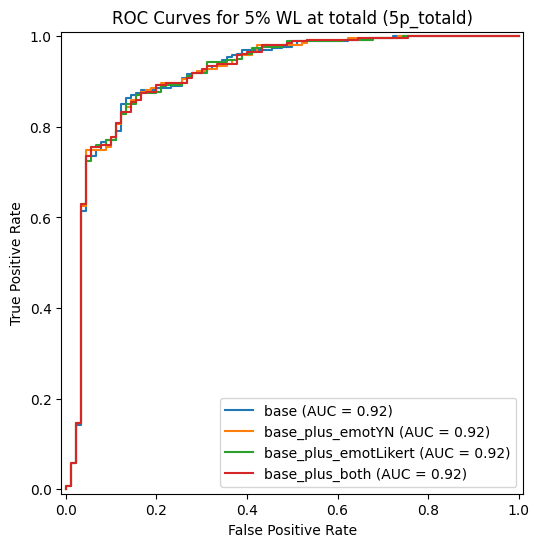

ROC plot saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\logreg_roc\roc_5p_totald.png


In [35]:
# --- CONFIGURATION SECTION ---
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Set your base directory (already defined globally in your notebook)
# paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
DB_PATH = os.path.join(paper1_directory, "survival_analysis.sqlite")
INPUT_TABLE = "sa_input_table"
OUTPUT_DIR = os.path.join(paper1_directory, "logreg_roc")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SCENARIO CONFIGURATION ---
# You can change these to try other scenarios!
WL_TARGET_PERC = 5         # Weight loss % to predict (5 or 10)
TIME_FRAME = 'total'        # Days (e.g., 60 for 60d, or 'total' for total followup)
SCENARIO_NAME = f"{WL_TARGET_PERC}p_{TIME_FRAME}d"  # Used in filenames

# --- OUTCOME COLUMN LOGIC ---
if TIME_FRAME == 'total':
    OUTCOME_COL = f"{WL_TARGET_PERC}%_wl_achieved"
else:
    OUTCOME_COL = f"wl_{TIME_FRAME}d_%"
    # We'll create a binary outcome: did they achieve at least X% WL at N days?

# --- PREDICTOR SETS ---
BASE_PREDICTORS = ["age", "sex_f", "baseline_weight_kg", "baseline_bmi", "total_followup_days"]
EXTRA_PREDICTORS = [
    [],  # Model 1: base only
    ["emotional_eating_yn"],  # Model 2: add binary emotional eating
    ["emotional_eating_value_likert"],  # Model 3: add likert value
    ["emotional_eating_yn", "emotional_eating_value_likert"],  # Model 4: both
]
MODEL_LABELS = [
    "base",
    "base_plus_emotYN",
    "base_plus_emotLikert",
    "base_plus_both"
]

# --- LOAD DATA ---
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", conn)

# --- CREATE OUTCOME COLUMN ---
df = df.copy()
if TIME_FRAME == 'total':
    # Already binary (0/1)
    y = df[OUTCOME_COL]
else:
    # Create binary: did they achieve at least X% WL at N days?
    wl_col = f"wl_{TIME_FRAME}d_%"
    y = (df[wl_col].abs() >= WL_TARGET_PERC).astype(int)
    df[f"{WL_TARGET_PERC}p_{TIME_FRAME}d_achieved"] = y
    OUTCOME_COL = f"{WL_TARGET_PERC}p_{TIME_FRAME}d_achieved"

# --- DROP ROWS WITH MISSING DATA IN OUTCOME OR PREDICTORS ---
# We'll do this for each model, but let's check for missing outcome first:
df = df[df[OUTCOME_COL].notna()].copy()

# --- STRATIFIED SPLIT: by outcome AND sex ---
# Combine outcome and sex for stratification
stratify_col = df[OUTCOME_COL].astype(str) # + "_" + df["sex_f"].astype(str) # uncomment if want to stratify by sex too besides outcome
# Check class counts:
print("Counts for stratification groups (outcome_sex):")
print(stratify_col.value_counts())

# --- CHECK FOR RARE COMBINATIONS BEFORE SPLITTING ---
# If any group has <2 samples, train_test_split will fail!
min_group_size = stratify_col.value_counts().min()
if min_group_size < 2:
    print("\nWARNING: Some outcome/sex combinations have less than 2 samples!")
    print("Consider removing rare groups or using a different stratification.")
    # You can see which ones are rare:
    print(stratify_col.value_counts())
    # To proceed anyway, you could drop those rows:
    rare_groups = stratify_col.value_counts()[stratify_col.value_counts() < 2].index
    df = df[~stratify_col.isin(rare_groups)].copy()
    stratify_col = df[OUTCOME_COL].astype(str) + "_" + df["sex_f"].astype(str)
    print("After removing rare groups, new counts:")
    print(stratify_col.value_counts())

# --- TRAIN/TEST SPLIT ---
X_full = df  # We'll select columns for each model below
y_full = df[OUTCOME_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=stratify_col
)

# --- RUN MODELS AND PLOT ROC CURVES ---
plt.figure(figsize=(8, 6))
for i, extra in enumerate(EXTRA_PREDICTORS):
    predictors = BASE_PREDICTORS + extra
    model_label = MODEL_LABELS[i]
    # Drop rows with missing data in predictors (train/test separately)
    Xtr = X_train[predictors].dropna()
    ytr = y_train.loc[Xtr.index]
    Xte = X_test[predictors].dropna()
    yte = y_test.loc[Xte.index]
    # Fit logistic regression
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    # Predict probabilities
    y_pred_proba = clf.predict_proba(Xte)[:, 1]
    # ROC and AUC
    fpr, tpr, _ = roc_curve(yte, y_pred_proba)
    auc = roc_auc_score(yte, y_pred_proba)
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name=model_label).plot(ax=plt.gca())
    print(f"Model: {model_label} | AUC: {auc:.3f} | N test: {len(yte)}")

plt.title(f"ROC Curves for {WL_TARGET_PERC}% WL at {TIME_FRAME}d ({SCENARIO_NAME})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plot_path = os.path.join(OUTPUT_DIR, f"roc_{SCENARIO_NAME}.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC plot saved to: {plot_path}")

# --- END OF PIPELINE ---

# --- HOW TO CHECK FOR SPLITTING DIFFICULTIES ---
# - If train_test_split gives a ValueError about "The least populated class in y has only 1 member",
#   it means some outcome/sex group is too rare.
# - Use the printout above to see which groups are rare.
# - You can drop those groups (see code above), or use a less granular stratification (e.g., just outcome).
# - Always check the counts before splitting!

### RF-ROC

--- Running Scenario: rf_10p_wl_at_total ---

Loading data from: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.sqlite, table: sa_input_table
Loaded 1171 rows.
Using existing outcome variable '10%_wl_achieved' for total followup.
Outcome variable '10%_wl_achieved' value counts:
10%_wl_achieved
0    0.512383
1    0.487617
Name: proportion, dtype: float64

Stratification key value counts (before handling rare groups):
stratify_key
0_1    493
1_1    440
1_0    131
0_0    107
Name: count, dtype: int64

Train set size: 936 rows
Test set size: 235 rows
Train set outcome distribution:
10%_wl_achieved
0    0.511752
1    0.488248
Name: proportion, dtype: float64
Test set outcome distribution:
10%_wl_achieved
0    0.514894
1    0.485106
Name: proportion, dtype: float64

--- Starting Model Training and Evaluation ---

--- Model: base_only ---
Predictors: ['age', 'sex_f', 'baseline_weight_kg', 'baseline_bmi', 'total_followup_days']
AUC for base_only: 0.9006

Tree-

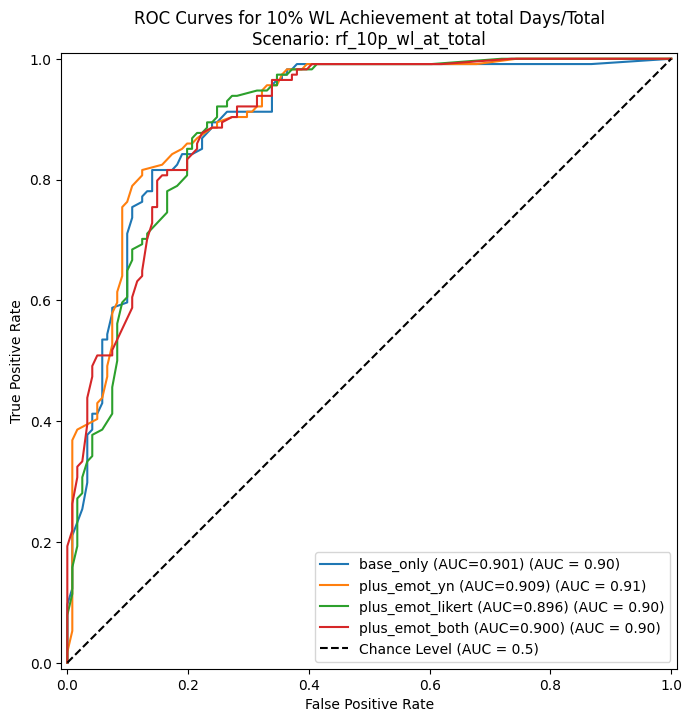


ROC plot saved to: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\rf_roc_feature_importance\rf_10p_wl_at_total_roc_curves.png


--- Summary of Feature Importances (for current scenario) ---

-- Sub-Model: base_only --
  Tree-based Importances:
total_followup_days    0.619715
baseline_bmi           0.134541
baseline_weight_kg     0.123479
age                    0.106181
sex_f                  0.016084

  Permutation Importances (Test Set):
total_followup_days    0.337872
baseline_weight_kg     0.018298
baseline_bmi          -0.000851
sex_f                 -0.001277
age                   -0.004255

-- Sub-Model: plus_emot_yn --
  Tree-based Importances:
total_followup_days    0.609993
baseline_bmi           0.132169
baseline_weight_kg     0.126452
age                    0.103118
sex_f                  0.014321
emotional_eating_yn    0.013947

  Permutation Importances (Test Set):
total_followup_days    0.338298
baseline_weight_kg     0.015319
baseline_bmi           0.012

In [48]:
import os
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import warnings
import openpyxl

# --- CONFIGURATION SECTION ---

# NOTE: Ensure 'paper1_directory' is defined in your notebook environment before running this script.
# Example: paper1_directory = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional"
if 'paper1_directory' not in globals() and 'paper1_directory' not in locals():
    # Fallback for script execution if paper1_directory is not set (e.g., set a default or raise error)
    # For this example, we'll try to use a common structure, but it's best to define it externally.
    # paper1_directory = os.path.join(os.path.expanduser("~"), "Desktop", "Projects", "PNK_DB2", "paper1_emotional")
    # print(f"Warning: 'paper1_directory' not found globally, using a default: {paper1_directory}")
    # A better approach for standalone scripts is to make it an explicit input or environment variable.
    raise NameError("'paper1_directory' is not defined. Please define it in your environment.")


DB_PATH = os.path.join(paper1_directory, "survival_analysis.sqlite")
INPUT_TABLE = "sa_input_table"
OUTPUT_DIR = os.path.join(paper1_directory, "rf_roc_feature_importance")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- SCENARIO CONFIGURATION ---
# You can change these to try other scenarios!
WL_TARGET_PERC = 10 # Weight loss % to predict (e.g., 5, 10, 15)
TIME_FRAME = 'total'    # Days (e.g., 40, 60, 80, or 'total' for total followup)
# SCENARIO_NAME will be generated dynamically

# --- PREDICTOR SETS ---
# These are the columns from your sa_input_table
BASE_PREDICTORS = ["age", "sex_f", "baseline_weight_kg", "baseline_bmi", "total_followup_days"]
EXTRA_PREDICTORS_CONFIG = [
    {'name': 'base_only', 'features': []},
    {'name': 'plus_emot_yn', 'features': ["emotional_eating_yn"]},
    {'name': 'plus_emot_likert', 'features': ["emotional_eating_value_likert"]},
    {'name': 'plus_emot_both', 'features': ["emotional_eating_yn", "emotional_eating_value_likert"]},
]

# --- Random Forest Parameters ---
# These can be tuned, but we'll use sensible defaults for now.
RF_N_ESTIMATORS = 100
RF_RANDOM_STATE = 42 # For reproducibility

# --- Permutation Importance Parameters ---
PERMUTATION_N_REPEATS = 10 # Number of times to shuffle each feature for permutation importance

# --- Helper function to generate scenario name ---
def get_scenario_name(wl_perc, time_fr):
    time_label = str(time_fr) + 'd' if isinstance(time_fr, int) else str(time_fr)
    return f"rf_{wl_perc}p_wl_at_{time_label}"

SCENARIO_NAME = get_scenario_name(WL_TARGET_PERC, TIME_FRAME)
print(f"--- Running Scenario: {SCENARIO_NAME} ---")

# --- 1. LOAD DATA ---
print(f"\nLoading data from: {DB_PATH}, table: {INPUT_TABLE}")
if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database file not found at {DB_PATH}")

with sqlite3.connect(DB_PATH) as conn:
    df_full = pd.read_sql_query(f"SELECT * FROM {INPUT_TABLE}", conn)
print(f"Loaded {len(df_full)} rows.")

# --- 2. CREATE OUTCOME VARIABLE ---
# We'll work with a copy of the DataFrame to avoid modifying the original
df = df_full.copy()
outcome_col_name = "" # Will be set based on TIME_FRAME

if isinstance(TIME_FRAME, int):
    # Outcome is achieving WL_TARGET_PERC at a specific number of days (TIME_FRAME)
    # The column name for weight loss percentage at N days is 'wl_Nd_%'
    wl_at_n_days_col = f"wl_{TIME_FRAME}d_%"
    outcome_col_name = f"achieved_{WL_TARGET_PERC}p_wl_at_{TIME_FRAME}d"

    if wl_at_n_days_col not in df.columns:
        raise KeyError(f"Weight loss column '{wl_at_n_days_col}' not found in the DataFrame. Check TIME_FRAME.")

    # Create binary outcome: 1 if absolute weight loss % is >= target, 0 otherwise
    # Ensure the source column is numeric
    df[wl_at_n_days_col] = pd.to_numeric(df[wl_at_n_days_col], errors='coerce')
    df[outcome_col_name] = (df[wl_at_n_days_col].abs() >= WL_TARGET_PERC).astype(int)
    print(f"Created outcome variable '{outcome_col_name}' based on '{wl_at_n_days_col}' >= {WL_TARGET_PERC}%.")

elif TIME_FRAME == 'total':
    # Outcome is achieving WL_TARGET_PERC during the total followup period
    # The column name for this is 'K%_wl_achieved'
    outcome_col_name = f"{WL_TARGET_PERC}%_wl_achieved"

    if outcome_col_name not in df.columns:
        raise KeyError(f"Outcome column '{outcome_col_name}' not found for TIME_FRAME='total'. Check WL_TARGET_PERC.")
    # Ensure the outcome column is integer (0 or 1)
    df[outcome_col_name] = pd.to_numeric(df[outcome_col_name], errors='coerce').fillna(0).astype(int)
    print(f"Using existing outcome variable '{outcome_col_name}' for total followup.")

else:
    raise ValueError(f"Invalid TIME_FRAME: {TIME_FRAME}. Must be an integer (days) or 'total'.")

# Drop rows where the outcome variable is missing (if any were introduced by coercion)
initial_rows = len(df)
df.dropna(subset=[outcome_col_name], inplace=True)
if len(df) < initial_rows:
    print(f"Dropped {initial_rows - len(df)} rows due to missing outcome values in '{outcome_col_name}'.")

if df.empty:
    raise ValueError("DataFrame is empty after outcome creation/filtering. Cannot proceed.")
if df[outcome_col_name].nunique() < 2:
    raise ValueError(f"Outcome variable '{outcome_col_name}' has less than 2 unique values. Cannot perform binary classification.")

print(f"Outcome variable '{outcome_col_name}' value counts:\n{df[outcome_col_name].value_counts(normalize=True)}")


# --- 3. STRATIFIED TRAIN-TEST SPLIT ---
# Stratify by outcome and sex_f
# Ensure 'sex_f' is present and numeric (0 or 1)
if 'sex_f' not in df.columns:
    raise KeyError("'sex_f' column not found, which is needed for stratification.")
df['sex_f'] = pd.to_numeric(df['sex_f'], errors='coerce').fillna(0).astype(int) # Assuming 0 for male, 1 for female

# Create a combined stratification column
df['stratify_key'] = df[outcome_col_name].astype(str) + "_" + df['sex_f'].astype(str)

print("\nStratification key value counts (before handling rare groups):")
print(df['stratify_key'].value_counts())

# Handle rare groups for stratification (if a group has < 2 members, train_test_split fails)
min_group_size = 2
strat_counts = df['stratify_key'].value_counts()
rare_groups = strat_counts[strat_counts < min_group_size].index

if len(rare_groups) > 0:
    print(f"\nWarning: Found rare stratification groups (count < {min_group_size}): {list(rare_groups)}")
    df = df[~df['stratify_key'].isin(rare_groups)].copy()
    print(f"Removed {len(rare_groups)} rare groups. New data size: {len(df)} rows.")
    if df.empty or df[outcome_col_name].nunique() < 2 or df['stratify_key'].nunique() < 2 :
         raise ValueError("Not enough data or classes remaining after removing rare stratification groups.")
    print("\nStratification key value counts (after handling rare groups):")
    print(df['stratify_key'].value_counts())


# Define features (X) and target (y) for the split
# We'll select specific predictor columns for each model later
X_data_for_split = df.drop(columns=[outcome_col_name, 'stratify_key']) # Drop outcome and temp key
y_target_for_split = df[outcome_col_name]

X_train, X_test, y_train, y_test = train_test_split(
    X_data_for_split,
    y_target_for_split,
    test_size=0.2,  # 80% train, 20% test
    random_state=RF_RANDOM_STATE,
    stratify=df['stratify_key'] # Use the stratification key from the original df before dropping columns
)

print(f"\nTrain set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")
print(f"Train set outcome distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set outcome distribution:\n{y_test.value_counts(normalize=True)}")


# --- 4. MODEL TRAINING, ROC COMPARISON, AND FEATURE IMPORTANCE ---
print("\n--- Starting Model Training and Evaluation ---")

# Store results for feature importances
all_feature_importances = {}

# Initialize plot for ROC curves
plt.figure(figsize=(10, 8))
ax_roc = plt.gca() # Get current axes for RocCurveDisplay

for model_config in EXTRA_PREDICTORS_CONFIG:
    model_label = model_config['name']
    extra_features = model_config['features']
    current_predictors = BASE_PREDICTORS + extra_features

    print(f"\n--- Model: {model_label} ---")
    print(f"Predictors: {current_predictors}")

    # Ensure all current predictors are in the DataFrame columns
    missing_predictors = [p for p in current_predictors if p not in X_train.columns]
    if missing_predictors:
        print(f"Warning: Predictors {missing_predictors} not found. Skipping model {model_label}.")
        all_feature_importances[model_label] = {
            'tree_based': pd.Series(dtype=float),
            'permutation_test': pd.Series(dtype=float)
        }
        continue

    # Select features for this model and handle potential NaNs from feature selection
    # (User stated no NaNs in input, but this is good practice if features are dynamic)
    X_train_model = X_train[current_predictors].copy()
    X_test_model = X_test[current_predictors].copy()

    # Drop rows if any selected predictor for THIS model is NaN
    # This ensures that each model is trained on complete cases for ITS specific set of features
    train_initial_rows = len(X_train_model)
    X_train_model.dropna(inplace=True)
    y_train_model = y_train[X_train_model.index] # Align y_train with non-NaN rows in X_train_model
    if len(X_train_model) < train_initial_rows:
        print(f"Dropped {train_initial_rows - len(X_train_model)} rows from training set due to NaNs in selected predictors.")

    test_initial_rows = len(X_test_model)
    X_test_model.dropna(inplace=True)
    y_test_model = y_test[X_test_model.index] # Align y_test
    if len(X_test_model) < test_initial_rows:
        print(f"Dropped {test_initial_rows - len(X_test_model)} rows from test set due to NaNs in selected predictors.")

    if X_train_model.empty or X_test_model.empty or y_train_model.nunique() < 2:
        print(f"Warning: Not enough data or outcome variance for model '{model_label}' after NaN handling. Skipping.")
        all_feature_importances[model_label] = {
            'tree_based': pd.Series(dtype=float),
            'permutation_test': pd.Series(dtype=float)
        }
        continue

    # Initialize and train Random Forest Classifier
    # For more robust performance, consider hyperparameter tuning using GridSearchCV or RandomizedSearchCV with cross-validation.
    rf_model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        random_state=RF_RANDOM_STATE,
        # class_weight='balanced', # Consider if classes are imbalanced
        n_jobs=-1 # Use all available cores
    )
    rf_model.fit(X_train_model, y_train_model)

    # --- ROC Curve Analysis ---
    y_pred_proba = rf_model.predict_proba(X_test_model)[:, 1] # Probabilities for the positive class
    auc_score = roc_auc_score(y_test_model, y_pred_proba)
    print(f"AUC for {model_label}: {auc_score:.4f}")

    RocCurveDisplay.from_estimator(rf_model, X_test_model, y_test_model, name=f"{model_label} (AUC={auc_score:.3f})", ax=ax_roc)

    # --- Feature Importance ---
    # 1. Tree-based (Gini) Importance
    tree_importances = pd.Series(rf_model.feature_importances_, index=current_predictors).sort_values(ascending=False)
    print("\nTree-based Feature Importances:")
    print(tree_importances)

    # 2. Permutation Importance (on the test set)
    # This can be computationally intensive, especially with many repeats or features.
    print("\nCalculating Permutation Importances (on test set)...")
    with warnings.catch_warnings(): # Suppress potential UserWarnings from sklearn about std=0
        warnings.simplefilter("ignore", UserWarning)
        perm_importance_result = permutation_importance(
            rf_model,
            X_test_model,
            y_test_model,
            n_repeats=PERMUTATION_N_REPEATS,
            random_state=RF_RANDOM_STATE,
            n_jobs=-1 # Use all available cores
        )
    perm_importances = pd.Series(perm_importance_result.importances_mean, index=current_predictors).sort_values(ascending=False)
    print("\nPermutation Feature Importances (Mean over repeats):")
    print(perm_importances)

    all_feature_importances[model_label] = {
        'tree_based': tree_importances,
        'permutation_test': perm_importances
    }

    # Highlight emotional eating features if present
    for emot_feat in ["emotional_eating_yn", "emotional_eating_value_likert"]:
        if emot_feat in current_predictors:
            print(f"  Tree-based importance for '{emot_feat}': {tree_importances.get(emot_feat, 'N/A'):.4f}")
            print(f"  Permutation importance for '{emot_feat}': {perm_importances.get(emot_feat, 'N/A'):.4f}")


# --- 5. FINALIZE AND SAVE ROC PLOT ---
ax_roc.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.5)') # Diagonal line
ax_roc.set_title(f'ROC Curves for {WL_TARGET_PERC}% WL Achievement at {TIME_FRAME} Days/Total\nScenario: {SCENARIO_NAME}')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
roc_plot_path = os.path.join(OUTPUT_DIR, f"{SCENARIO_NAME}_roc_curves.png")
plt.savefig(roc_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nROC plot saved to: {roc_plot_path}")

# --- 6. DISPLAY/SAVE ALL FEATURE IMPORTANCES ---
print("\n\n--- Summary of Feature Importances (for current scenario) ---")
for model_label, importances_dict in all_feature_importances.items():
    print(f"\n-- Sub-Model: {model_label} --")
    print("  Tree-based Importances:")
    if not importances_dict['tree_based'].empty:
        print(importances_dict['tree_based'].to_string())
    else:
        print("    Not available (model might have been skipped).")
    print("\n  Permutation Importances (Test Set):")
    if not importances_dict['permutation_test'].empty:
        print(importances_dict['permutation_test'].to_string())
    else:
        print("    Not available (model might have been skipped).")

# Prepare data for the current scenario's sheet
sheet_data_frames = []
for model_label, importances_dict in all_feature_importances.items():
    # Process tree-based importances
    if 'tree_based' in importances_dict and not importances_dict['tree_based'].empty:
        df_tree = importances_dict['tree_based'].rename('importance_score').reset_index()
        df_tree.rename(columns={'index': 'feature'}, inplace=True)
        df_tree['model_config_label'] = model_label
        df_tree['importance_type'] = 'tree_based'
        sheet_data_frames.append(df_tree)

    # Process permutation importances
    if 'permutation_test' in importances_dict and not importances_dict['permutation_test'].empty:
        df_perm = importances_dict['permutation_test'].rename('importance_score').reset_index()
        df_perm.rename(columns={'index': 'feature'}, inplace=True)
        df_perm['model_config_label'] = model_label
        df_perm['importance_type'] = 'permutation_test'
        sheet_data_frames.append(df_perm)

if sheet_data_frames:
    df_for_this_sheet = pd.concat(sheet_data_frames, ignore_index=True)
    # Reorder columns for clarity
    if not df_for_this_sheet.empty:
        df_for_this_sheet = df_for_this_sheet[['model_config_label', 'feature', 'importance_type', 'importance_score']]

    # Define a fixed name for the master Excel file
    master_excel_filename = "all_rf_roc_feature_importances.xlsx"
    excel_path = os.path.join(OUTPUT_DIR, master_excel_filename)
    
    # SCENARIO_NAME (e.g., "rf_15p_wl_at_total") will be the sheet name.
    # Sanitize SCENARIO_NAME for Excel sheet name limitations (max 31 chars, no invalid chars).
    sheet_name_for_excel = "".join(c if c.isalnum() else "_" for c in SCENARIO_NAME)[:31]

    try:
        # Determine mode and if_sheet_exists option for ExcelWriter
        if os.path.exists(excel_path):
            mode = 'a'  # Append mode if file exists
            if_sheet_exists_option = 'replace'  # Replace sheet if it has the same name
        else:
            mode = 'w'  # Write mode if file doesn't exist (creates new file)
            if_sheet_exists_option = None # Not applicable for 'w' mode

        with pd.ExcelWriter(excel_path, engine='openpyxl', mode=mode, if_sheet_exists=if_sheet_exists_option) as writer:
            df_for_this_sheet.to_excel(writer, sheet_name=sheet_name_for_excel, index=False)
            print(f"\nSaved Feature Importances for scenario '{SCENARIO_NAME}' to sheet '{sheet_name_for_excel}' in: {excel_path}")
            if mode == 'a' and if_sheet_exists_option == 'replace':
                print(f"   (Sheet '{sheet_name_for_excel}' was replaced if it already existed in the master file.)")
            elif mode == 'a':
                 print(f"   (Sheet '{sheet_name_for_excel}' was added to the master file.)")


    except Exception as e:
        print(f"Error saving feature importances to Excel: {e}")
        print("Please ensure you have 'openpyxl' installed: pip install openpyxl")
else:
    print(f"\nNo feature importances were generated for scenario '{SCENARIO_NAME}' to save to the master Excel file.")

print("\n--- Script Finished ---")

## Weight gain causes

In [39]:
import sqlite3
import pandas as pd

# Path to the SQLite database
db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\weight_gain_causes.sqlite"

# Connect and get table names
with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print("Tables in database:", tables['name'].tolist())
    # Replace 'your_table_name' with the actual table name if known
    table_name = tables['name'].iloc[0]
    df_weight_gain_causes = pd.read_sql_query(f"SELECT * FROM [{table_name}]", conn)

df_weight_gain_causes

Tables in database: ['weight_gain_causes']


,patient_id,medical_record_id,weight_gain_cause,weight_gain_cause_en,womens_health_and_pregnancy,mental_health,family_issues,medication_disease_injury,physical_activity,eating_habits,schedule,smoking_cessation,post_treatment_weight_regain,pandemic,habits_and_circumstances,none_of_above
0,9897B34CEB969,13A04142A682D,"estrés, mucho trabajo","""stress, too much work""",0,1,0,0,0,0,1,0,0,0,1,0
1,9898644CEB969,13786742A682D,este último año ha cogido peso por tema mudanz...,"""this last year i have gained weight due to mo...",0,0,0,1,1,0,0,0,0,0,1,0
2,9899A04CEB969,10B67842A682D,EMBARAZO,"""pregnancy""",1,0,0,0,0,0,0,0,0,0,0,0
3,9899A94CEB969,12CE5B42A682D,FEZ MEDICAÇÃO PARA A DEPRESSÃO DURANTE A PANDE...,"""took medication for depression during the pan...",0,1,0,1,0,1,0,0,0,1,0,0
4,9899D04CEB969,13D74142A682D,HOUVE UM DESLEIXO ALIMENTAR NA QUANTIDADE,"""there was a neglect in food quantity""",0,0,0,0,0,1,0,0,0,0,1,0


## Misc

In [ ]:
import sqlite3

# Connect to the SQLite database
db_path = 'C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\paper1_emotional\\survival_analysis.sqlite'
table_name = 'sa_input_table'

# Query to fetch unique values from the weight_gain_cause column
query = f"SELECT DISTINCT weight_gain_cause FROM {table_name}"

# Execute the query and fetch results
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute(query)
    results = cursor.fetchall()

# Extract and print the unique observations
unique_weight_gain_causes = [row[0] for row in results if row[0] is not None]
print("Unique observations in the weight_gain_cause column:")
for cause in unique_weight_gain_causes:
    print(cause)

In [12]:
import sqlite3
import pandas as pd
import os

# Define the output Excel file path
DB_PATH = os.path.join(paper1_directory, "survival_analysis.sqlite")
output_excel_path = os.path.join(paper1_directory, 'survival_analysis.xlsx')

# Connect to the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    # Get the list of all tables in the database
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    tables = pd.read_sql_query(query, conn)['name'].tolist()
    
    # Create a Pandas Excel writer
    with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
        # Loop through each table and save it as a sheet in the Excel file
        for table in tables:
            df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
            df.to_excel(writer, sheet_name=table, index=False)

print(f"Database exported to Excel at: {output_excel_path}")

Database exported to Excel at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper1_emotional\survival_analysis.xlsx
